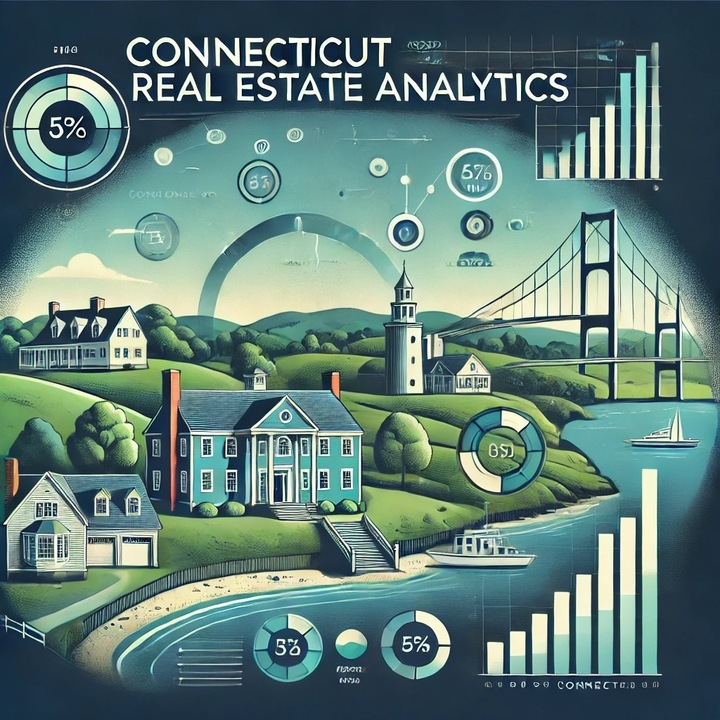

This notebook will demonstrate how to perform EDA (Exploratory Data Analysis) and data visualization for the Real Estate Sales 2001-2022 GL dataset.

Table of Contents:

<ul> <li><a href="#import-library">Import Library</a></li> <li><a href="#loading-dataset">Loading The Dataset</a></li> <li><a href="#understanding-dataset">Understanding the dataset-EDA</a></li> <li><a href="#research-queries">Research Queries and Analytical Insights</a></li> </ul>
Hope it is helpful.

This notebook has been sourced from the following link: https://catalog.data.gov/dataset/real-estate-sales-2001-2018.

<a id='import-library'></a>
# <p style="background-color:black;font-family:newtimeroman;font-size:150%;color:white;text-align:center;border-radius:20px 20px;"><b>Import Library</b></p>

- **missingno:** A library for visualizing missing data, helping us understand missing data structures.
- **plotly.express:** A library used to create interactive graphs.
- **folium:** A library for visualizing data on maps.
- **folium.plugins:** Allows us to use additional plugins for Folium.

- **plt.rcParams["figure.figsize"] = (6,4):** Sets the size of the plots created with Matplotlib. Here, the plot size is defined as 6 inches in width and 4 inches in height.

- **warnings.filterwarnings("ignore"):** Used to ignore Python warnings. This prevents unnecessary warning messages from appearing during code execution.
- **pd.set_option('display.max_columns', None):** Does not limit the number of columns in the Pandas DataFrame output, showing all columns.
- **pd.set_option('display.max_rows', None):** Does not limit the number of rows in the Pandas DataFrame output, showing all rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
import plotly.express as px
import folium
from folium import plugins

plt.rcParams["figure.figsize"] = (6,4)

import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

<a id='loading-dataset'></a>
# <p style="background-color:black;font-family:newtimeroman;font-size:150%;color:white;text-align:center;border-radius:20px 20px;"><b>Loading The Dataset</b></p>

### About the DataSet

| **Field Name**        | **Description**                                                                                  | **Field Alias**     | **Data Type**        |
|------------------------|--------------------------------------------------------------------------------------------------|---------------------|----------------------|
| **Serial Number**      | Serial number                                                                                   | `serialnumber`      | Number               |
| **List Year**          | Year the property was listed for sale                                                           | `listyear`          | Number               |
| **Date Recorded**      | Date the sale was recorded locally                                                              | `daterecorded`      | Floating Timestamp   |
| **Town**               | Town name                                                                                       | `town`              | Text                 |
| **Address**            | Address                                                                                         | `address`           | Text                 |
| **Assessed Value**     | Value of the property used for local tax assessment                                             | `assessedvalue`     | Number               |
| **Sale Amount**        | Amount the property was sold for                                                                | `saleamount`        | Number               |
| **Sales Ratio**        | Ratio of the sale price to the assessed value                                                   | `salesratio`        | Text                 |
| **Property Type**      | Type of property including: Residential, Commercial, Industrial, Apartments, Vacant, etc.       | `propertytype`      | Text                 |
| **Residential Type**   | Indicates whether property is single or multifamily residential                                 | `residentialtype`   | Text                 |
| **Non Use Code**       | Non-usable sale code typically means the sale price is not reliable for use in property valuation| `nonusecode`        | Text                 |
| **Assessor Remarks**   | Remarks from the assessor                                                                       | `remarks`           | Text                 |
| **OPM Remarks**        | Remarks from OPM                                                                                | `opm_remarks`       | Text                 |
| **Location**           | Lat / lon coordinates                                                                           | `geo_coordinates`   | Point                |


In [2]:
df0 = pd.read_csv('Real_Estate_Sales_2001-2022_GL.csv') 
df = df0.copy()

<a id='understanding-dataset'></a>
# <p style="background-color:black;font-family:newtimeroman;font-size:150%;color:white;text-align:center;border-radius:20px 20px;"><b>Understanding the dataset-EDA</b></p>

**Skimpy Library:**

It is a library used for quickly and effectively summarizing datasets in Python.

By displaying basic statistics on a column basis, it facilitates understanding the data and identifying potential issues.

It offers a simple solution that saves time for data analysts when exploring and inspecting large datasets.

In [3]:
from skimpy import skim

In [4]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                 Data Types                                                                │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                         │
│ ┃ dataframe         ┃ Values  ┃ ┃ Column Type ┃ Count ┃                                                         │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                         │
│ │ Number of rows    │ 1097629 │ │ string      │ 8     │                                                         │
│ │ Number of columns │ 13      │ │ float64     │ 3     │                                                         │
│ └───────────────────┴─────────┘ │ int64       │ 2     │                                                         │
│                                 └─────────────┴───────┘                                                         │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column_name     ┃ NA  ┃ NA %  ┃ mean    ┃ sd       ┃ p0   ┃ p25    ┃ p50    ┃ p75    ┃ p100       ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ Serial Number   │   0 │     0 │  537000 │  7526000 │    0 │  30710 │  80710 │ 170300 │ 2001000000 │   ▇    │  │
│ │ List Year       │   0 │     0 │    2011 │    6.773 │ 2001 │   2005 │   2011 │   2018 │       2022 │ ▇▅▅▃▆▇ │  │
│ │ Assessed Value  │   0 │     0 │  281800 │  1658000 │    0 │  89090 │ 140600 │ 228300 │  881500000 │   ▇    │  │
│ │ Sale Amount     │   0 │     0 │  405300 │  5143000 │    0 │ 145000 │ 233000 │ 375000 │ 5000000000 │   ▇    │  │
│ │ Sales Ratio     │   0 │     0 │   9.604 │     1802 │    0 │ 0.4779 │ 0.6106 │ 0.7707 │    1226000 │   ▇    │  │
│ └─────────────────┴─────┴───────┴─────────┴──────────┴──────┴────────┴────────┴────────┴────────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column_name                   ┃ NA            ┃ NA %       ┃ words per row           ┃ total words         ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Date Recorded                 │             2 │          0 │                       1 │             1097627 │  │
│ │ Town                          │             0 │          0 │                     1.2 │             1297772 │  │
│ │ Address                       │            51 │          0 │                     3.4 │             3708541 │  │
│ │ Property Type                 │        382446 │      34.84 │                     1.1 │             1165773 │  │
│ │ Residential Type              │        398389 │       36.3 │                     1.1 │             1261658 │  │
│ │ Assessor Remarks              │        926401 │       84.4 │                     0.6 │              655412 │  │
│ │ OPM remarks                   │       1084598 │      98.81 │                   0.069 │               76139 │  │
│ │ Location                      │        799518 │      72.84 │                    0.81 │              894333 │  │
│ └───────────────────────────────┴───────────────┴────────────┴─────────────────────────┴─────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

The info() method:

Provides basic information about a DataFrame. This method is useful for quickly understanding the structure of the DataFrame.

RangeIndex: - Information about indexing, such as start, end, and step size.

Data columns: - The names of all columns, how many non-null (non-empty) values there are, and the data type (dtype).

memory usage: - The amount of memory the DataFrame occupies in memory.

dtypes: - The count of different data types (e.g., integer, float, object, etc.).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097629 entries, 0 to 1097628
Data columns (total 14 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Serial Number     1097629 non-null  int64  
 1   List Year         1097629 non-null  int64  
 2   Date Recorded     1097627 non-null  object 
 3   Town              1097629 non-null  object 
 4   Address           1097578 non-null  object 
 5   Assessed Value    1097629 non-null  float64
 6   Sale Amount       1097629 non-null  float64
 7   Sales Ratio       1097629 non-null  float64
 8   Property Type     715183 non-null   object 
 9   Residential Type  699240 non-null   object 
 10  Non Use Code      313451 non-null   object 
 11  Assessor Remarks  171228 non-null   object 
 12  OPM remarks       13031 non-null    object 
 13  Location          298111 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 117.2+ MB


In [6]:
df.columns

Index(['Serial Number', 'List Year', 'Date Recorded', 'Town', 'Address',
       'Assessed Value', 'Sale Amount', 'Sales Ratio', 'Property Type',
       'Residential Type', 'Non Use Code', 'Assessor Remarks', 'OPM remarks',
       'Location'],
      dtype='object')

**.str.replace(" ", "_"):** Replaces spaces in column names with underscores, thus reformatting the column names.

Helps in obtaining more useful and manageable column names. This is a common practice to keep column names consistent and make accessing the columns easier.

In [7]:
df.columns = df.columns.str.replace(" ","_")

In [8]:
df.columns

Index(['Serial_Number', 'List_Year', 'Date_Recorded', 'Town', 'Address',
       'Assessed_Value', 'Sale_Amount', 'Sales_Ratio', 'Property_Type',
       'Residential_Type', 'Non_Use_Code', 'Assessor_Remarks', 'OPM_remarks',
       'Location'],
      dtype='object')

**df.shape,**  A property that returns the dimensions (number of rows and columns) of a DataFrame.

When this property is used, a tuple is returned that shows how many rows and columns the DataFrame consists of.

In [9]:
df.shape

(1097629, 14)

**dtypes** Shows the data type (dtype) of each column.

This property helps you quickly understand what type of data exists in your DataFrame.

In [10]:
df.dtypes

Serial_Number         int64
List_Year             int64
Date_Recorded        object
Town                 object
Address              object
Assessed_Value      float64
Sale_Amount         float64
Sales_Ratio         float64
Property_Type        object
Residential_Type     object
Non_Use_Code         object
Assessor_Remarks     object
OPM_remarks          object
Location             object
dtype: object

**duplicated**

The duplicated function is used to identify duplicate rows within a pandas DataFrame. This function returns a Series containing boolean (True/False) values indicating whether each row is duplicated or not.
The function provides flexibility with the keep parameter:
keep=first (default): Marks all duplicates as True, except the first occurrence.
keep=last: Marks all duplicates as True, except the last occurrence.
keep=False: Marks all duplicates as True.

In [11]:
df.duplicated().sum()

np.int64(0)

## Mising Value

In [12]:
pd.DataFrame({
    'Count': df.count(),
    'Null': df.isnull().sum(),
    'Cardinality': df.nunique()
})

,Count,Null,Cardinality
Serial_Number,1097629,0,96220
List_Year,1097629,0,22
Date_Recorded,1097627,2,6958
Town,1097629,0,170
Address,1097578,51,771931
Assessed_Value,1097629,0,99306
Sale_Amount,1097629,0,61075
Sales_Ratio,1097629,0,552974
Property_Type,715183,382446,11
Residential_Type,699240,398389,5


In [13]:
df.isnull().sum()

Serial_Number             0
List_Year                 0
Date_Recorded             2
Town                      0
Address                  51
Assessed_Value            0
Sale_Amount               0
Sales_Ratio               0
Property_Type        382446
Residential_Type     398389
Non_Use_Code         784178
Assessor_Remarks     926401
OPM_remarks         1084598
Location             799518
dtype: int64

sns.set_theme(): - Uses Seaborn's default theme settings. This ensures that all generated plots have a consistent appearance.

sns.set(rc={"figure.dpi":300, "figure.figsize":(12,9)}): - This line adjusts the resolution and size of the generated plots.

"figure.dpi": 300: - Sets the DPI (dots per inch) to 300, which results in higher resolution plots.

"figure.figsize": (12, 9): - Sets the size of the generated plots to 12x9 inches.

In [14]:
sns.set_theme()

sns.set(rc={"figure.dpi":300, "figure.figsize":(12,9)})

In [15]:
df.Town.value_counts().head(5)

Town
Bridgeport    38158
Stamford      36629
Waterbury     32662
Norwalk       26939
New Haven     23705
Name: count, dtype: int64

# Data Manipulation Questions

### Missing Values: How should we handle the missing values in the Property Type, Residential Type, and Location columns? Should we use imputation or remove these rows?

First, the relation between property type and residential type wil be checked

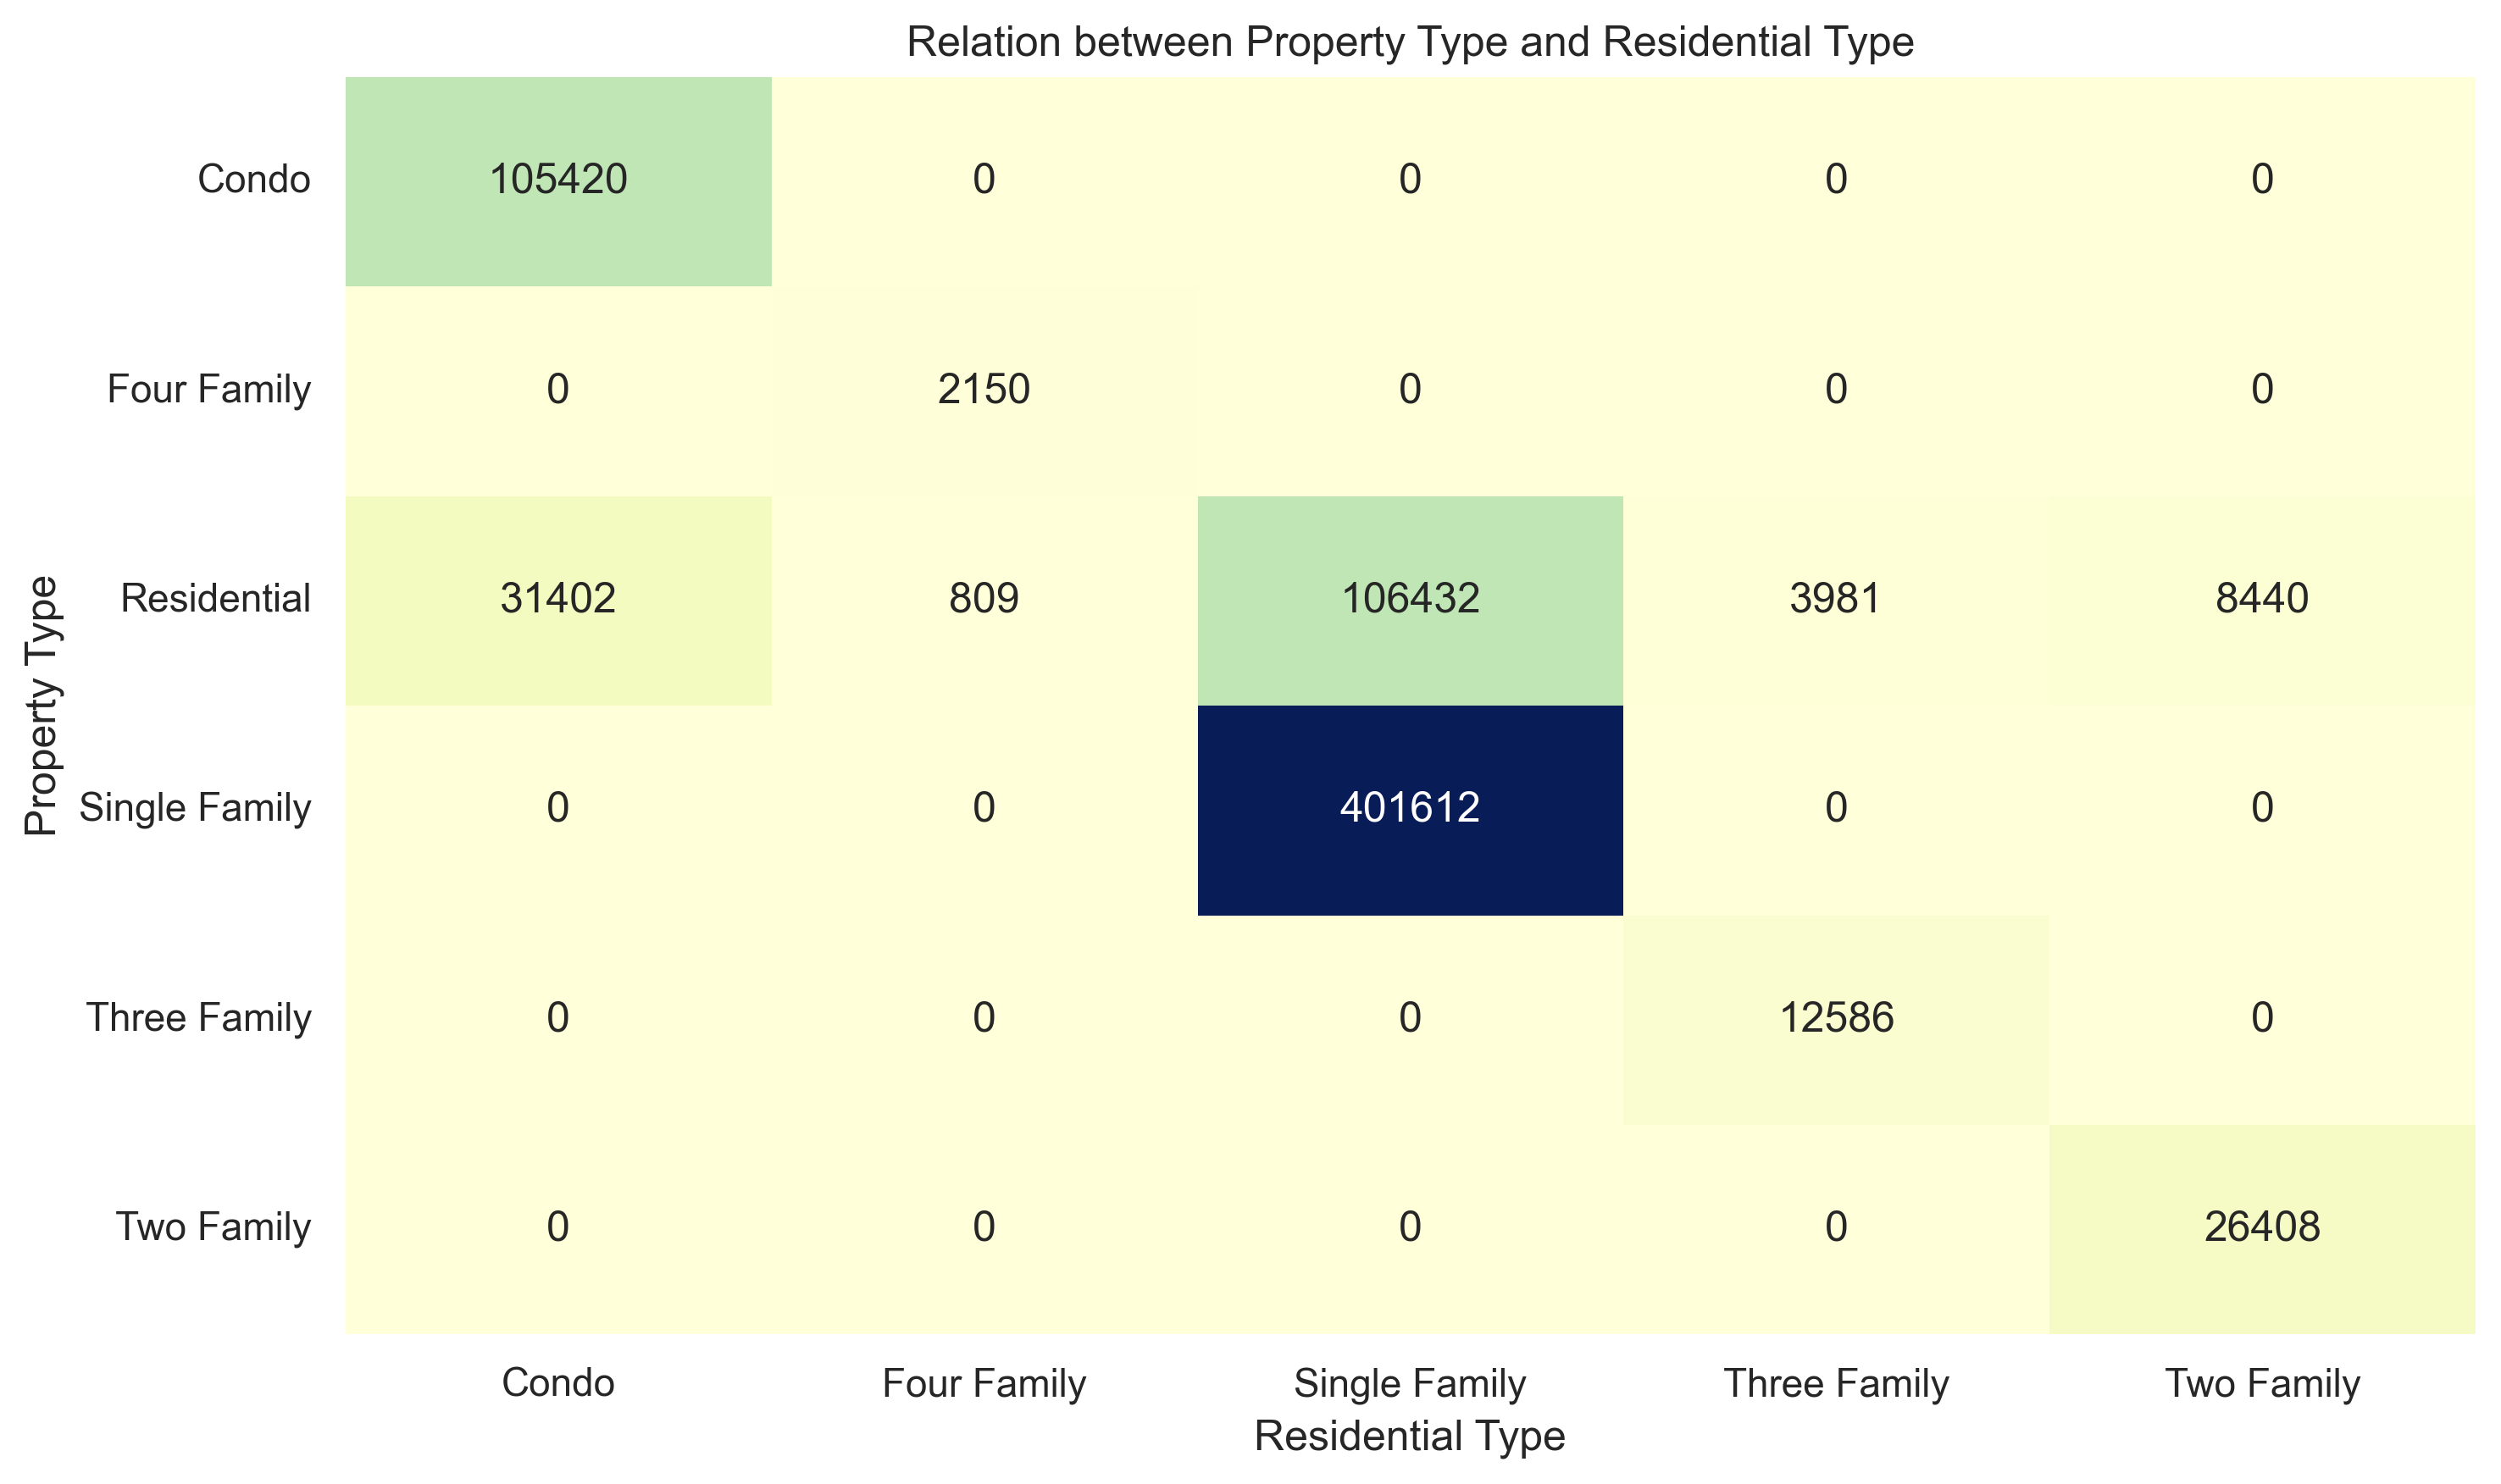

In [16]:
property_residential_table = df.pivot_table(index='Property_Type', 
                                            columns='Residential_Type', 
                                            aggfunc='size', 
                                            fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(property_residential_table, annot=True, cmap='YlGnBu', fmt='d', cbar=False)
plt.title('Relation between Property Type and Residential Type')
plt.xlabel('Residential Type')
plt.ylabel('Property Type')
plt.tight_layout()
plt.show()

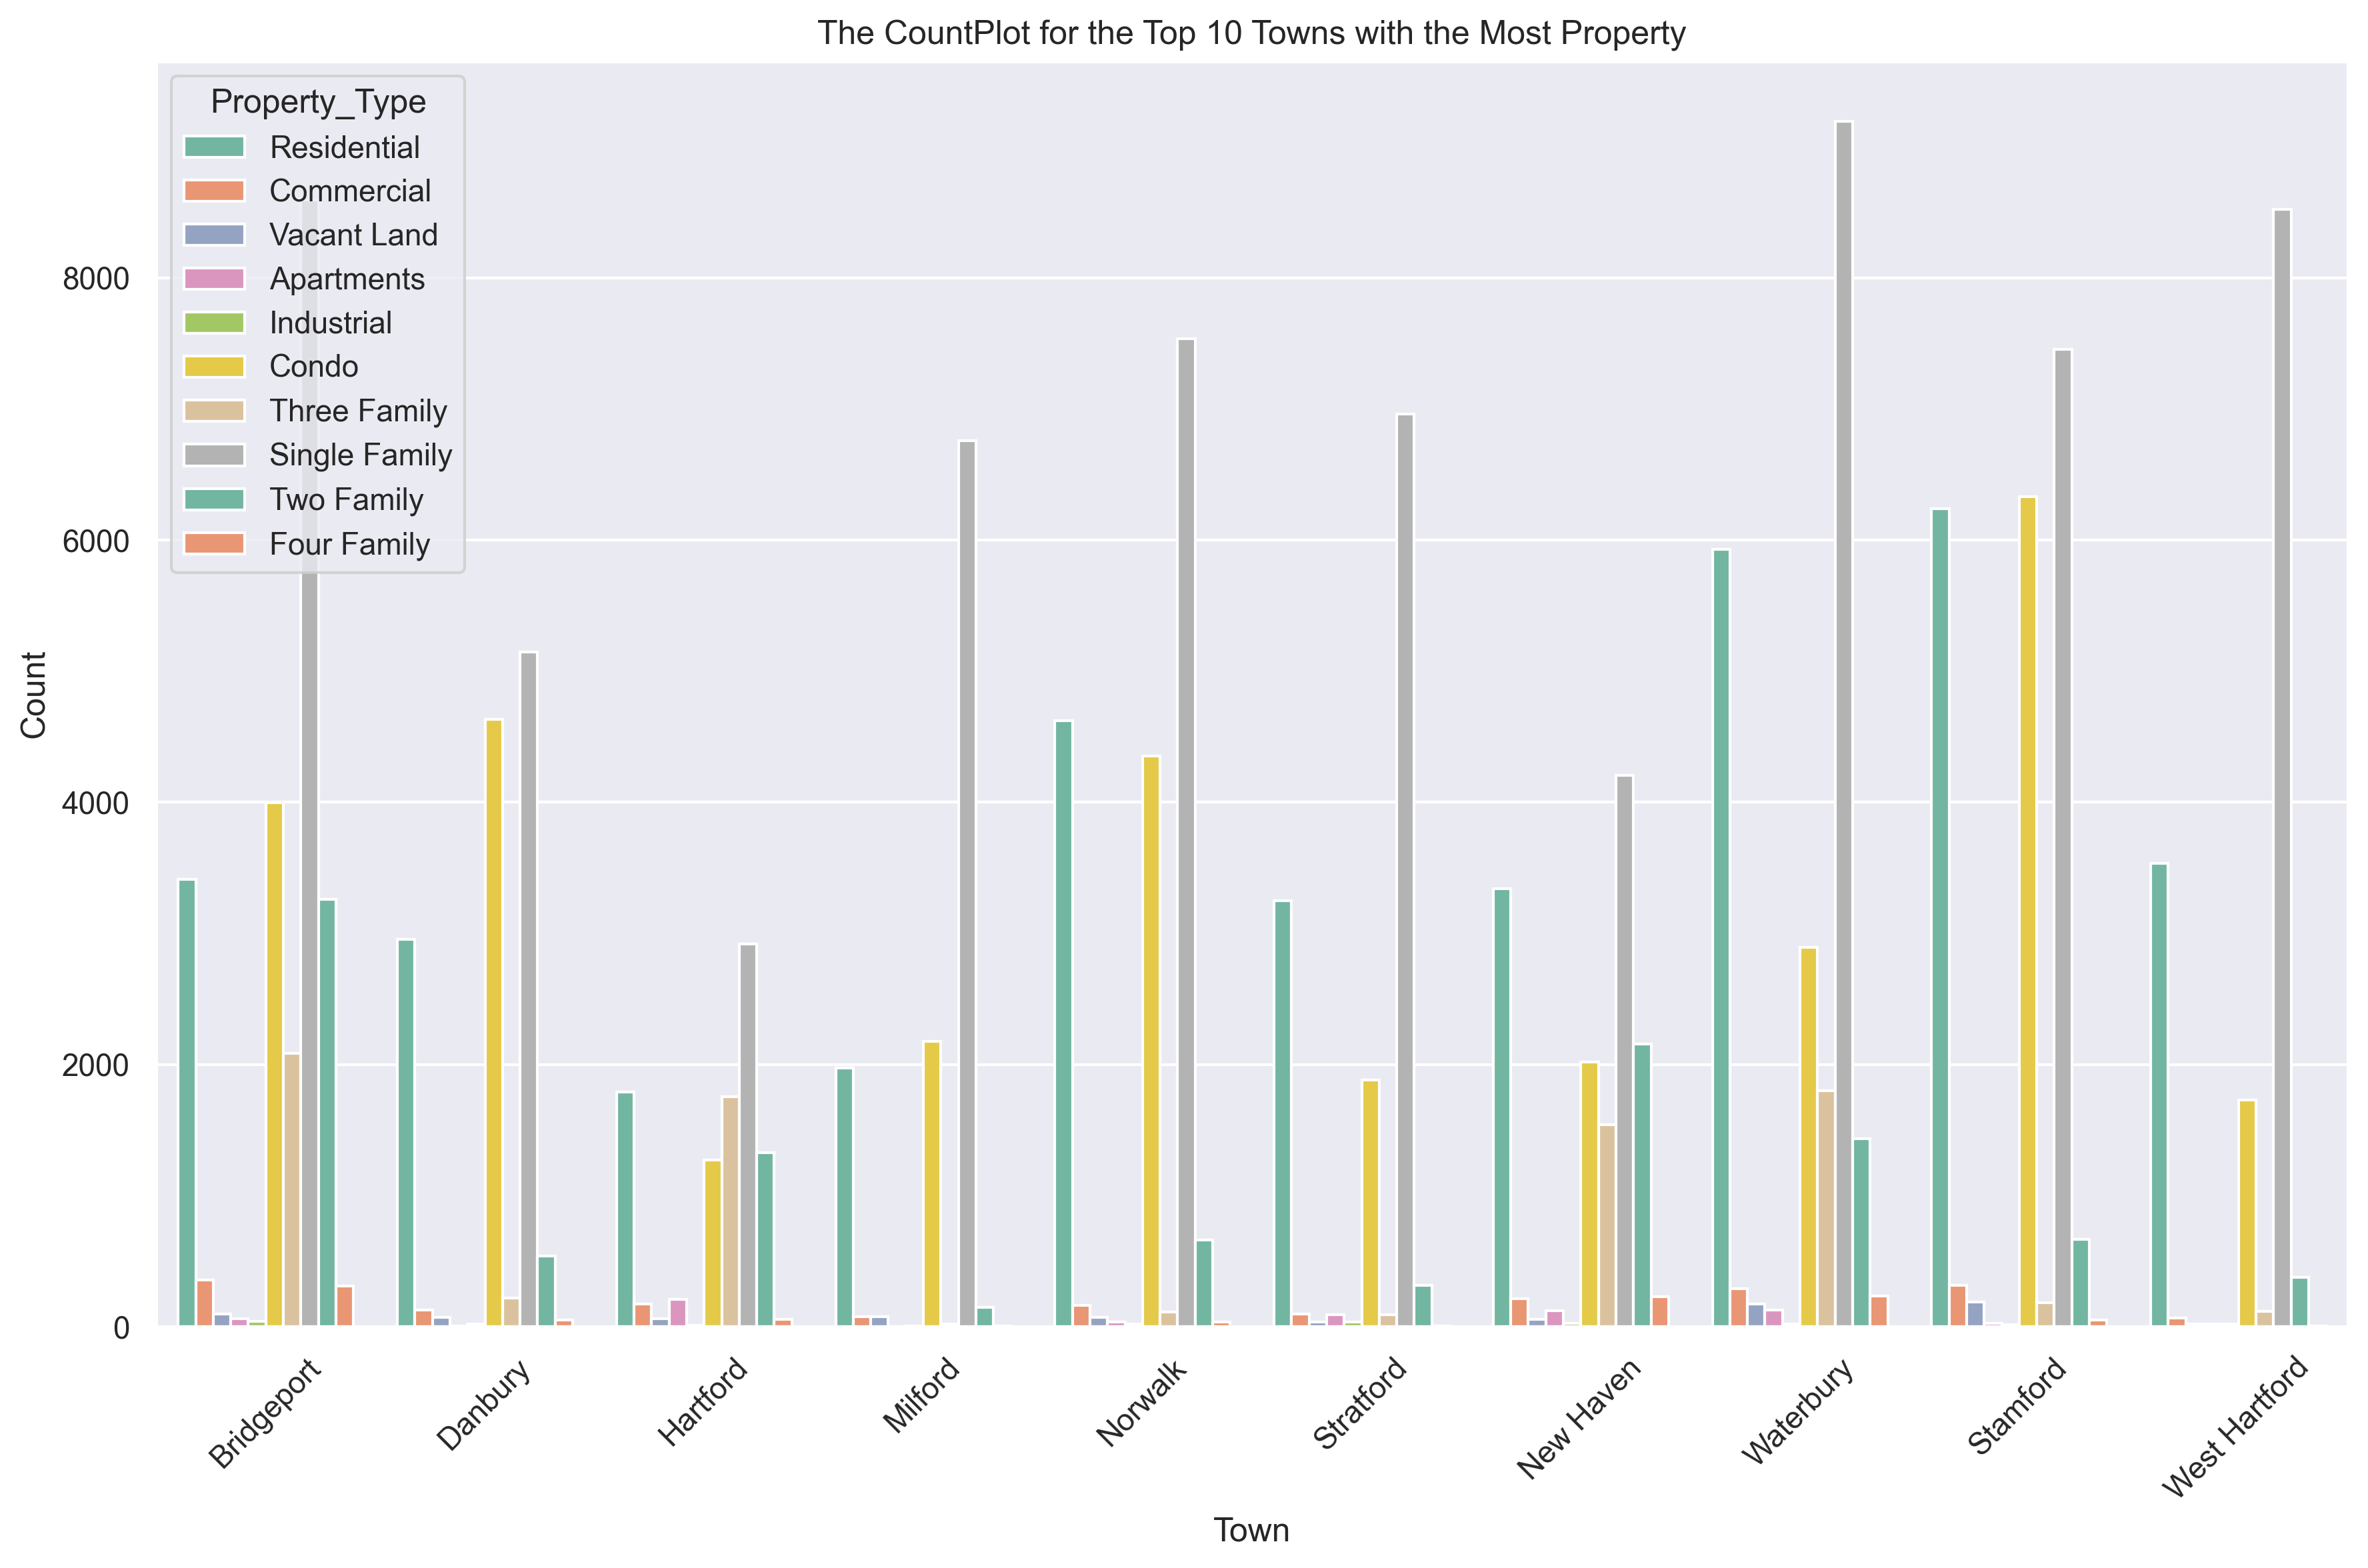

In [17]:
top_10_towns = df['Town'].value_counts().head(10).index
plt.figure(figsize=(12, 8))
sns.countplot(data=df[df['Town'].isin(top_10_towns)], x='Town', hue='Property_Type', palette='Set2')
plt.title('The CountPlot for the Top 10 Towns with the Most Property')
plt.xlabel('Town')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


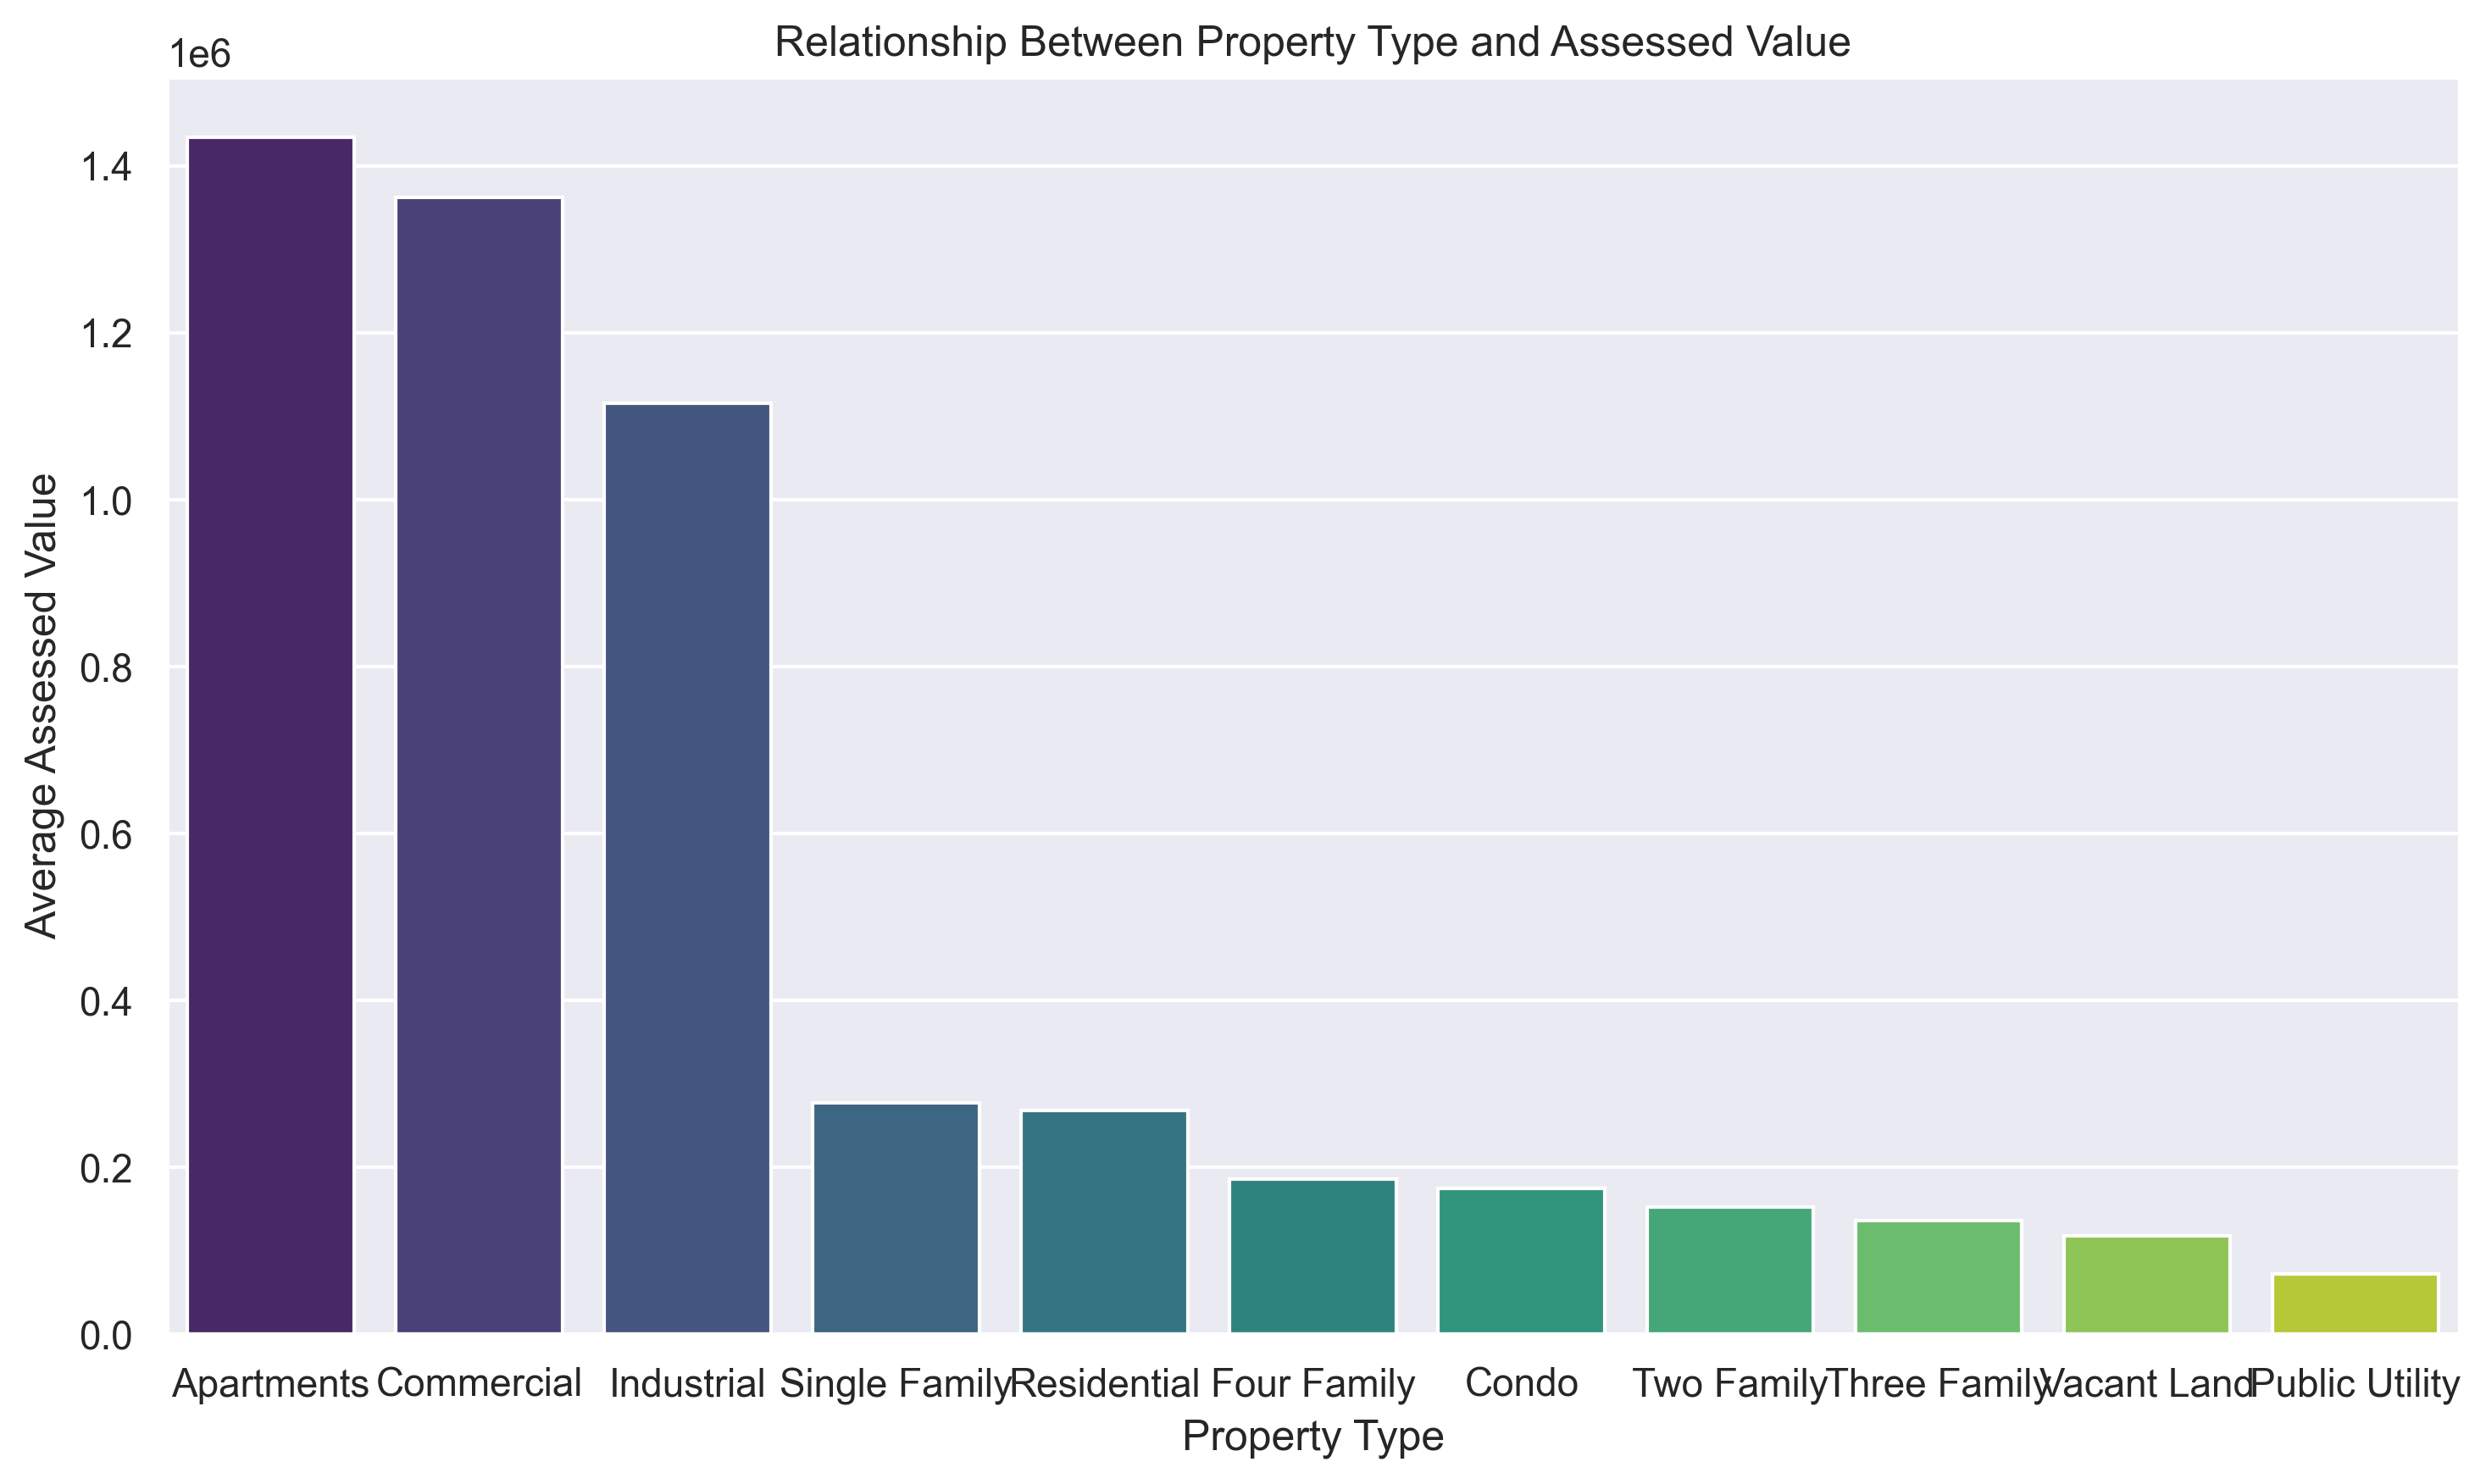

In [18]:
property_value_table = df.groupby('Property_Type')['Assessed_Value'].mean().reset_index()
property_value_table = property_value_table.sort_values(by='Assessed_Value', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=property_value_table, x='Property_Type', y='Assessed_Value', palette='viridis')

plt.title('Relationship Between Property Type and Assessed Value')
plt.xlabel('Property Type')
plt.ylabel('Average Assessed Value')
plt.tight_layout()

plt.show()

### Propert Type Missing Values

There will be **two different approaches** to fill in the missing values for Property Type and Residential Type.

In Property Type, the missing values will be filled based on the mean Assessed Value for each property type. If the Assessed Value of the property is between the specified values (these values were determined via mean value calculation), the property type will be assigned accordingly.

In Residential Type, the mean Assessed Value of the residential types per town will be calculated. The Assessed Value will be compared to those mean values, and the closest mean value residential type will be used to fill in the missing values.

The second approach might seem more logical to apply to the missing values in Property Type as well; however, for the sake of learning practices, both approaches will be retained in the notebook.

In [19]:
df.Property_Type.value_counts()

Property_Type
Single Family     401612
Residential       151064
Condo             105420
Two Family         26408
Three Family       12586
Vacant Land         7824
Commercial          5987
Four Family         2150
Apartments          1327
Industrial           795
Public Utility        10
Name: count, dtype: int64

In [20]:
property_avg_value = df.groupby('Property_Type')['Assessed_Value'].mean().reset_index()
property_avg_value = property_avg_value.rename(columns={'Assessed_Value': 'Avg Assessed Value'})

print(property_avg_value)

     Property_Type  Avg Assessed Value
0       Apartments        1.435348e+06
1       Commercial        1.363012e+06
2            Condo        1.745589e+05
3      Four Family        1.861389e+05
4       Industrial        1.116113e+06
5   Public Utility        7.247500e+04
6      Residential        2.687961e+05
7    Single Family        2.771346e+05
8     Three Family        1.367156e+05
9       Two Family        1.525845e+05
10     Vacant Land        1.179861e+05


In [21]:
df.loc[(df['Residential_Type'].notnull()) & (df['Property_Type'].isnull()), 'Property_Type'] = 'Residential'



def assign_property_type_with_town(row):
    
    town_value = row['Town']
    
   
    if row['Assessed_Value'] < 150000:
        return 'Residential'
    elif 150000 <= row['Assessed_Value'] < 300000:
        if row['Property_Type'] in ['Single Family', 'Two Family', 'Three Family', 'Four Family']:
            return row['Property_Type']
        else:
            return 'Residential'
    elif 300000 <= row['Assessed_Value'] < 500000:
        if row['Property_Type'] in ['Single Family', 'Two Family', 'Four Family']:
            return row['Property_Type']
        else:
            return 'Single Family'
    elif 500000 <= row['Assessed_Value'] < 1000000:
        
        if row['Property_Type'] in ['Commercial', 'Industrial', 'Apartments']:
            return row['Property_Type']
        else:
            return 'Commercial'
    else:
    
        return 'Commercial'


df['Property_Type'] = df.apply(lambda row: assign_property_type_with_town(row) if pd.isnull(row['Property_Type']) else row['Property_Type'], axis=1)


print("Eksik Property Type sayısı:", df['Property_Type'].isnull().sum())

Eksik Property Type sayısı: 0


In [22]:
df.Property_Type.value_counts()

Property_Type
Residential       486634
Single Family     423247
Condo             105420
Commercial         31228
Two Family         26408
Three Family       12586
Vacant Land         7824
Four Family         2150
Apartments          1327
Industrial           795
Public Utility        10
Name: count, dtype: int64

### Residential Type Missing Values

In Residential Type, the mean Assessed Value of the residential types per town will be calculated. The Assessed Value will be compared to those mean values, and the closest mean value residential type will be used to fill in the missing values.

The second approach might seem more logical to apply to the missing values in Property Type as well; however, for the sake of learning practices, both approaches will be retained in the notebook.

In [23]:
df.Residential_Type.value_counts()

Residential_Type
Single Family    508044
Condo            136822
Two Family        34848
Three Family      16567
Four Family        2959
Name: count, dtype: int64

In [24]:
df.Residential_Type.isnull().sum()

np.int64(398389)

In [25]:
df['Residential_Type'] = np.where(
    df['Property_Type'].isin(['Residential', 'Single Family', 'Condo', 'Two Family', 'Three Family', 'Four Family']),
    df['Residential_Type'],  
    'Not Residence'  
)

In [26]:
df.Residential_Type.value_counts()

Residential_Type
Single Family    508044
Condo            136822
Not Residence     41184
Two Family        34848
Three Family      16567
Four Family        2959
Name: count, dtype: int64

In [27]:
df.Residential_Type.isnull().sum()

np.int64(357205)

In [28]:
df[df['Residential_Type'].isna()][['Property_Type', 'Residential_Type']].head(5)

,Property_Type,Residential_Type
67,Residential,NaN
69,Residential,NaN
70,Residential,NaN
71,Residential,NaN
80,Residential,NaN


In [29]:
mean_sales = df.groupby(['Town', 'Residential_Type'])['Assessed_Value'].mean().reset_index()

In [30]:
def fill_missing_property_type(row):
    if pd.isnull(row['Residential_Type']):
        
        town = row['Town']
        price = row['Assessed_Value']
        
        
        city_mean_values = mean_sales[mean_sales['Town'] == town]
        
        
        closest_type = city_mean_values.iloc[(city_mean_values['Assessed_Value'] - price).abs().argsort()[:1]]
        
        return closest_type['Residential_Type'].values[0]
    return row['Residential_Type']


df['Residential_Type'] = df.apply(fill_missing_property_type, axis=1)


print("The number of missing Residential_Type:", df['Residential_Type'].isnull().sum())

The number of missing Residential_Type: 0


In [31]:
df.Residential_Type.value_counts()

Residential_Type
Single Family    531722
Condo            356120
Two Family        93916
Not Residence     46287
Three Family      41518
Four Family       28066
Name: count, dtype: int64

### Location Missing Values

In [32]:
df.Town.unique()

array(['Andover', 'Ansonia', 'Ashford', 'Avon', 'Beacon Falls', 'Berlin',
       'Branford', 'Bethany', 'Bethlehem', 'Bloomfield', 'Bethel',
       'Bridgeport', 'Bristol', 'Cheshire', 'Brookfield', 'Canaan',
       'Canton', 'Cornwall', 'Coventry', 'Chester', 'Colchester',
       'Columbia', 'Canterbury', 'Cromwell', 'Danbury', 'East Lyme',
       'Derby', 'Eastford', 'East Haddam', 'Greenwich', 'East Haven',
       'Farmington', 'Chaplin', 'Clinton', 'East Hampton', 'Easton',
       'Enfield', 'Ellington', 'Hamden', 'Fairfield', 'Essex', 'Hartford',
       'Durham', 'Franklin', 'Glastonbury', 'Killingly', 'Granby',
       'Ledyard', 'Guilford', 'Colebrook', 'Meriden', 'East Windsor',
       'Griswold', 'Bolton', 'Groton', 'Middlebury', 'Madison',
       'Mansfield', 'Harwinton', 'Milford', 'Killingworth', 'Lebanon',
       'Lisbon', 'Litchfield', 'Lyme', 'Manchester', 'New London',
       'New Britain', 'Putnam', 'Norwalk', 'New Milford', 'Norfolk',
       'Stafford', 'New Canaan', '

In [33]:
df = df[df['Town'] != '***Unknown***']

print(df['Town'].unique()) 

['Andover' 'Ansonia' 'Ashford' 'Avon' 'Beacon Falls' 'Berlin' 'Branford'
 'Bethany' 'Bethlehem' 'Bloomfield' 'Bethel' 'Bridgeport' 'Bristol'
 'Cheshire' 'Brookfield' 'Canaan' 'Canton' 'Cornwall' 'Coventry' 'Chester'
 'Colchester' 'Columbia' 'Canterbury' 'Cromwell' 'Danbury' 'East Lyme'
 'Derby' 'Eastford' 'East Haddam' 'Greenwich' 'East Haven' 'Farmington'
 'Chaplin' 'Clinton' 'East Hampton' 'Easton' 'Enfield' 'Ellington'
 'Hamden' 'Fairfield' 'Essex' 'Hartford' 'Durham' 'Franklin' 'Glastonbury'
 'Killingly' 'Granby' 'Ledyard' 'Guilford' 'Colebrook' 'Meriden'
 'East Windsor' 'Griswold' 'Bolton' 'Groton' 'Middlebury' 'Madison'
 'Mansfield' 'Harwinton' 'Milford' 'Killingworth' 'Lebanon' 'Lisbon'
 'Litchfield' 'Lyme' 'Manchester' 'New London' 'New Britain' 'Putnam'
 'Norwalk' 'New Milford' 'Norfolk' 'Stafford' 'New Canaan' 'Sherman'
 'North Haven' 'Stratford' 'Roxbury' 'Oxford' 'New Haven' 'Old Lyme'
 'Norwich' 'Sharon' 'Monroe' 'Tolland' 'Torrington' 'Newtown' 'Naugatuck'
 'Ridgefield' '

In [34]:
from geopy.geocoders import Nominatim
import pandas as pd
import time


towns = ['Andover', 'Ansonia', 'Ashford', 'Avon', 'Beacon Falls', 'Berlin', 'Branford', 'Bethany', 'Bethlehem', 'Bloomfield', 'Bethel', 'Bridgeport', 'Bristol', 
         'Cheshire', 'Brookfield', 'Canaan', 'Canton', 'Cornwall', 'Coventry', 'Chester', 'Colchester', 'Columbia', 'Canterbury', 'Cromwell', 'Danbury', 'East Lyme', 
         'Derby', 'Eastford', 'East Haddam', 'Greenwich', 'East Haven', 'Farmington', 'Chaplin', 'Clinton', 'East Hampton', 'Easton', 'Enfield', 'Ellington', 'Hamden', 
         'Fairfield', 'Essex', 'Hartford', 'Durham', 'Franklin', 'Glastonbury', 'Killingly', 'Granby', 'Ledyard', 'Guilford', 'Colebrook', 'Meriden', 'East Windsor', 
         'Griswold', 'Bolton', 'Groton', 'Middlebury', 'Madison', 'Mansfield', 'Harwinton', 'Milford', 'Killingworth', 'Lebanon', 'Lisbon', 'Litchfield', 'Lyme', 'Manchester', 
         'New London', 'New Britain', 'Putnam', 'Norwalk', 'New Milford', 'Norfolk', 'Stafford', 'New Canaan', 'Sherman', 'North Haven', 'Stratford', 'Roxbury', 'Oxford', 
         'New Haven', 'Old Lyme', 'Norwich', 'Sharon', 'Monroe', 'Tolland', 'Torrington', 'Newtown', 'Naugatuck', 'Ridgefield', 'Orange', 'New Fairfield', 'New Hartford', 
         'Somers', 'Plainfield', 'Suffield', 'Plainville', 'Preston', 'West Haven', 'Morris', 'Wallingford', 'Thompson', 'Stonington', 'Waterbury', 'Stamford', 'Southbury', 
         'Newington', 'Vernon', 'Watertown', 'West Hartford', 'Plymouth', 'Portland', 'Redding', 'Warren', 'Rocky Hill', 'Salem', 'Winchester', 'Shelton', 'Simsbury', 
         'Windsor', 'Woodbury', 'Montville', 'North Branford', 'East Hartford', 'Hampton', 'Hebron', 'Darien', 'Burlington', 'Middlefield', 'Brooklyn', 'Haddam', 'Barkhamsted', 
         'Kent', 'East Granby', 'South Windsor', 'Deep River', 'Marlborough', 'Hartland', 'Washington', 'Sterling', 'Thomaston', 'Waterford', 'Trumbull', 'Old Saybrook', 
         'Westport', 'Westbrook', 'Middletown', 'Goshen', 'Bridgewater', 'Wethersfield', 'Bozrah', 'Willington', 'Wilton', 'Windsor Locks', 'Wolcott', 'Woodstock', 'Prospect', 
         'Southington', 'Windham', 'Weston', 'Voluntown', 'North Canaan', 'Scotland', 'Sprague', 'Pomfret', 'Seymour', 'Woodbridge', 'Union', 'North Stonington', 'Salisbury']

 
geolocator = Nominatim(user_agent="town_locator")


coordinates = []
for town in towns:
    location = geolocator.geocode(f"{town}, CT, USA")
    if location:
        coordinates.append((town, location.latitude, location.longitude))
    else:
        coordinates.append((town, None, None))
    time.sleep(1)  


df_coords = pd.DataFrame(coordinates, columns=['Town', 'Latitude', 'Longitude'])


print(df_coords)

                 Town   Latitude  Longitude
0             Andover  41.737321 -72.370360
1             Ansonia  41.342992 -73.078747
2             Ashford  41.873153 -72.121465
3                Avon  41.809821 -72.830654
4        Beacon Falls  41.442875 -73.062608
5              Berlin  41.621488 -72.745652
6            Branford  41.279541 -72.815099
7             Bethany  41.421764 -72.997050
8           Bethlehem  41.639363 -73.208080
9          Bloomfield  41.826488 -72.730095
10             Bethel  41.371206 -73.414010
11         Bridgeport  41.179269 -73.188786
12            Bristol  41.673521 -72.946486
13           Cheshire  41.498986 -72.900658
14         Brookfield  41.482595 -73.409565
15             Canaan  41.961667 -73.308333
16             Canton  41.824542 -72.893712
17           Cornwall  41.843706 -73.329285
18           Coventry  41.770099 -72.305080
19            Chester  41.403155 -72.450920
20         Colchester  41.575654 -72.332027
21           Columbia  41.702043

In [35]:
df = df.merge(df_coords, on='Town', how='left')

In [36]:
df.head()

,Serial_Number,List_Year,Date_Recorded,Town,Address,Assessed_Value,Sale_Amount,Sales_Ratio,Property_Type,Residential_Type,Non_Use_Code,Assessor_Remarks,OPM_remarks,Location,Latitude,Longitude
0,220008,2022,01/30/2023,Andover,618 ROUTE 6,139020.0,232000.0,0.5992,Residential,Single Family,NaN,NaN,NaN,POINT (-72.343628962 41.728431984),41.737321,-72.370360
1,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,150500.0,325000.0,0.4630,Commercial,Not Residence,NaN,NaN,NaN,NaN,41.342992,-73.078747
2,20002,2020,10/02/2020,Ashford,390 TURNPIKE RD,253000.0,430000.0,0.5883,Residential,Single Family,NaN,NaN,NaN,NaN,41.873153,-72.121465
3,210317,2021,07/05/2022,Avon,53 COTSWOLD WAY,329730.0,805000.0,0.4096,Residential,Single Family,NaN,NaN,NaN,POINT (-72.846365959 41.781677018),41.809821,-72.830654
4,200212,2020,03/09/2021,Avon,5 CHESTNUT DRIVE,130400.0,179900.0,0.7248,Residential,Condo,NaN,NaN,NaN,NaN,41.809821,-72.830654


In [37]:
df.loc[df['Location'].isna(), 'Location'] = df['Longitude'].astype(str) + ', ' + df['Latitude'].astype(str)

In [38]:
df.head()

,Serial_Number,List_Year,Date_Recorded,Town,Address,Assessed_Value,Sale_Amount,Sales_Ratio,Property_Type,Residential_Type,Non_Use_Code,Assessor_Remarks,OPM_remarks,Location,Latitude,Longitude
0,220008,2022,01/30/2023,Andover,618 ROUTE 6,139020.0,232000.0,0.5992,Residential,Single Family,NaN,NaN,NaN,POINT (-72.343628962 41.728431984),41.737321,-72.370360
1,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,150500.0,325000.0,0.4630,Commercial,Not Residence,NaN,NaN,NaN,"-73.0787468, 41.3429922",41.342992,-73.078747
2,20002,2020,10/02/2020,Ashford,390 TURNPIKE RD,253000.0,430000.0,0.5883,Residential,Single Family,NaN,NaN,NaN,"-72.1214653, 41.8731532",41.873153,-72.121465
3,210317,2021,07/05/2022,Avon,53 COTSWOLD WAY,329730.0,805000.0,0.4096,Residential,Single Family,NaN,NaN,NaN,POINT (-72.846365959 41.781677018),41.809821,-72.830654
4,200212,2020,03/09/2021,Avon,5 CHESTNUT DRIVE,130400.0,179900.0,0.7248,Residential,Condo,NaN,NaN,NaN,"-72.8306541, 41.8098209",41.809821,-72.830654


In [39]:
df.Location.isnull().sum()

np.int64(0)

### Date Format: Can we convert Date Recorded into a proper datetime format for better analysis?

In [40]:
df.Date_Recorded.value_counts().head(5)

Date_Recorded
07/01/2005    877
08/01/2005    859
07/01/2004    840
06/30/2005    828
09/30/2005    781
Name: count, dtype: int64

In [41]:
df.Date_Recorded.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1097628 entries, 0 to 1097627
Series name: Date_Recorded
Non-Null Count    Dtype 
--------------    ----- 
1097626 non-null  object
dtypes: object(1)
memory usage: 8.4+ MB


In [42]:
df.Date_Recorded.isnull().sum()

np.int64(2)

In [43]:
df.dropna(subset=['Date_Recorded'], inplace=True)

In [44]:
df['Date_Recorded'] = pd.to_datetime(df['Date_Recorded'])

In [45]:
df.Date_Recorded.info()

<class 'pandas.core.series.Series'>
Index: 1097626 entries, 0 to 1097627
Series name: Date_Recorded
Non-Null Count    Dtype         
--------------    -----         
1097626 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 16.7 MB


### String Cleaning: Should the Address and Town columns be cleaned for uniformity (e.g., removing excess spaces, fixing capitalization)?

##### Address and town columns were examined and it was concluded that no data manipulation is necessary.

In [46]:
df.Town.unique()

array(['Andover', 'Ansonia', 'Ashford', 'Avon', 'Beacon Falls', 'Berlin',
       'Branford', 'Bethany', 'Bethlehem', 'Bloomfield', 'Bethel',
       'Bridgeport', 'Bristol', 'Cheshire', 'Brookfield', 'Canaan',
       'Canton', 'Cornwall', 'Coventry', 'Chester', 'Colchester',
       'Columbia', 'Canterbury', 'Cromwell', 'Danbury', 'East Lyme',
       'Derby', 'Eastford', 'East Haddam', 'Greenwich', 'East Haven',
       'Farmington', 'Chaplin', 'Clinton', 'East Hampton', 'Easton',
       'Enfield', 'Ellington', 'Hamden', 'Fairfield', 'Essex', 'Hartford',
       'Durham', 'Franklin', 'Glastonbury', 'Killingly', 'Granby',
       'Ledyard', 'Guilford', 'Colebrook', 'Meriden', 'East Windsor',
       'Griswold', 'Bolton', 'Groton', 'Middlebury', 'Madison',
       'Mansfield', 'Harwinton', 'Milford', 'Killingworth', 'Lebanon',
       'Lisbon', 'Litchfield', 'Lyme', 'Manchester', 'New London',
       'New Britain', 'Putnam', 'Norwalk', 'New Milford', 'Norfolk',
       'Stafford', 'New Canaan', '

In [47]:
df.Address.sample(50)

504792                 19 VILLAGE RD
627099               78 TEMPLE DRIVE
1004873            63 SHERWOOD PLACE
509550               68 BATTERSON DR
935089               13 RIVERSIDE DR
55415      300 FLAX HILL RD UNIT 12B
379467                  13F BYRNE CT
245617                CALKINSTOWN RD
200532                 25 C AMATO DR
143801             335 WESTPORT ROAD
592589           18 STADLEY ROUGH RD
748552              6-13 BAMFORTH RD
144478                 23 LAKE RIDGE
534731               7 SILVER BRK RD
108533         118 WASHINGTON ST 309
870046             8 SOUTHEAST TRAIL
160230                 71 MAXWELL DR
811850               48 ESSEX STREET
7132                    114 FITCH ST
732614               372 MAIN STREET
2110                   110 BENHAM ST
579013              198 BROOKSIDE RD
309226                2 HOMESTEAD LN
533840                  20 TERRIE RD
990961              7 DECUBELLIS CRT
253789       11 OLD STAGECOACH CROSS
171499                  205 WELLS RD
9

### Location Parsing: Should we split the Location column into latitude and longitude for easier geospatial analysis?

#### The Location column was populated based on the data in the Town column as a result of the operations performed above, and two new columns, Latitude and Longitude, were added to the DataFrame

In [48]:
df[['Town', 'Location', 'Latitude', 'Longitude']].head(10)

,Town,Location,Latitude,Longitude
0,Andover,POINT (-72.343628962 41.728431984),41.737321,-72.370360
1,Ansonia,"-73.0787468, 41.3429922",41.342992,-73.078747
2,Ashford,"-72.1214653, 41.8731532",41.873153,-72.121465
3,Avon,POINT (-72.846365959 41.781677018),41.809821,-72.830654
4,Avon,"-72.8306541, 41.8098209",41.809821,-72.830654
5,Avon,"-72.8306541, 41.8098209",41.809821,-72.830654
6,Avon,"-72.8306541, 41.8098209",41.809821,-72.830654
7,Beacon Falls,POINT (-73.053071989 41.439434021),41.442875,-73.062608
8,Avon,"-72.8306541, 41.8098209",41.809821,-72.830654
9,Berlin,"-72.7456519, 41.621488",41.621488,-72.745652


### Outlier Detection: Are there outliers in Sale Amount or Assessed Value, and how should they be handled?

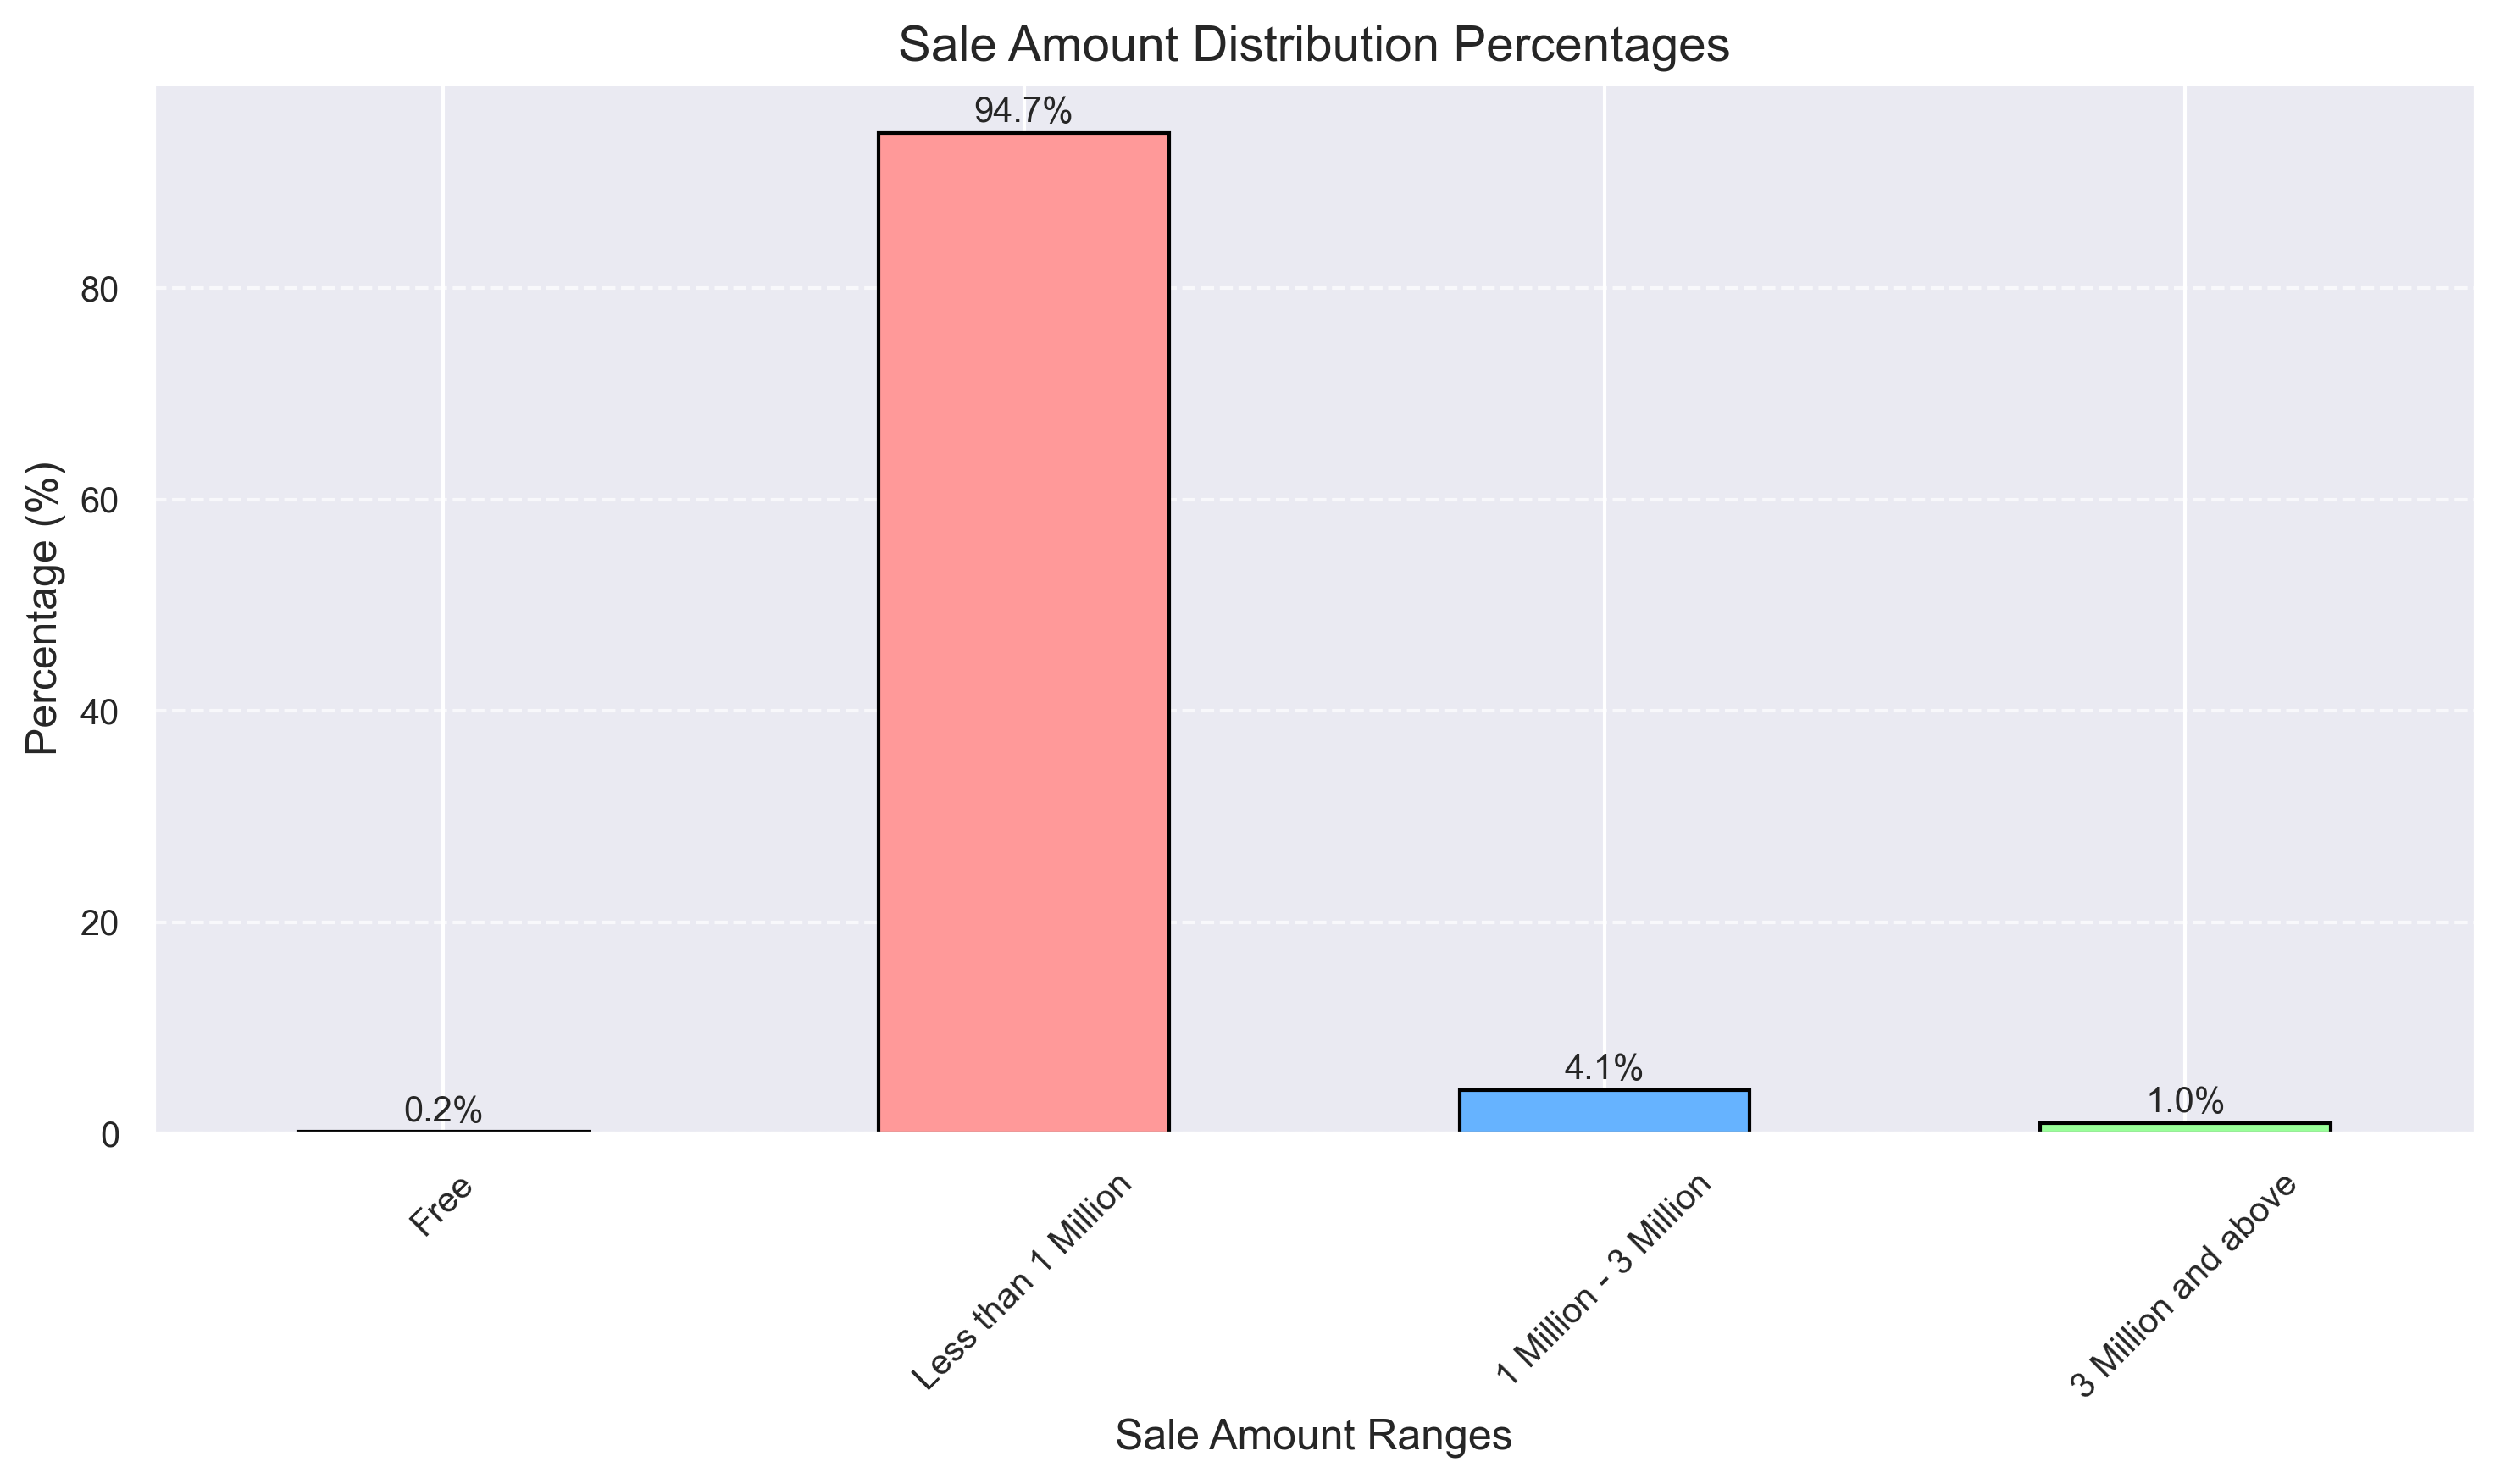

In [49]:
bins = [0, 1, 1000000, 3000000, float('inf')]
labels = ['Free', 'Less than 1 Million', '1 Million - 3 Million', '3 Million and above']

category_counts = pd.cut(df['Sale_Amount'], bins=bins, labels=labels, right=False).value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
colors = ['#FFCC99', '#FF9999', '#66B3FF', '#99FF99']
category_counts.sort_index().plot(kind='bar', color=colors, edgecolor='black')

plt.title('Sale Amount Distribution Percentages', fontsize=14)
plt.xlabel('Sale Amount Ranges', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(category_counts.sort_index()):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


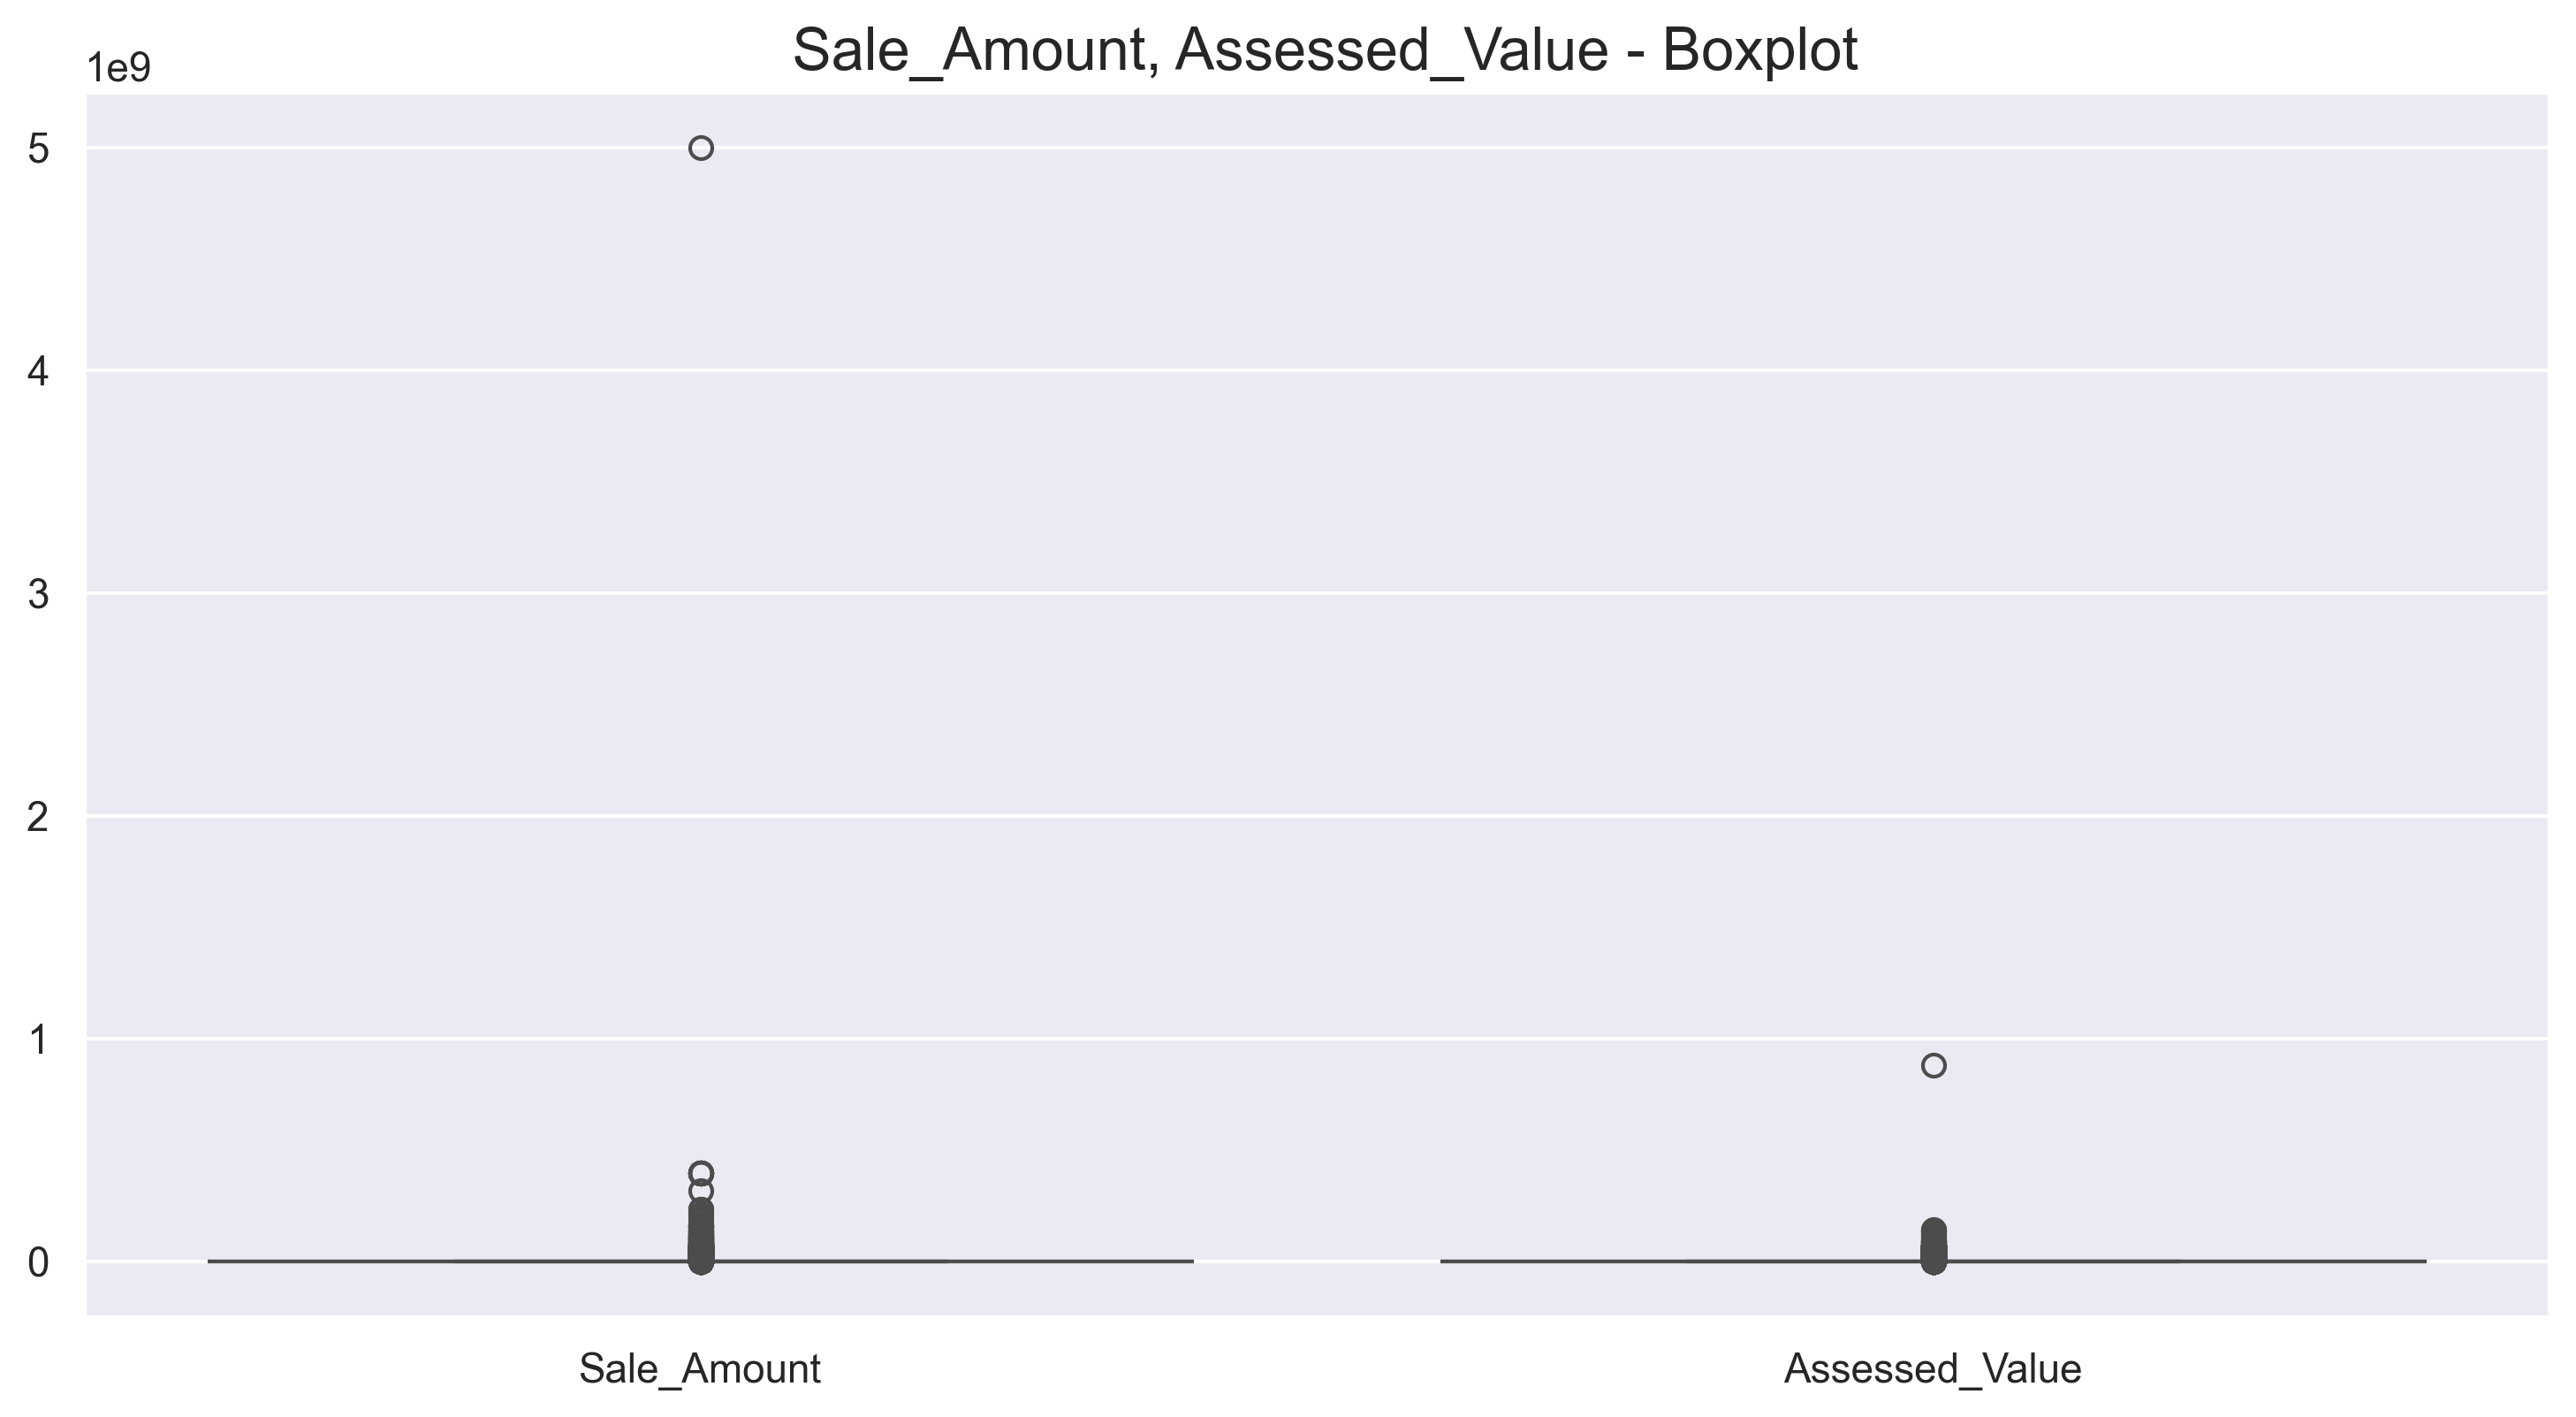

In [50]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[['Sale_Amount', 'Assessed_Value']])


plt.title(" Sale_Amount, Assessed_Value - Boxplot", fontsize=16)

plt.show()

In [51]:
print(df[['Sale_Amount', 'Assessed_Value']].describe())

        Sale_Amount  Assessed_Value
count  1.097626e+06    1.097626e+06
mean   4.053154e+05    2.818023e+05
std    5.143499e+06    1.657892e+06
min    0.000000e+00    0.000000e+00
25%    1.450000e+05    8.909000e+04
50%    2.330000e+05    1.405800e+05
75%    3.750000e+05    2.282700e+05
max    5.000000e+09    8.815100e+08


In [52]:
Q1 = df[['Sale_Amount', 'Assessed_Value']].quantile(0.25)
Q3 = df[['Sale_Amount', 'Assessed_Value']].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

lower_bound = lower_bound.reindex(df[['Sale_Amount', 'Assessed_Value']].columns)
upper_bound = upper_bound.reindex(df[['Sale_Amount', 'Assessed_Value']].columns)

outliers = (df[['Sale_Amount', 'Assessed_Value']] < lower_bound) | (df[['Sale_Amount', 'Assessed_Value']] > upper_bound)

print("Number of Outliers - Sale Amount:", outliers['Sale_Amount'].sum())
print("Number of Outliers - Assessed Value:", outliers['Assessed_Value'].sum())


Number of Outliers - Sale Amount: 51858
Number of Outliers - Assessed Value: 57407


In [53]:
df['Sale_Amount_log'] = np.log1p(df['Sale_Amount'])
df['Assessed_Value_log'] = np.log1p(df['Assessed_Value'])

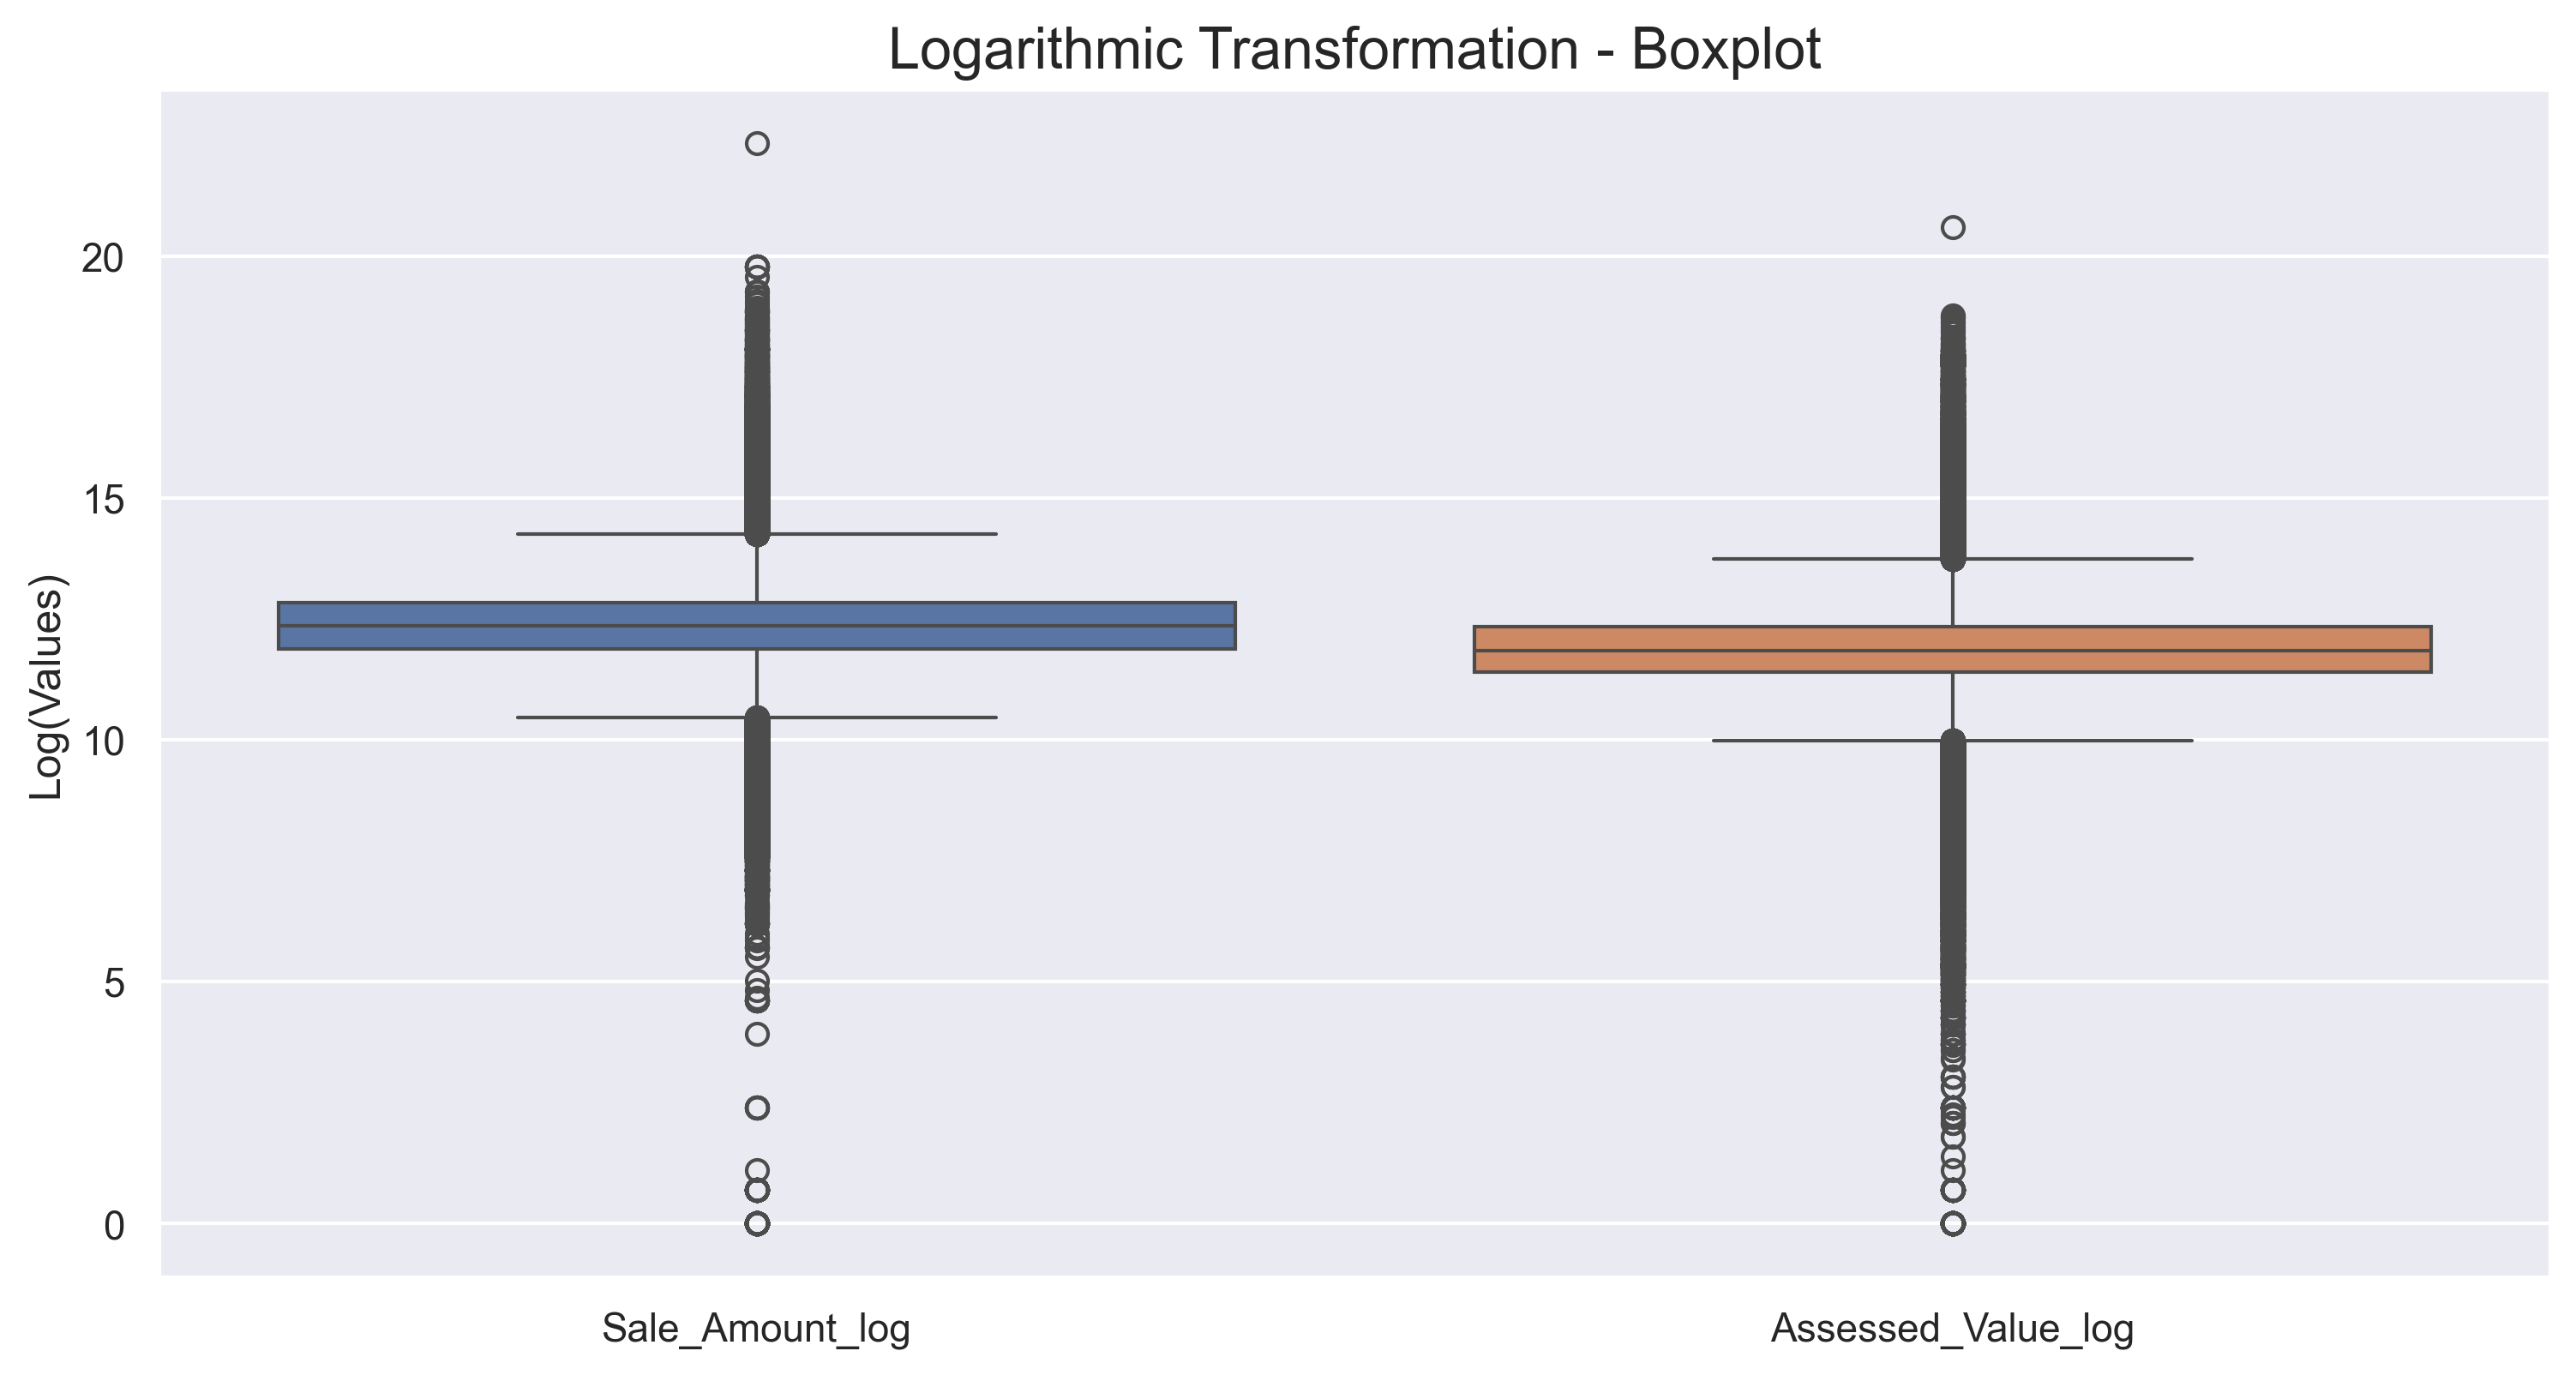

In [54]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[['Sale_Amount_log', 'Assessed_Value_log']])

plt.title("Logarithmic Transformation - Boxplot", fontsize=16)
plt.ylabel("Log(Values)", fontsize=12)
plt.show()


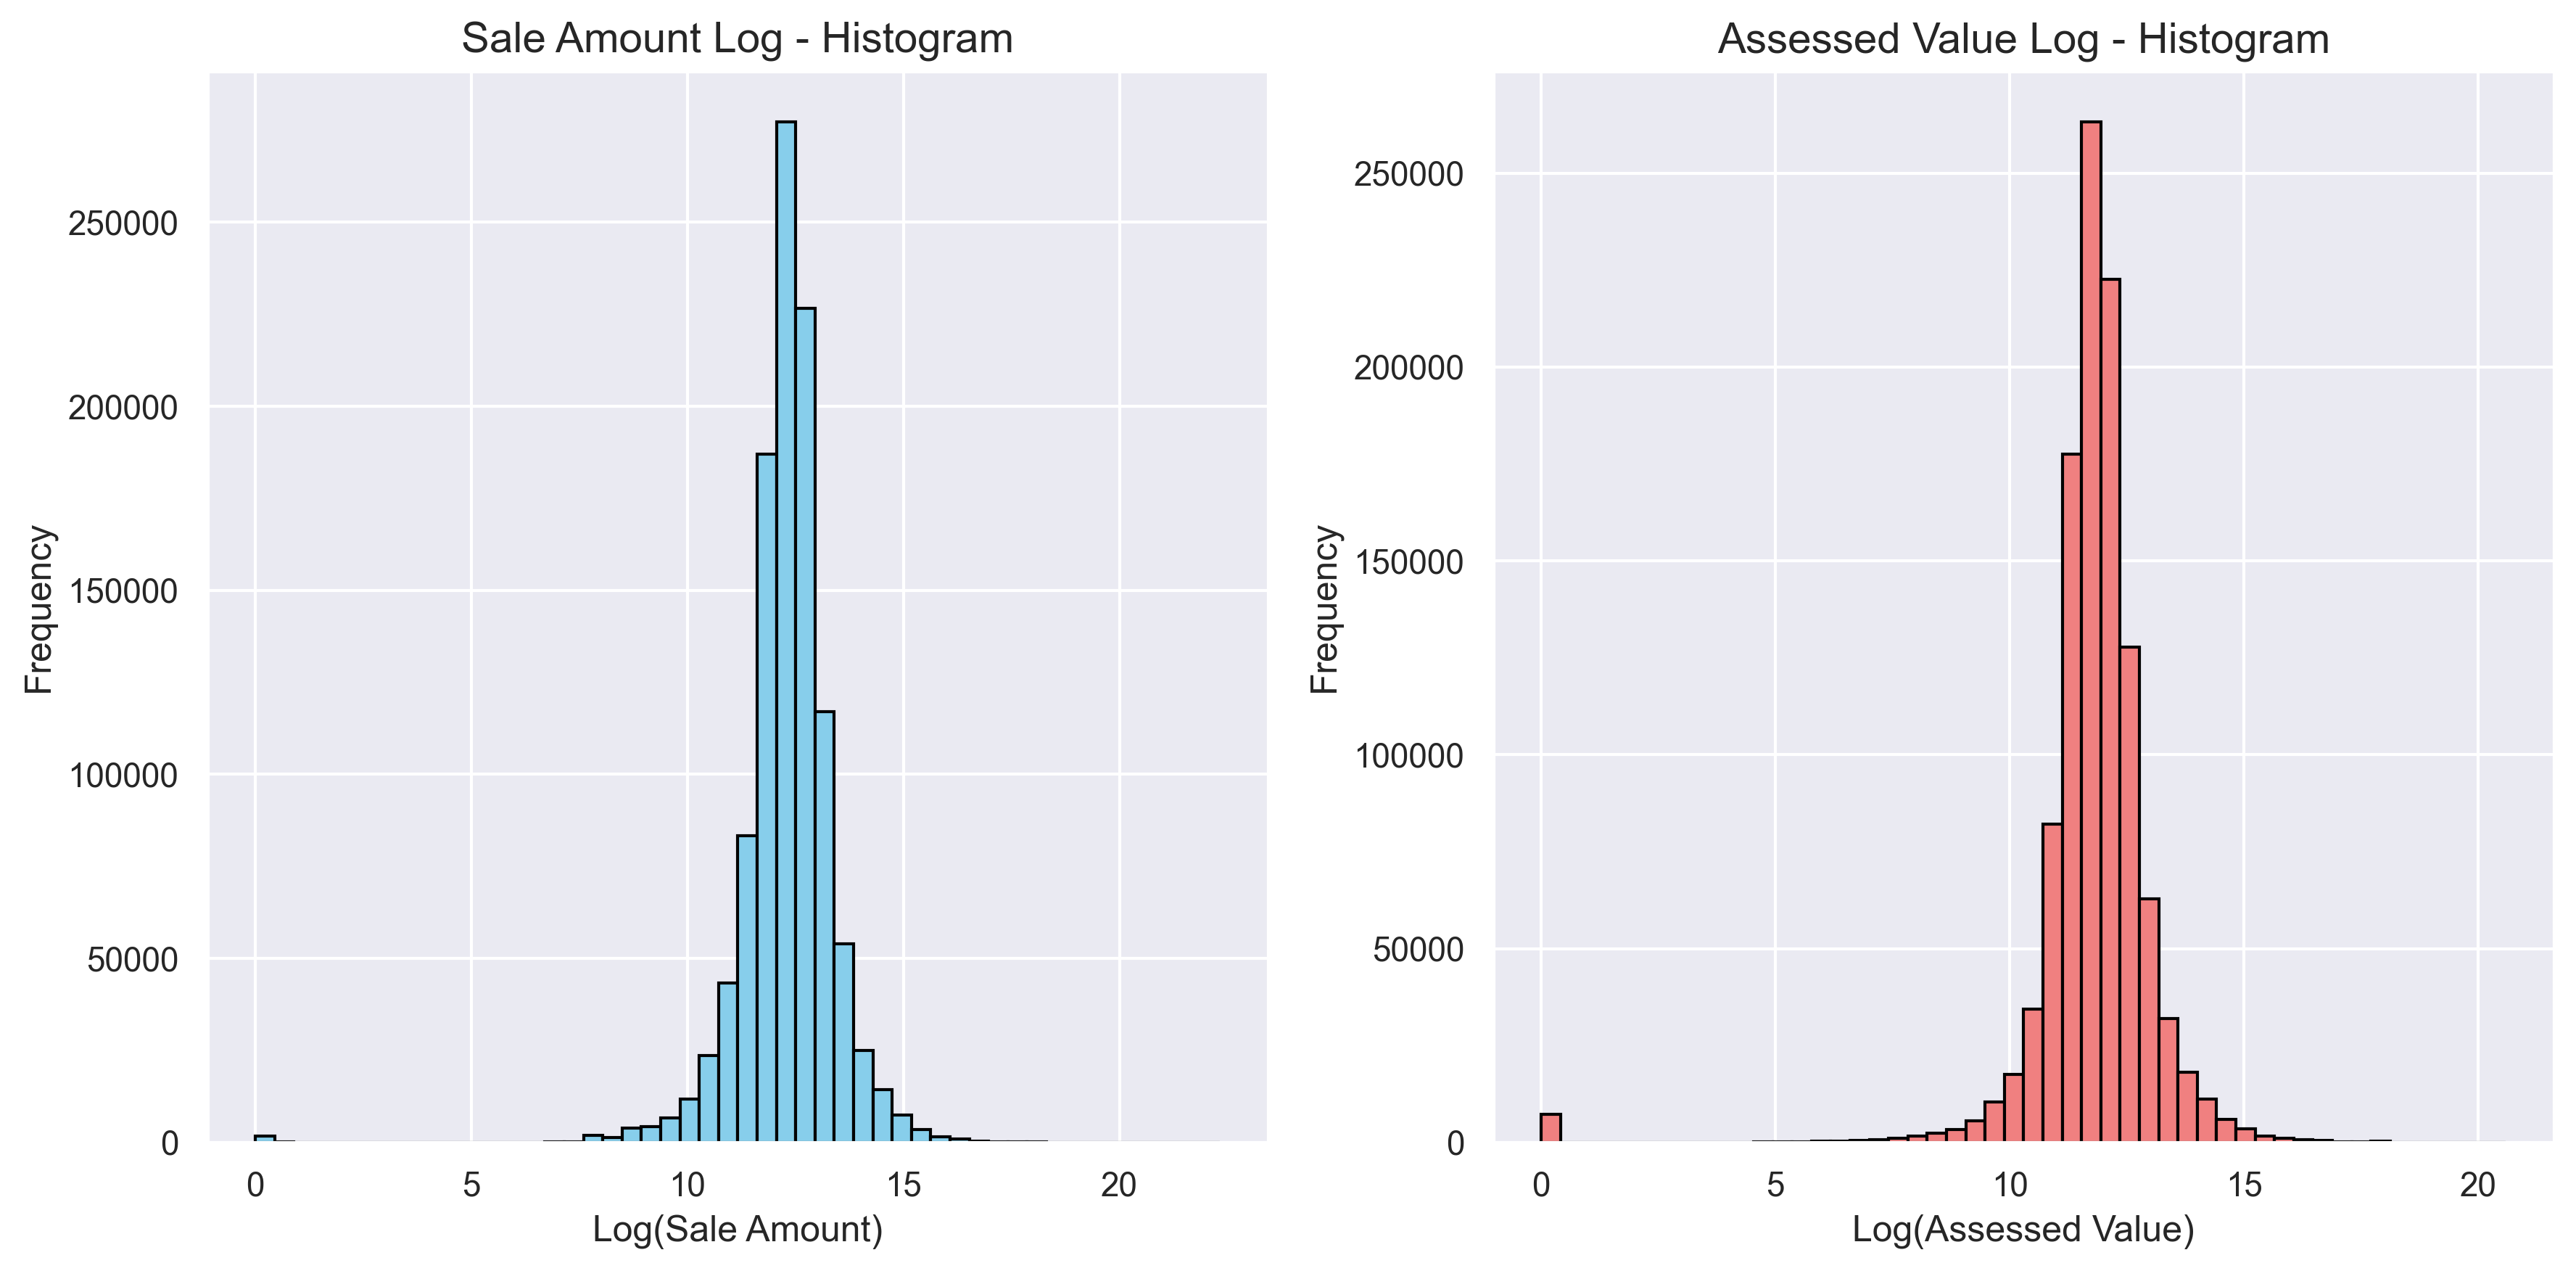

In [55]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) 
plt.hist(df['Sale_Amount_log'], bins=50, color='skyblue', edgecolor='black')
plt.title("Sale Amount Log - Histogram", fontsize=14)
plt.xlabel("Log(Sale Amount)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.subplot(1, 2, 2)  
plt.hist(df['Assessed_Value_log'], bins=50, color='lightcoral', edgecolor='black')
plt.title("Assessed Value Log - Histogram", fontsize=14)
plt.xlabel("Log(Assessed Value)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()  
plt.show()

In [56]:
# Sale_Amount_log ve Assessed_Value_log için describe
log_summary = df[['Sale_Amount_log', 'Assessed_Value_log']].describe()
print(log_summary)

       Sale_Amount_log  Assessed_Value_log
count     1.097626e+06        1.097626e+06
mean      1.231562e+01        1.180209e+01
std       1.095200e+00        1.365230e+00
min       0.000000e+00        0.000000e+00
25%       1.188450e+01        1.139741e+01
50%       1.235880e+01        1.185354e+01
75%       1.283468e+01        1.233829e+01
max       2.233270e+01        2.059715e+01


##### Based on the missing data analysis, the sale amount higher than 3 million are specified as outliers, and deleted from data for cleaning purpose

##### Eksik veri analizine dayanarak, 3 milyondan fazla satış tutarı uç değer olarak belirlenir ve temizleme amacıyla verilerden silinir.

In [57]:
data = df[(df['Sale_Amount'] <= 3000000) & (df['Assessed_Value'] <= 3000000)]

print("Rows with values above 3 million in either Sale_Amount or Assessed_Value have been removed. New DataFrame shape:", data.shape)

Rows with values above 3 million in either Sale_Amount or Assessed_Value have been removed. New DataFrame shape: (1083606, 18)


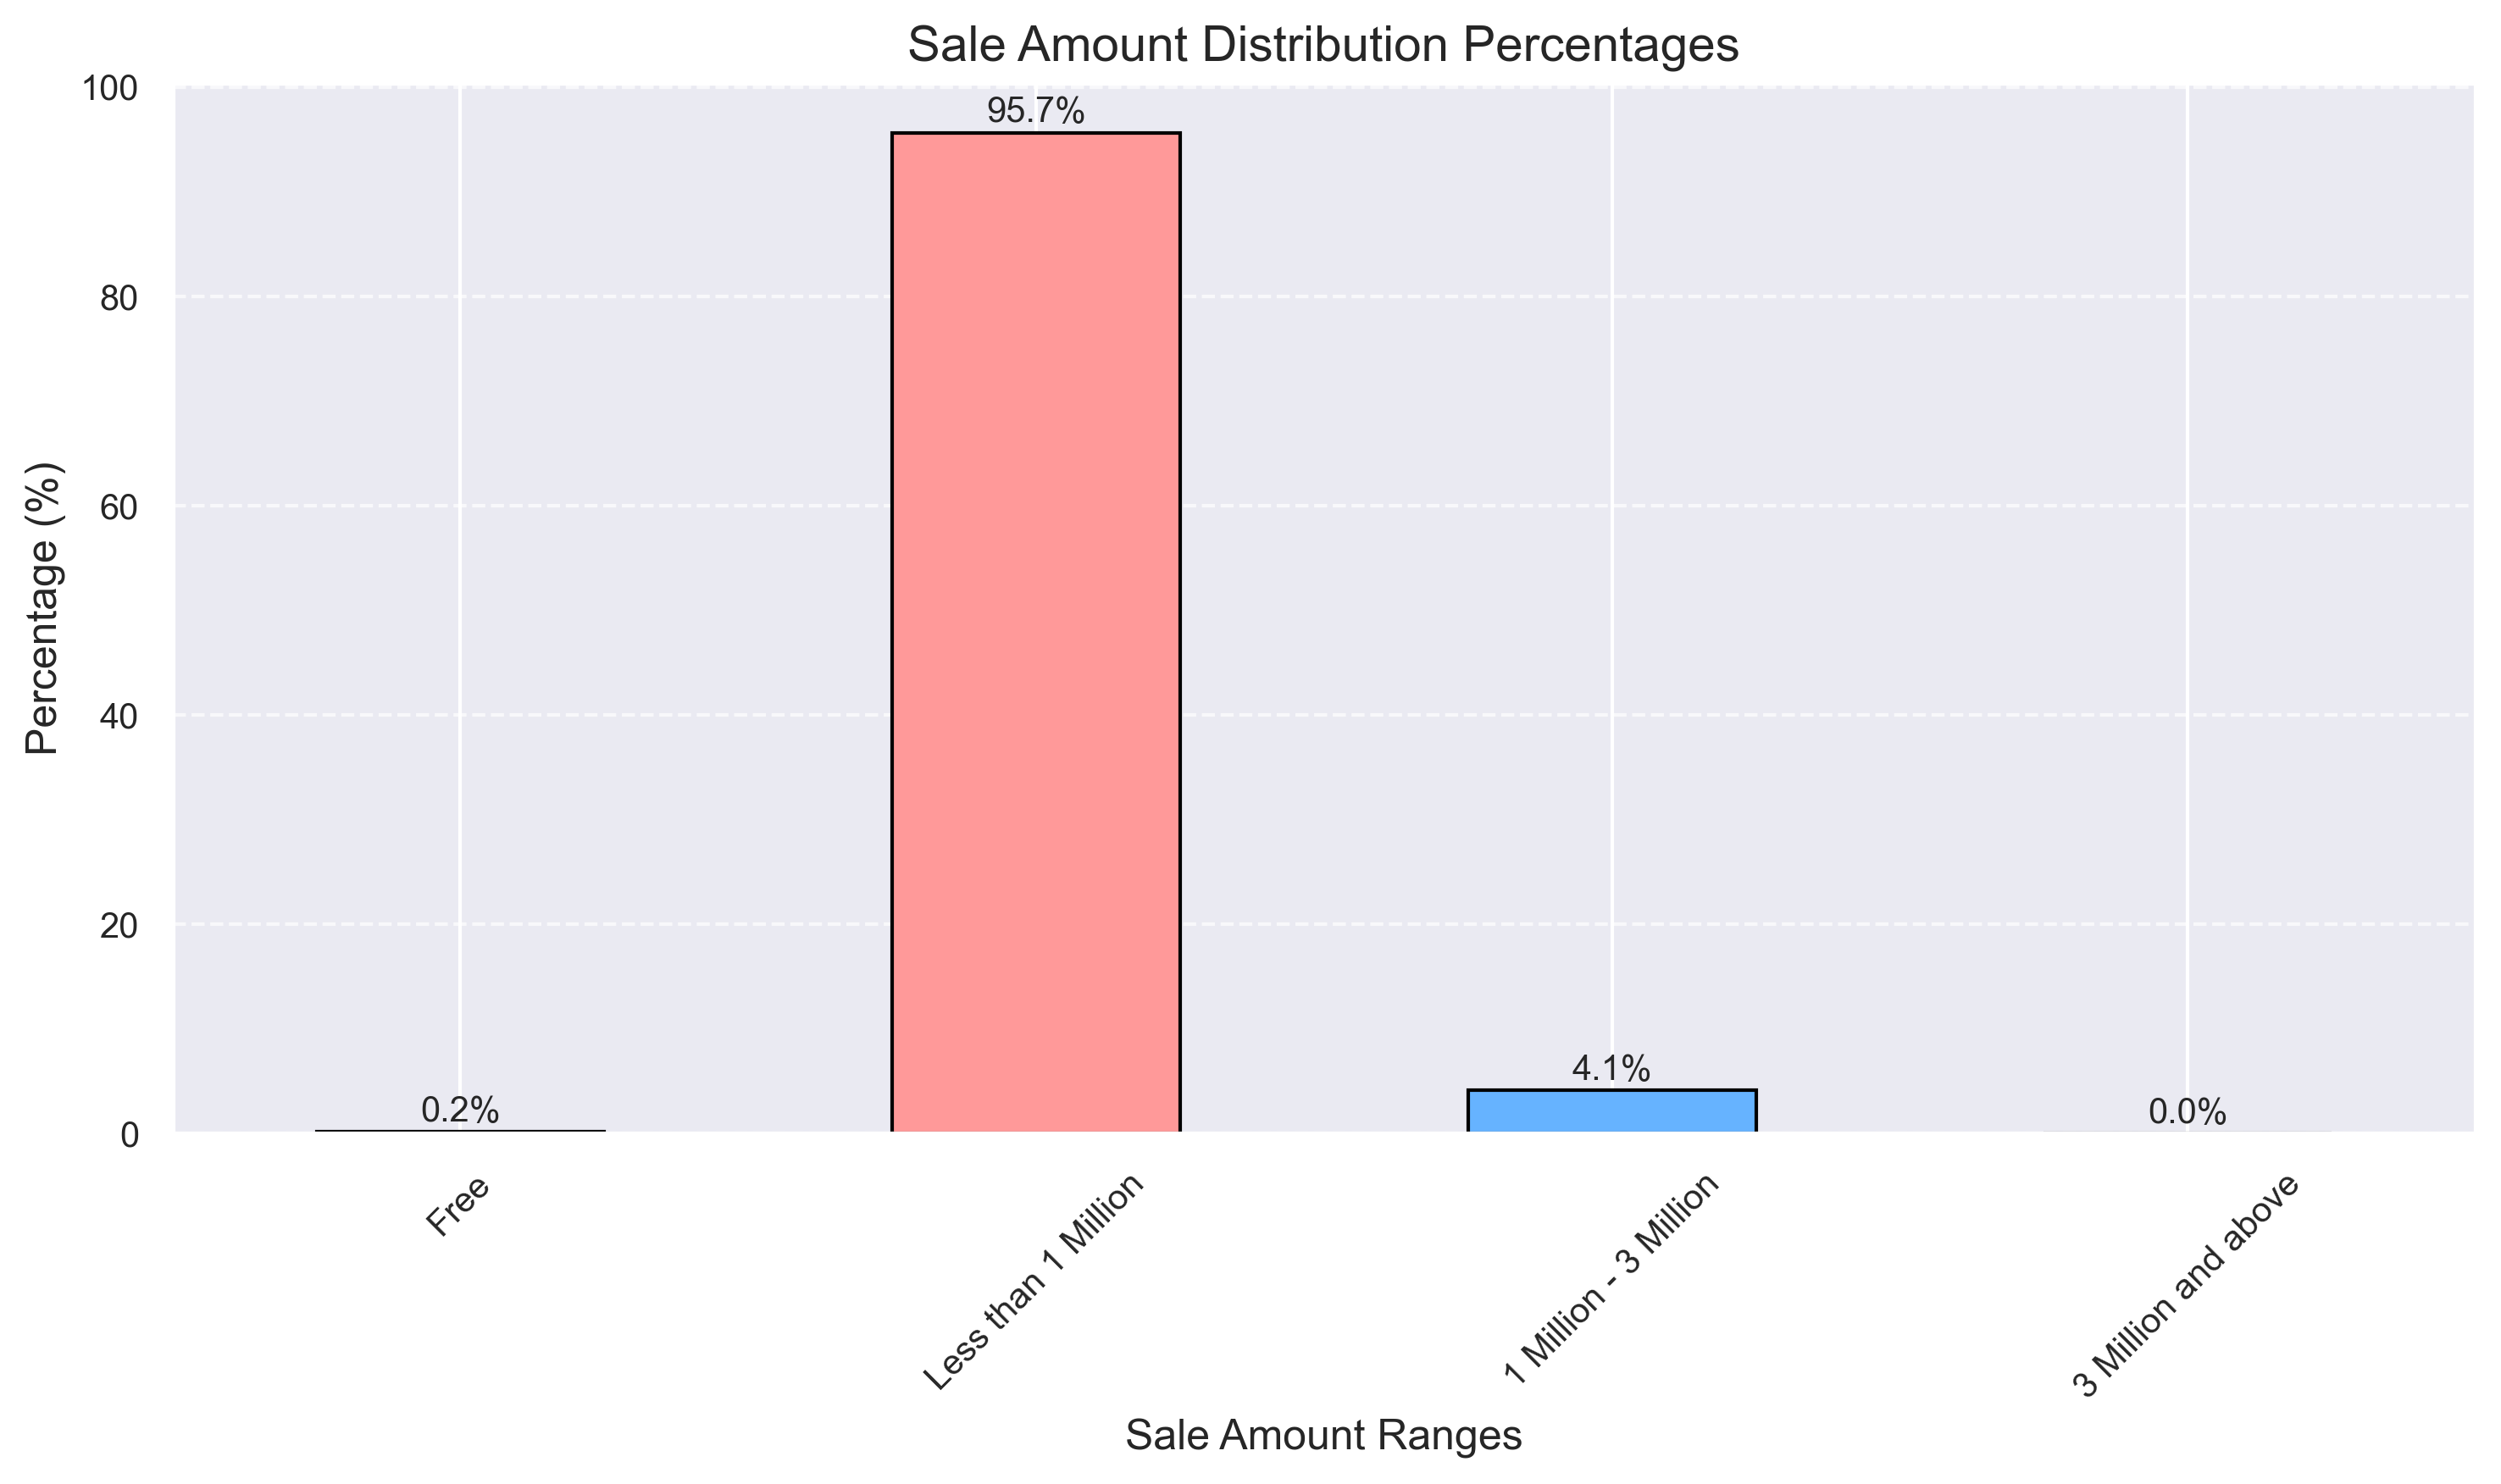

In [58]:

bins = [0, 1, 1000000, 3000000, float('inf')]
labels = ['Free', 'Less than 1 Million', '1 Million - 3 Million', '3 Million and above']

category_counts = pd.cut(data['Sale_Amount'], bins=bins, labels=labels, right=False).value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
colors = ['#FFCC99', '#FF9999', '#66B3FF', '#99FF99']
category_counts.sort_index().plot(kind='bar', color=colors, edgecolor='black')

plt.title('Sale Amount Distribution Percentages', fontsize=14)
plt.xlabel('Sale Amount Ranges', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(category_counts.sort_index()):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [59]:
data.Sale_Amount.describe()

count    1.083606e+06
mean     3.220228e+05
std      3.403882e+05
min      0.000000e+00
25%      1.442000e+05
50%      2.300000e+05
75%      3.700000e+05
max      3.000000e+06
Name: Sale_Amount, dtype: float64

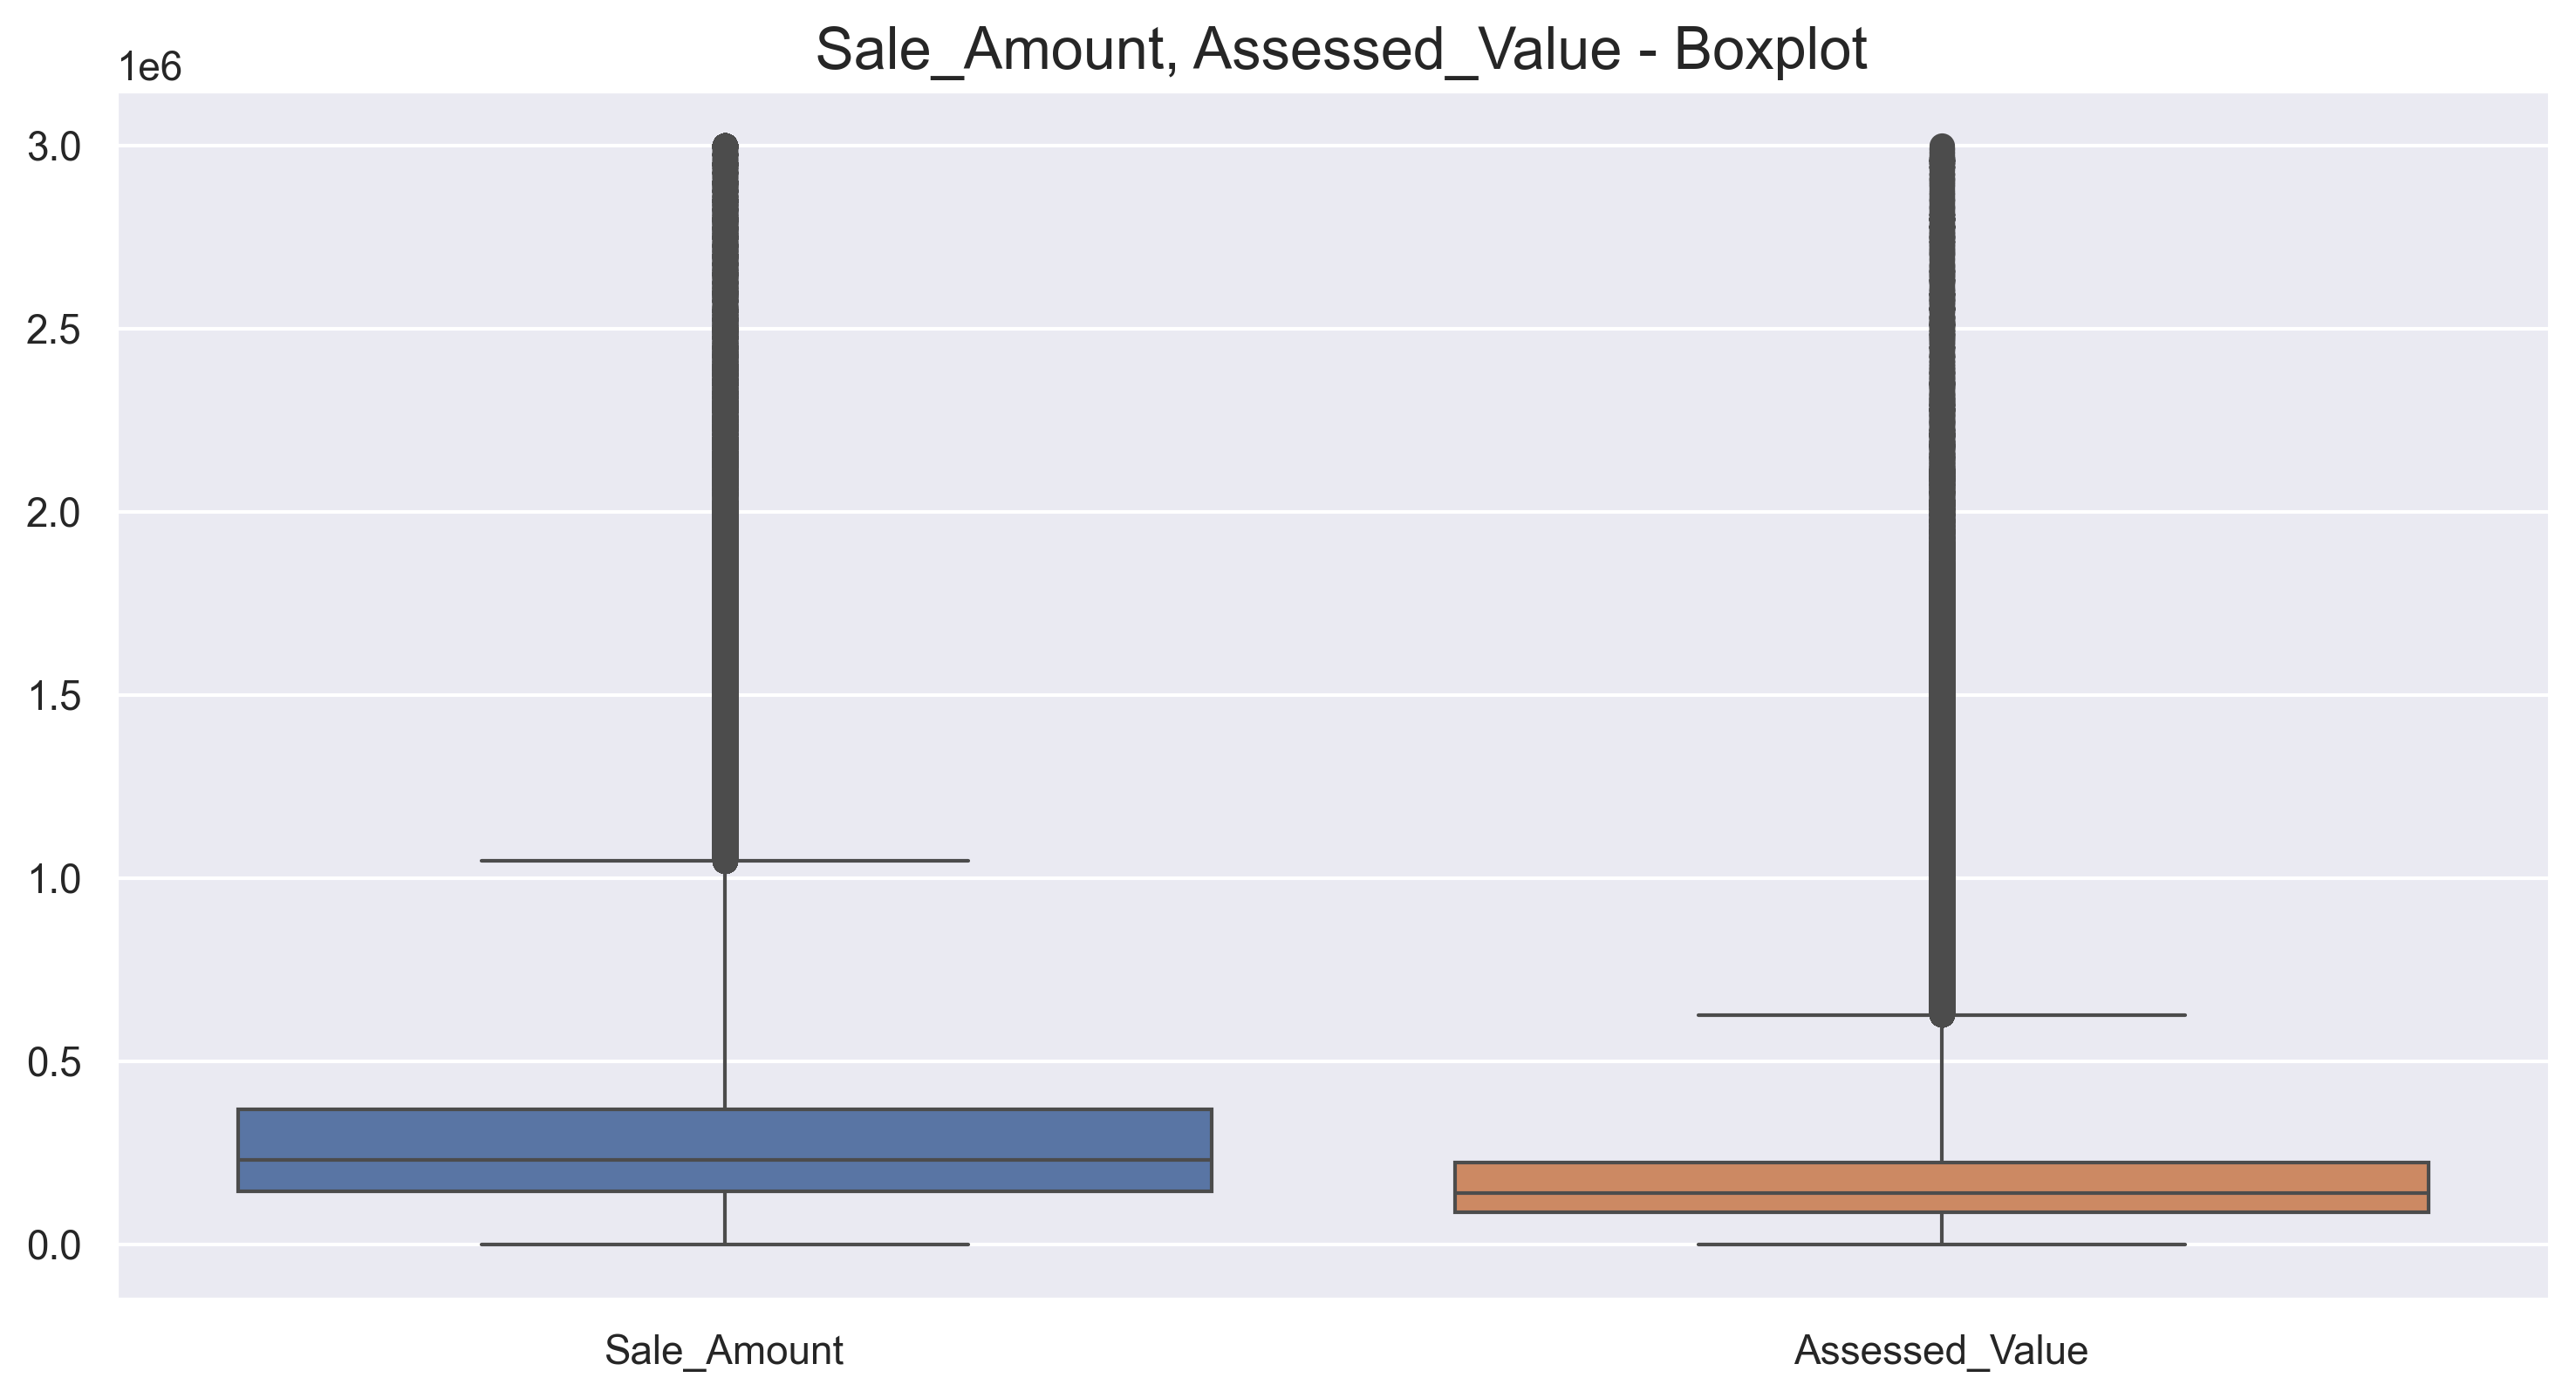

In [60]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=data[['Sale_Amount', 'Assessed_Value']], whis = 3)


plt.title(" Sale_Amount, Assessed_Value - Boxplot", fontsize=16)

plt.show()

In [61]:
print(data[['Sale_Amount', 'Assessed_Value']].describe())

        Sale_Amount  Assessed_Value
count  1.083606e+06    1.083606e+06
mean   3.220228e+05    2.017832e+05
std    3.403882e+05    2.348004e+05
min    0.000000e+00    0.000000e+00
25%    1.442000e+05    8.852000e+04
50%    2.300000e+05    1.392300e+05
75%    3.700000e+05    2.231800e+05
max    3.000000e+06    2.999710e+06


In [62]:
Q1 = data[['Sale_Amount', 'Assessed_Value']].quantile(0.25)
Q3 = data[['Sale_Amount', 'Assessed_Value']].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

lower_bound = lower_bound.reindex(data[['Sale_Amount', 'Assessed_Value']].columns)
upper_bound = upper_bound.reindex(data[['Sale_Amount', 'Assessed_Value']].columns)

outliers = (data[['Sale_Amount', 'Assessed_Value']] < lower_bound) | (data[['Sale_Amount', 'Assessed_Value']] > upper_bound)

print("Number of outliers - Sale Amount:", outliers['Sale_Amount'].sum())
print("Number of outliers - Assessed Value:", outliers['Assessed_Value'].sum())


Number of outliers - Sale Amount: 42230
Number of outliers - Assessed Value: 46604


In [63]:
data['Sale_Amount_log'] = np.log1p(data['Sale_Amount'])
data['Assessed_Value_log'] = np.log1p(data['Assessed_Value'])

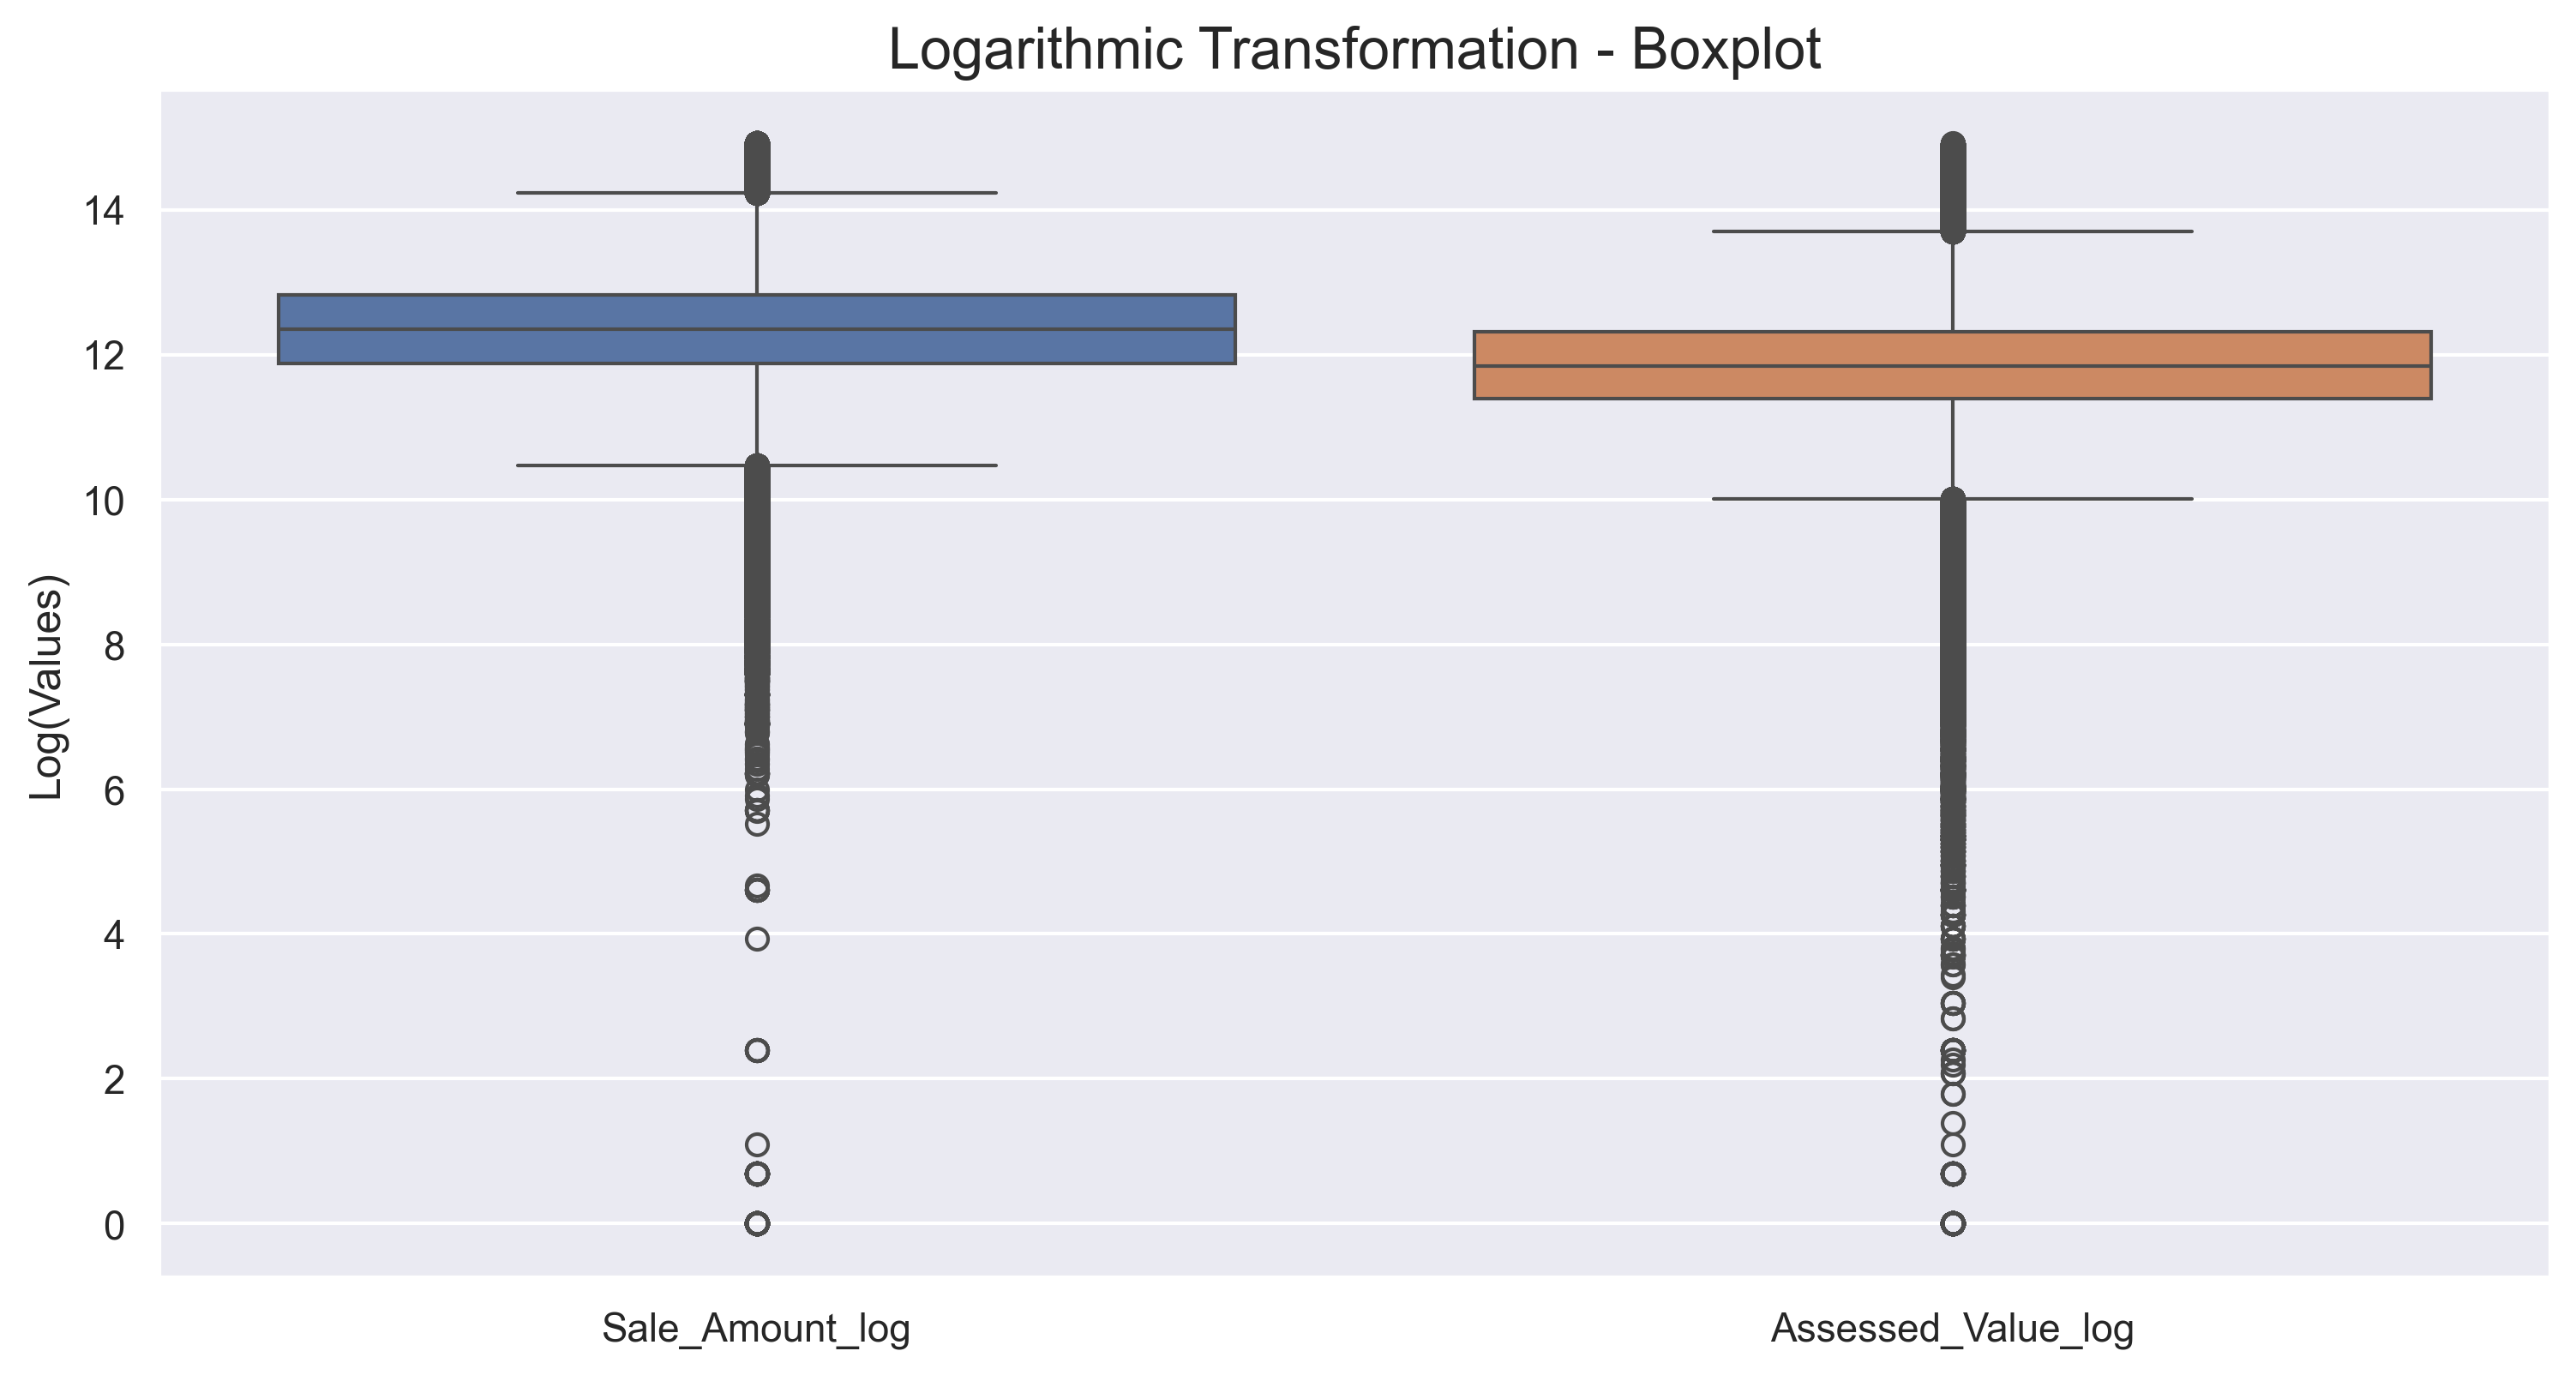

In [64]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=data[['Sale_Amount_log', 'Assessed_Value_log']])

plt.title("Logarithmic Transformation - Boxplot", fontsize=16)
plt.ylabel("Log(Values)", fontsize=12)
plt.show()


### Data Type Correction: Are any columns incorrectly typed? For instance, Non Use Code might be categorical instead of object.

##### There is no column with an incorrect data type; no adjustments are needed.

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1083606 entries, 0 to 1097626
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Serial_Number       1083606 non-null  int64         
 1   List_Year           1083606 non-null  int64         
 2   Date_Recorded       1083606 non-null  datetime64[ns]
 3   Town                1083606 non-null  object        
 4   Address             1083558 non-null  object        
 5   Assessed_Value      1083606 non-null  float64       
 6   Sale_Amount         1083606 non-null  float64       
 7   Sales_Ratio         1083606 non-null  float64       
 8   Property_Type       1083606 non-null  object        
 9   Residential_Type    1083606 non-null  object        
 10  Non_Use_Code        306445 non-null   object        
 11  Assessor_Remarks    166614 non-null   object        
 12  OPM_remarks         12889 non-null    object        
 13  Location         

### Derived Features: Should we create a new feature, such as the ratio of Assessed Value to Sale Amount, for further insights?

**There is a repetitive sale of the same properties.A new dataset was created for a more detailed analysis based on the first and last listing years of repeated addresses. New data was produced for price changes and repeat sales of real estate over time.**

In [66]:
duplicate_addresses = data[data.duplicated(subset='Address', keep=False)]
town_data = data[['Address', 'Town','Property_Type','Residential_Type']].drop_duplicates()

In [67]:
first_year_data = duplicate_addresses[duplicate_addresses['List_Year'] == duplicate_addresses.groupby('Address')['List_Year'].transform('min')]
last_year_data = duplicate_addresses[duplicate_addresses['List_Year'] == duplicate_addresses.groupby('Address')['List_Year'].transform('max')]

first_year_data = first_year_data[['Address', 'List_Year', 'Sale_Amount']].rename(columns={'List_Year': 'First_Year', 'Sale_Amount': 'First_Year_Sale_Amount'})
last_year_data = last_year_data[['Address', 'List_Year', 'Sale_Amount']].rename(columns={'List_Year': 'Last_Year', 'Sale_Amount': 'Last_Year_Sale_Amount'})

merged_data = pd.merge(first_year_data, last_year_data, on='Address', how='inner')

duplicated_adress = merged_data[merged_data['First_Year'] != merged_data['Last_Year']]



duplicated_adress.head (10)

,Address,First_Year,First_Year_Sale_Amount,Last_Year,Last_Year_Sale_Amount
2,1963 MAIN ST,2021,500000.0,2022,500000.0
3,2075 MAIN ST,2020,25000.0,2021,49900.0
4,GENERAL LYON RD,2020,20000.0,2022,70000.0
5,5 SPARROW LN,2001,302866.0,2003,400000.0
6,50 FOURTH ST,2001,50000.0,2005,169900.0
7,FEDERAL RD,2001,35000.0,2021,295000.0
8,42 PRATT RD,2001,230000.0,2017,178000.0
9,50 RIVERSIDE LANE,2020,300000.0,2021,1185000.0
10,WESTFORD RD,2001,5000.0,2021,40000.0
11,KASSON RD,2001,105000.0,2002,65000.0


In [68]:
#Adding the Town Column
merged_data = pd.merge(duplicated_adress, town_data, on='Address', how='left')

In [69]:
merged_data.head(5)

,Address,First_Year,First_Year_Sale_Amount,Last_Year,Last_Year_Sale_Amount,Town,Property_Type,Residential_Type
0,1963 MAIN ST,2021,500000.0,2022,500000.0,Bridgeport,Commercial,Not Residence
1,2075 MAIN ST,2020,25000.0,2021,49900.0,Coventry,Vacant Land,Not Residence
2,GENERAL LYON RD,2020,20000.0,2022,70000.0,Eastford,Vacant Land,Not Residence
3,5 SPARROW LN,2001,302866.0,2003,400000.0,Farmington,Residential,Condo
4,5 SPARROW LN,2001,302866.0,2003,400000.0,Farmington,Residential,Two Family


In [70]:
grouped_data = merged_data.groupby('Town').agg({
    'First_Year_Sale_Amount': 'mean',
    'Last_Year_Sale_Amount': 'mean'
}).reset_index()

The mean difference between first year listing sale amount and last year listing sale amount by town

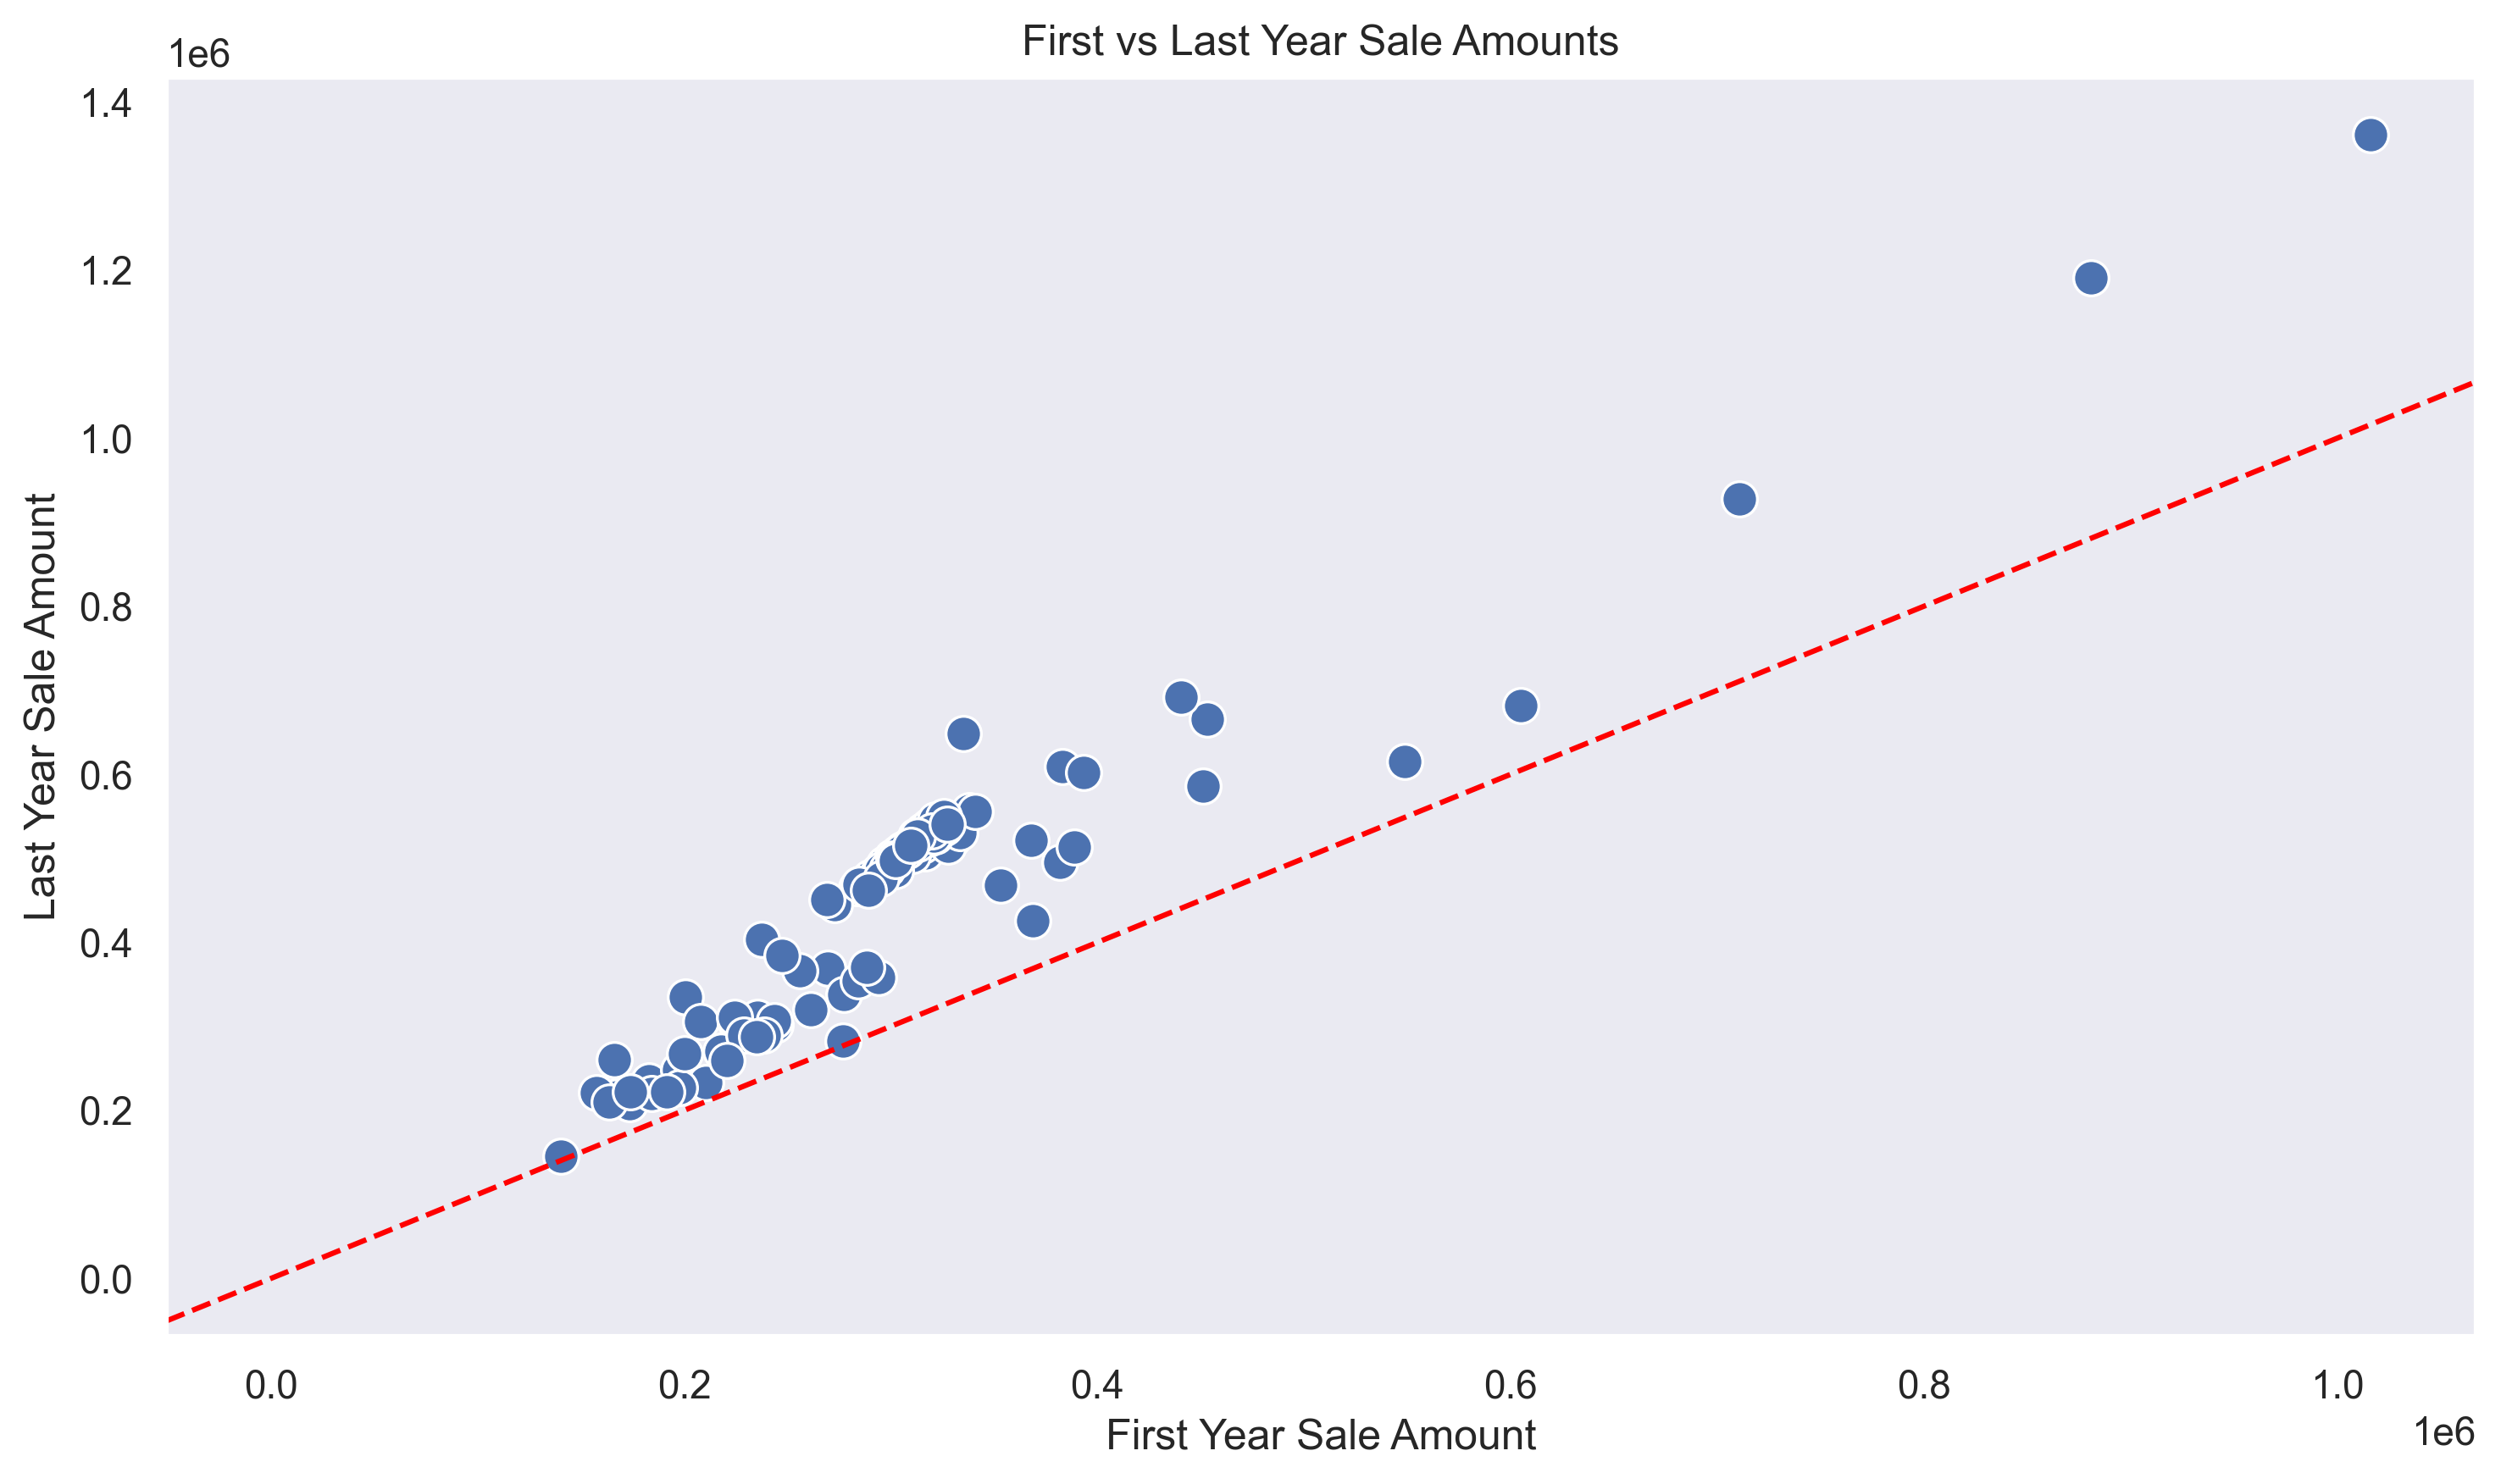

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='First_Year_Sale_Amount', y='Last_Year_Sale_Amount', data=grouped_data, palette='viridis', s=100)

plt.title('First vs Last Year Sale Amounts')
plt.xlabel('First Year Sale Amount')
plt.ylabel('Last Year Sale Amount')
plt.axline((0, 0), slope=1, color='red', linestyle='--') 
plt.grid()
plt.tight_layout()
plt.show()

In [72]:
import plotly.express as px

# Assuming 'grouped_data' is your DataFrame with columns: 'First_Year_Sale_Amount', 'Last_Year_Sale_Amount', and 'Town'
fig = px.scatter(grouped_data, 
                 x='First_Year_Sale_Amount', 
                 y='Last_Year_Sale_Amount', 
                 hover_name='Town',  # This will show the town name when you hover over the points
                 title='First vs Last Year Sale Amounts',
                 labels={'First_Year_Sale_Amount': 'First Year Sale Amount', 
                         'Last_Year_Sale_Amount': 'Last Year Sale Amount'},
                 template='plotly_dark')

# Add a diagonal line (slope = 1)
fig.add_shape(
    type='line',
    x0=0, y0=0,
    x1=max(grouped_data['First_Year_Sale_Amount'].max(), grouped_data['Last_Year_Sale_Amount'].max()),
    y1=max(grouped_data['First_Year_Sale_Amount'].max(), grouped_data['Last_Year_Sale_Amount'].max()),
    line=dict(color='red', dash='dash')
)

# Show the plot
fig.update_traces(marker=dict(size=10))  # You can adjust marker size here
fig.show()


In [73]:
grouped_data['distance'] = np.abs(grouped_data['First_Year_Sale_Amount'] - grouped_data['Last_Year_Sale_Amount'])

outlier_row = grouped_data.loc[grouped_data['distance'].idxmax()]

outlier_town = outlier_row['Town']
print(f"The town corresponding to the outlier is: {outlier_town}")
print(outlier_row)

The town corresponding to the outlier is: New Canaan
Town                          New Canaan
First_Year_Sale_Amount    1016234.792431
Last_Year_Sale_Amount     1361788.681193
distance                   345553.888761
Name: 89, dtype: object


In [74]:
grouped_data.describe().T

,count,mean,std,min,25%,50%,75%,max
First_Year_Sale_Amount,169.0,310909.008473,97335.007219,140223.412698,289283.190104,314456.240965,320767.878002,1.016235e+06
Last_Year_Sale_Amount,169.0,483797.015248,143530.632380,145813.460317,466270.329615,519098.933247,533550.489850,1.361789e+06
distance,169.0,172888.006775,66555.239987,5590.047619,136721.051672,204094.837737,212914.446835,3.455539e+05


### Filtering by Year: Should we create subsets of the data for specific years (e.g., analyzing post-2020 sales)?

In [75]:
data['Year'] = pd.to_datetime(data['Date_Recorded']).dt.year
filtered_df = data[data['Year'] >= 2020]
filtered_df.head()

,Serial_Number,List_Year,Date_Recorded,Town,Address,Assessed_Value,Sale_Amount,Sales_Ratio,Property_Type,Residential_Type,Non_Use_Code,Assessor_Remarks,OPM_remarks,Location,Latitude,Longitude,Sale_Amount_log,Assessed_Value_log,Year
0,220008,2022,2023-01-30,Andover,618 ROUTE 6,139020.0,232000.0,0.5992,Residential,Single Family,NaN,NaN,NaN,POINT (-72.343628962 41.728431984),41.737321,-72.370360,12.354497,11.842380,2023
1,2020348,2020,2021-09-13,Ansonia,230 WAKELEE AVE,150500.0,325000.0,0.4630,Commercial,Not Residence,NaN,NaN,NaN,"-73.0787468, 41.3429922",41.342992,-73.078747,12.691584,11.921725,2021
2,20002,2020,2020-10-02,Ashford,390 TURNPIKE RD,253000.0,430000.0,0.5883,Residential,Single Family,NaN,NaN,NaN,"-72.1214653, 41.8731532",41.873153,-72.121465,12.971543,12.441149,2020
3,210317,2021,2022-07-05,Avon,53 COTSWOLD WAY,329730.0,805000.0,0.4096,Residential,Single Family,NaN,NaN,NaN,POINT (-72.846365959 41.781677018),41.809821,-72.830654,13.598599,12.706032,2022
4,200212,2020,2021-03-09,Avon,5 CHESTNUT DRIVE,130400.0,179900.0,0.7248,Residential,Condo,NaN,NaN,NaN,"-72.8306541, 41.8098209",41.809821,-72.830654,12.100162,11.778370,2021


In [76]:
data['Year'] = pd.to_datetime(data['Date_Recorded']).dt.year
filtered_df2 = data[(data['Year'] >= 2010) & (data['Year'] < 2020)]
filtered_df2.head()

,Serial_Number,List_Year,Date_Recorded,Town,Address,Assessed_Value,Sale_Amount,Sales_Ratio,Property_Type,Residential_Type,Non_Use_Code,Assessor_Remarks,OPM_remarks,Location,Latitude,Longitude,Sale_Amount_log,Assessed_Value_log,Year
167746,900303,2009,2010-02-08,Bristol,BELGIAN CIR LOT 12-8,94430.0,140000.0,0.674500,Residential,Condo,NaN,NaN,NaN,"-72.9464859, 41.6735209",41.673521,-72.946486,11.849405,11.455625,2010
167747,90068,2009,2010-03-04,Derby,2 HAWTHORNE PLACE,108500.0,120000.0,0.904167,Condo,Condo,NaN,NaN,NaN,"-73.0890324, 41.3223611",41.322361,-73.089032,11.695255,11.594515,2010
167748,90245,2009,2010-07-01,Avon,15 HERITAGE DRIVE,145150.0,220400.0,0.658575,Condo,Condo,NaN,NaN,NaN,"-72.8306541, 41.8098209",41.809821,-72.830654,12.303204,11.885530,2010
167749,90009,2009,2010-05-13,Chaplin,1 HAMPTON RD,172600.0,250000.0,0.690400,Residential,Not Residence,NaN,NaN,NaN,"-72.1272989, 41.7948205",41.794821,-72.127299,12.429220,12.058738,2010
167750,900729,2009,2010-08-04,Bristol,681 BROAD ST,448490.0,700000.0,0.640700,Single Family,Four Family,NaN,NaN,NaN,"-72.9464859, 41.6735209",41.673521,-72.946486,13.458837,13.013644,2010


In [77]:
data['Year'] = pd.to_datetime(data['Date_Recorded']).dt.year
filtered_df3 = data[(data['Year'] >= 2002) & (data['Year'] < 2010)]
filtered_df3.head()

,Serial_Number,List_Year,Date_Recorded,Town,Address,Assessed_Value,Sale_Amount,Sales_Ratio,Property_Type,Residential_Type,Non_Use_Code,Assessor_Remarks,OPM_remarks,Location,Latitude,Longitude,Sale_Amount_log,Assessed_Value_log,Year
69,11238,2001,2002-08-30,Bethel,50 FOURTH ST,76450.0,50000.0,1.529000,Residential,Two Family,8,NaN,NaN,"-73.4140097, 41.3712063",41.371206,-73.414010,10.819798,11.244405,2002
70,10035,2001,2002-06-28,Chaplin,FEDERAL RD,19000.0,35000.0,0.542857,Residential,Condo,NaN,NaN,NaN,"-72.1272989, 41.7948205",41.794821,-72.127299,10.463132,9.852247,2002
71,10115,2001,2002-02-01,Clinton,42 PRATT RD,121900.0,230000.0,0.530000,Residential,Condo,NaN,NaN,NaN,"-72.5275904, 41.2787104",41.278710,-72.527590,12.345839,11.710965,2002
80,10041,2001,2002-07-17,Eastford,WESTFORD RD,180.0,5000.0,0.036000,Residential,Condo,28,NaN,NaN,"-72.0799095, 41.902068",41.902068,-72.079909,8.517393,5.198497,2002
96,11665,2001,2002-07-30,Danbury,3 MORGAN AVE,94600.0,175000.0,0.540571,Residential,Condo,NaN,NaN,NaN,"-73.4540111, 41.394817",41.394817,-73.454011,12.072547,11.457423,2002


### Handling Sparse Columns: Columns like OPM Remarks and Assessor Remarks are mostly empty. Should they be dropped?

#### The columns 'OPM Remarks' and 'Assessor Remarks' have been removed due to the high number of missing values and their lack of contribution to the analysis.

In [78]:
data = data.drop(columns=['OPM_remarks', 'Assessor_Remarks'])

In [79]:
data.columns

Index(['Serial_Number', 'List_Year', 'Date_Recorded', 'Town', 'Address',
       'Assessed_Value', 'Sale_Amount', 'Sales_Ratio', 'Property_Type',
       'Residential_Type', 'Non_Use_Code', 'Location', 'Latitude', 'Longitude',
       'Sale_Amount_log', 'Assessed_Value_log', 'Year'],
      dtype='object')

# 10 Data Visualization Questions

### What is the distribution of Sale Amount and how does it vary across different Property Types?

In [80]:
df.Property_Type.unique()

array(['Residential', 'Commercial', 'Vacant Land', 'Apartments',
       'Industrial', 'Single Family', 'Public Utility', 'Condo',
       'Two Family', 'Three Family', 'Four Family'], dtype=object)

In [81]:
df2 = data.copy()

In [82]:
df2['Property_Type'] = df['Property_Type'].replace({
    'Single Family': 'Residential',
    'Two Family': 'Residential',
    'Three Family': 'Residential',
    'Four Family': 'Residential',
    'Condo': 'Residential'
})

In [83]:
df2.Property_Type.unique()

array(['Residential', 'Commercial', 'Vacant Land', 'Apartments',
       'Industrial', 'Public Utility'], dtype=object)

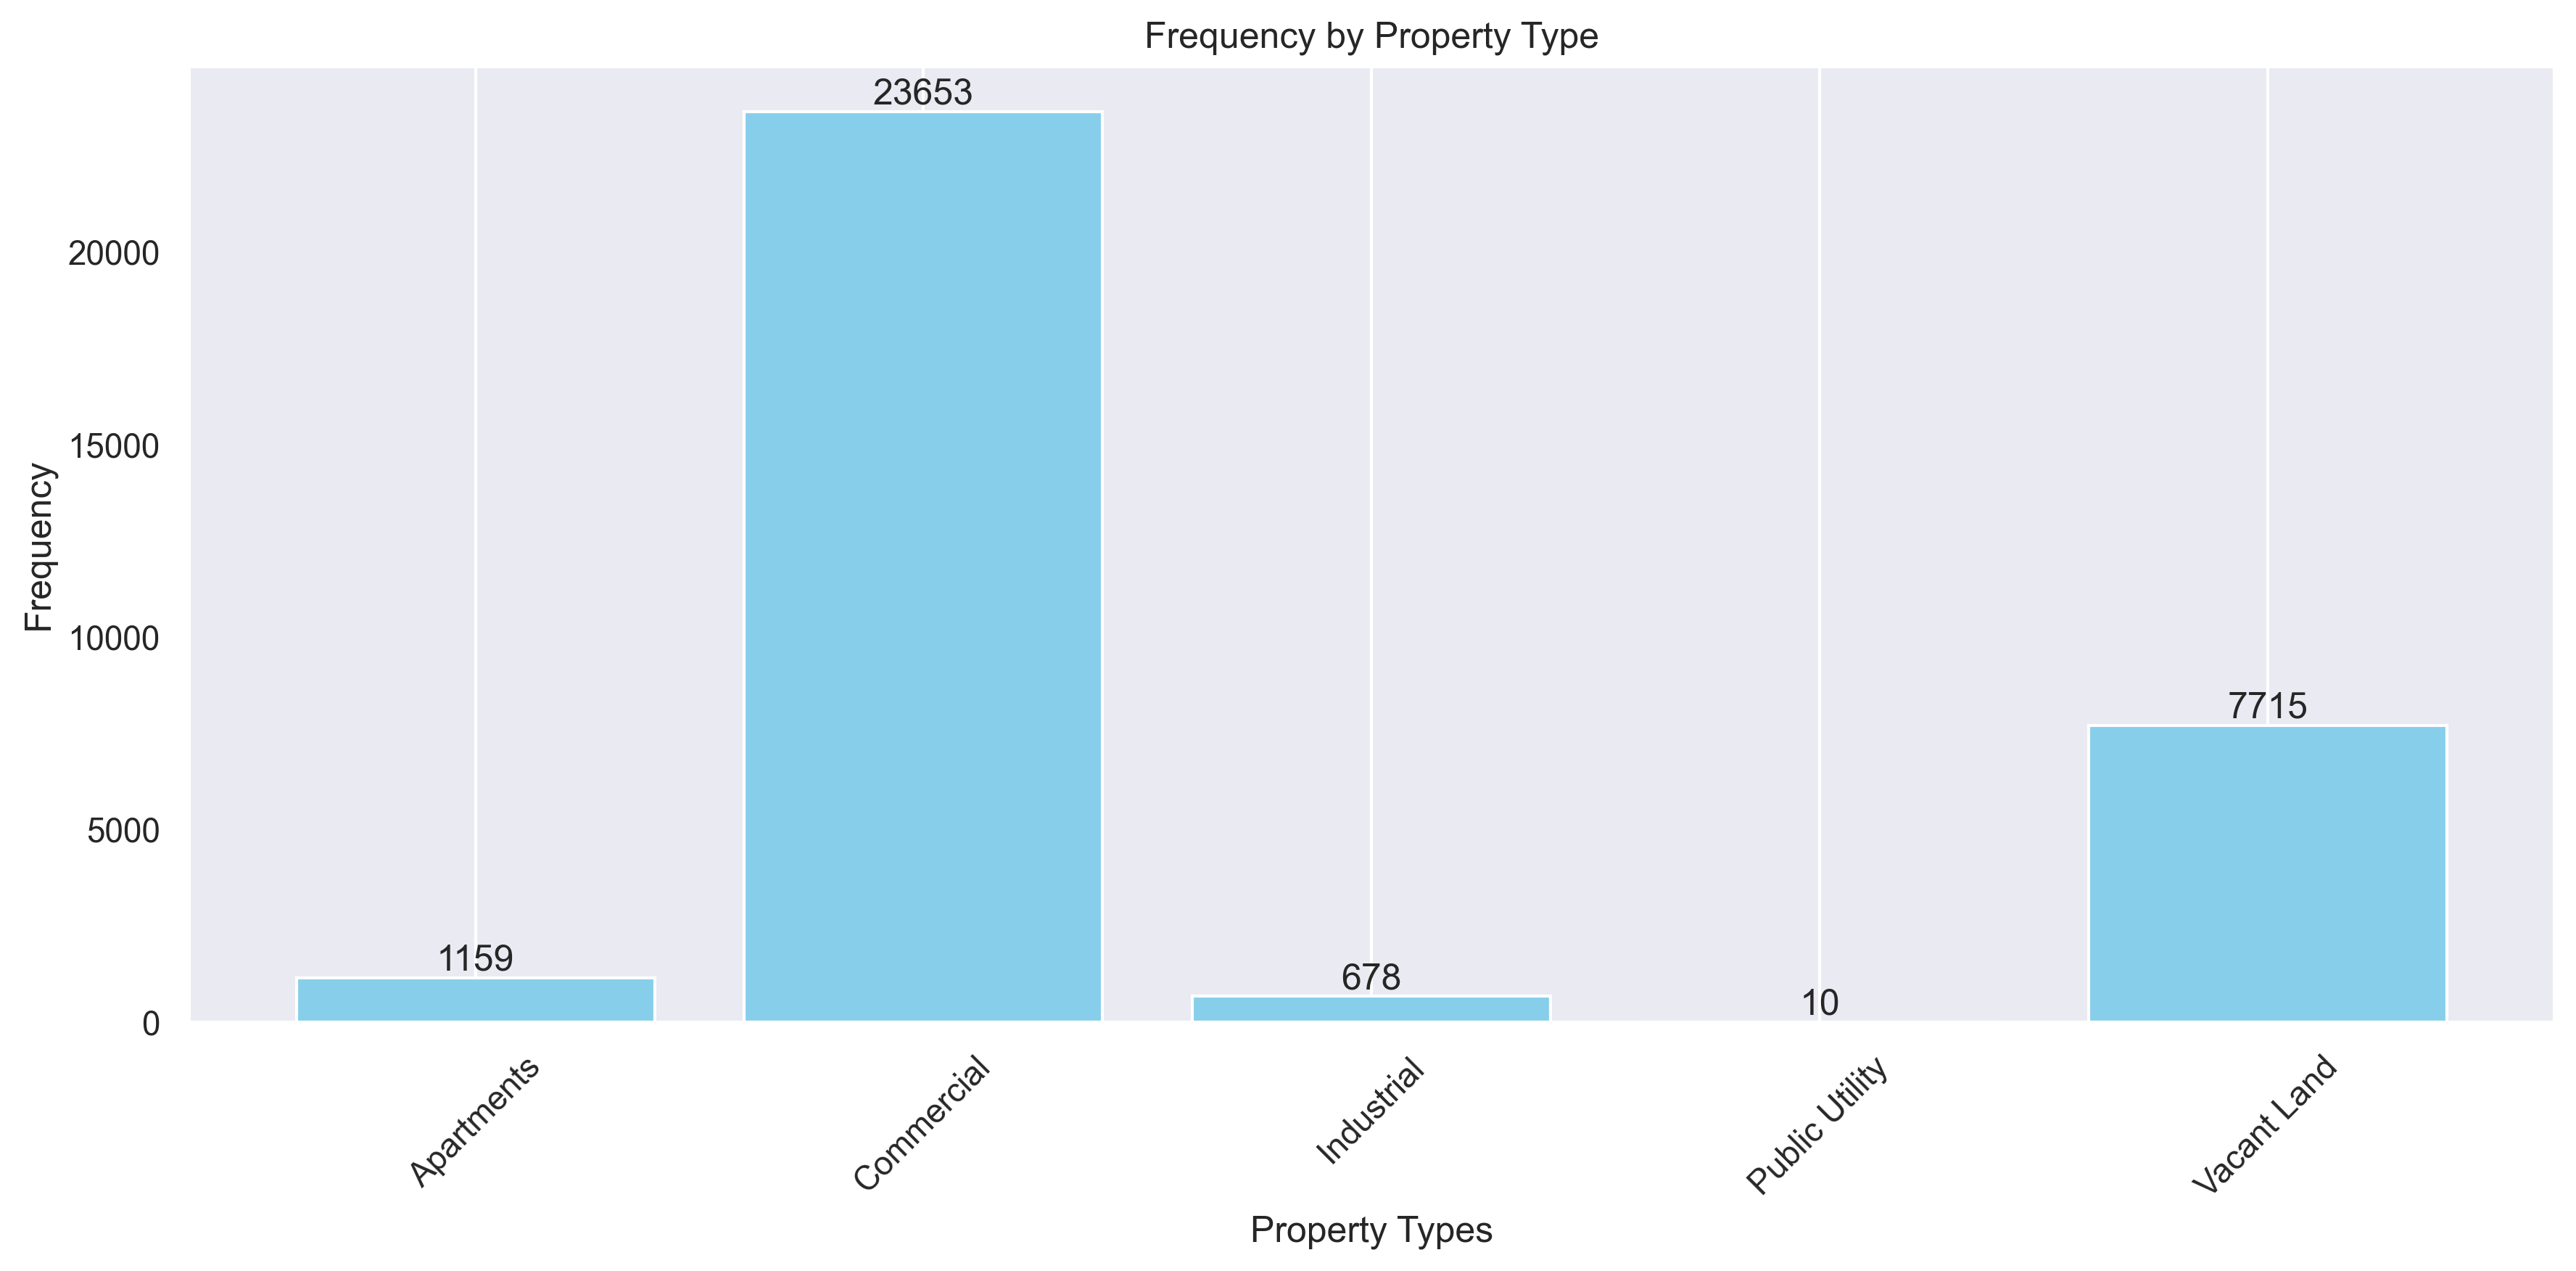

In [84]:
grouped_data = df2[df2['Property_Type'] != 'Residential'].groupby('Property_Type').count().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(grouped_data['Property_Type'], grouped_data['Sale_Amount'], color='skyblue')

for index, value in enumerate(grouped_data['Sale_Amount']):
    plt.text(index, value, str(value), ha='center', va='bottom')


plt.title('Frequency by Property Type')
plt.xlabel('Property Types')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  
plt.grid(axis='y')

plt.tight_layout()  
plt.show()

**Residential is a outlier for Property type so it was removed from the graph for better understanding of other property types' distributions...**

**This graph was created based on the remaining property types. According to the graph, the highest sales frequency is for the commercial type.**

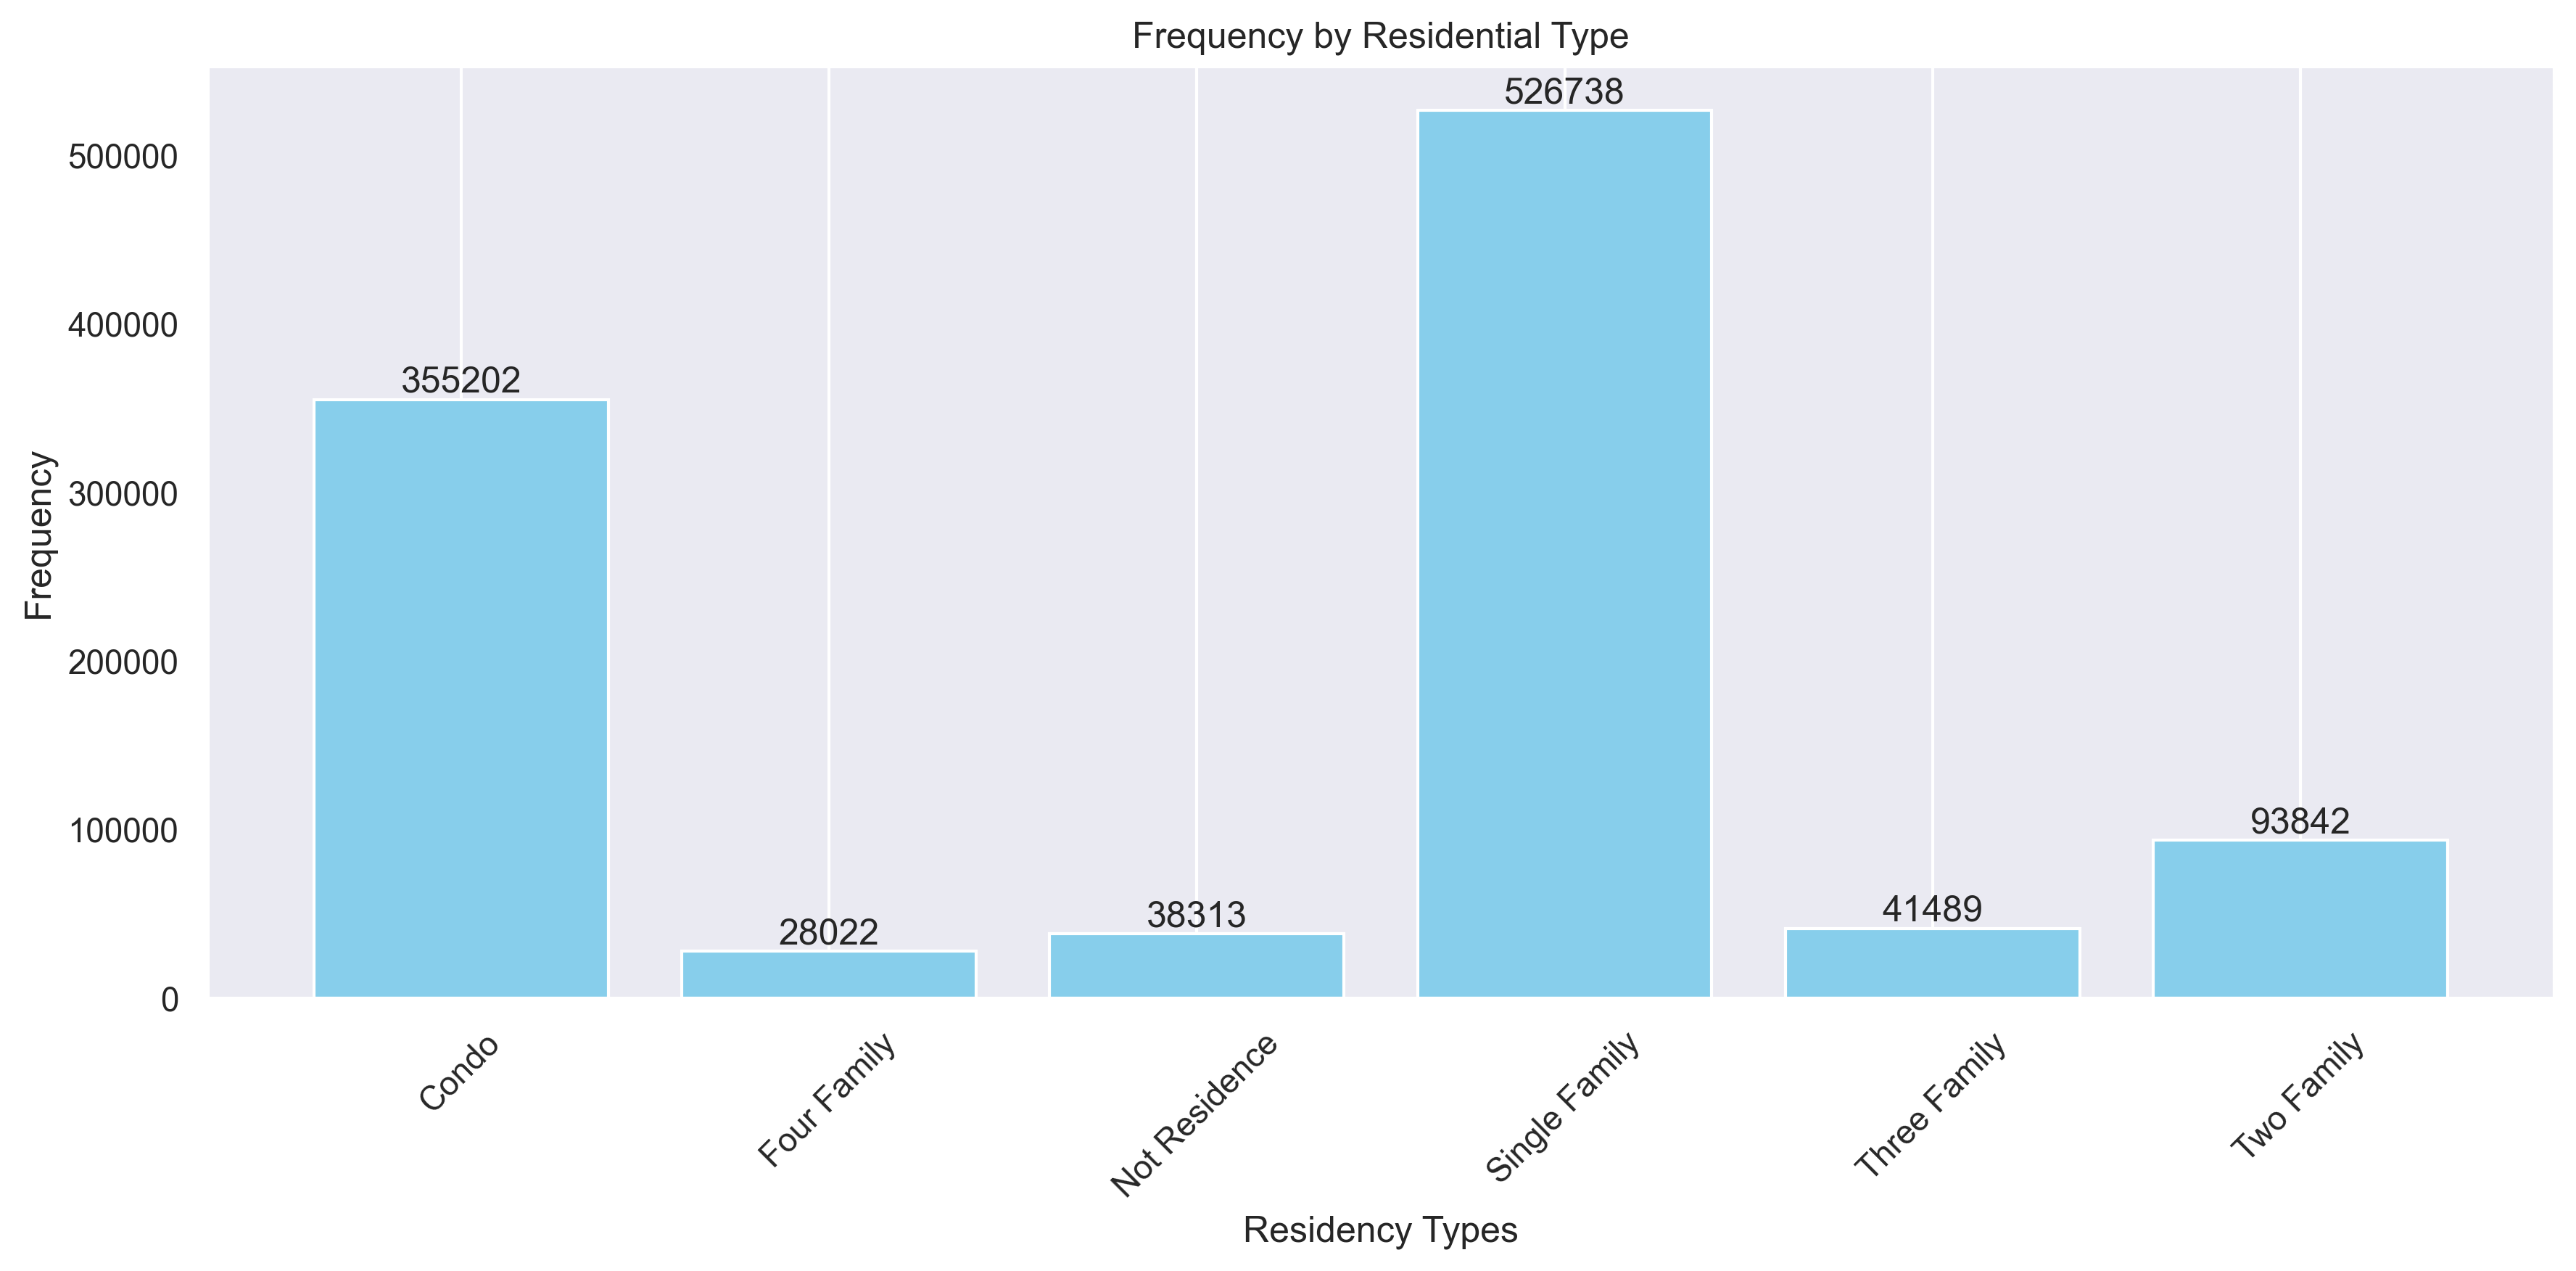

In [85]:
grouped_data = df2.groupby('Residential_Type').count().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(grouped_data['Residential_Type'], grouped_data['Sale_Amount'], color='skyblue')

for index, value in enumerate(grouped_data['Sale_Amount']):
    plt.text(index, value, str(value), ha='center', va='bottom')


plt.title('Frequency by Residential Type')
plt.xlabel('Residency Types')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  
plt.grid(axis='y')

plt.tight_layout()  
plt.show()

**Since the Residential Type data is highly dominant, we have analyzed this type separately.**

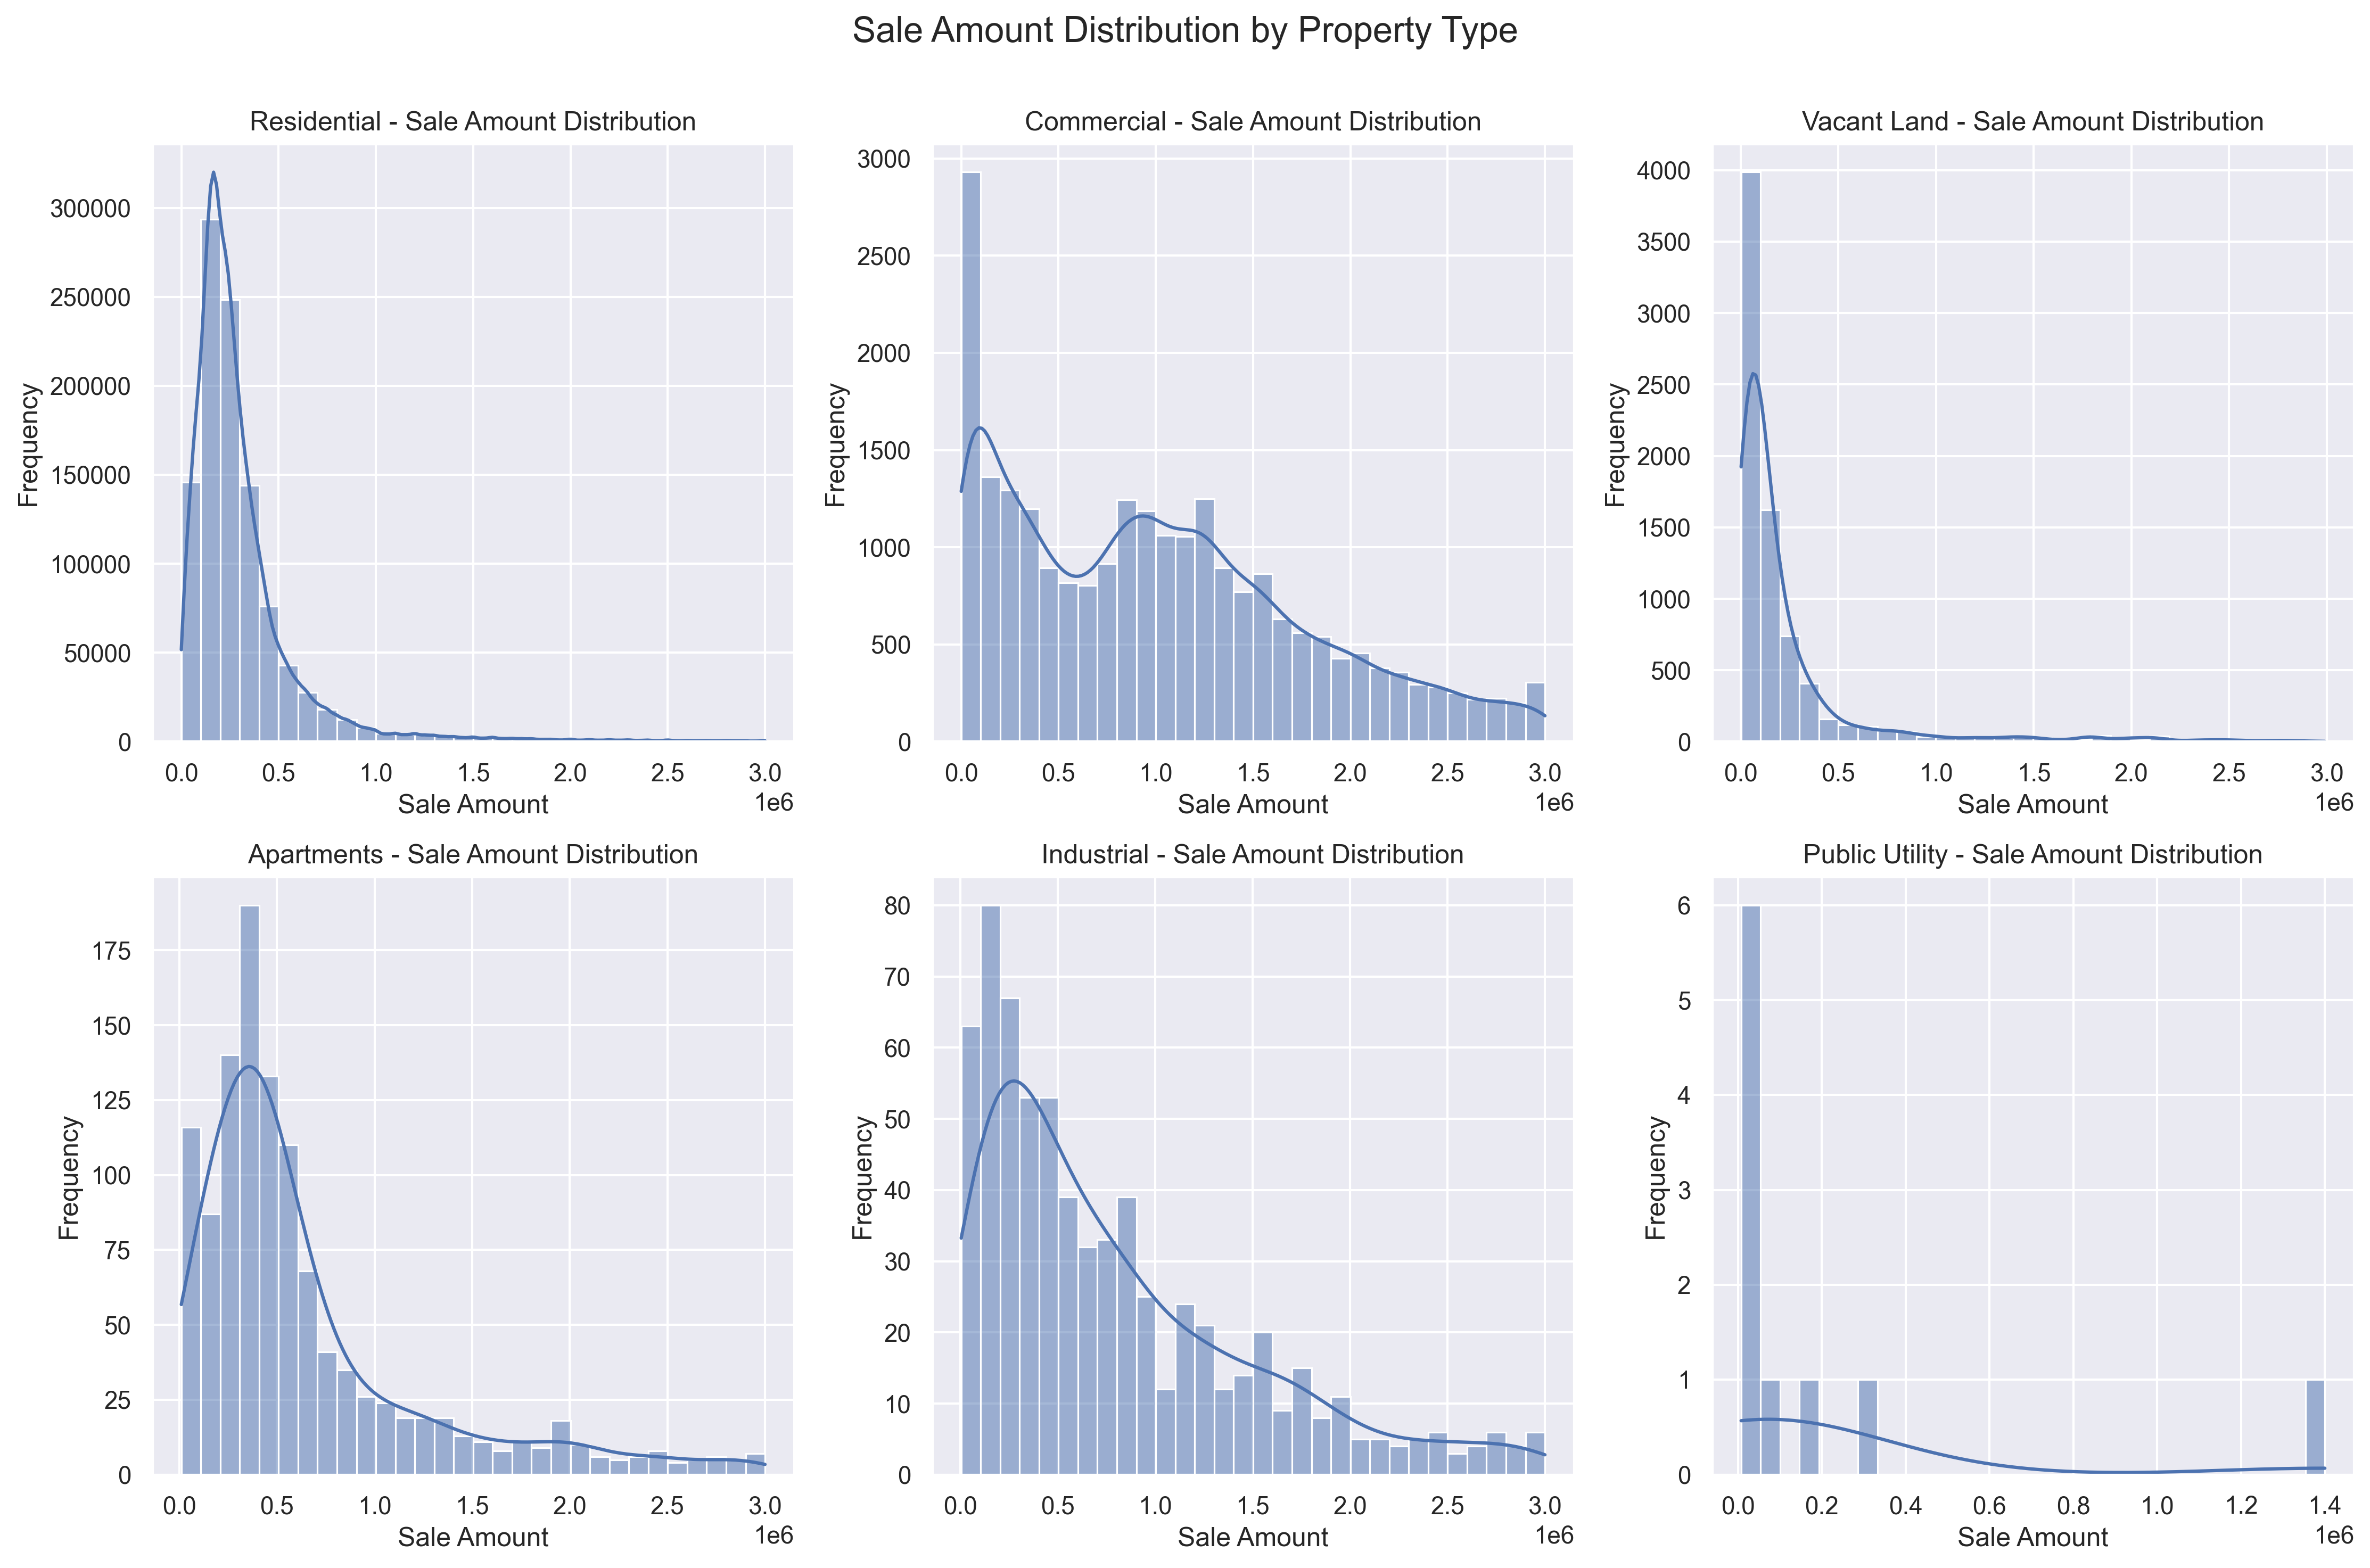

In [86]:
property_types = df2['Property_Type'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) 

axes = axes.flatten()


for i, property_type in enumerate(property_types):
   
    property_data = df2[df2['Property_Type'] == property_type]['Sale_Amount']
    
    
    sns.histplot(property_data, kde=True, bins=30, ax=axes[i])
    
   
    axes[i].set_title(f'{property_type} - Sale Amount Distribution')
    axes[i].set_xlabel('Sale Amount')
    axes[i].set_ylabel('Frequency')


plt.suptitle('Sale Amount Distribution by Property Type', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  

plt.show()

### Can we visualize the trend of total Sale Amount over the years (List Year)?

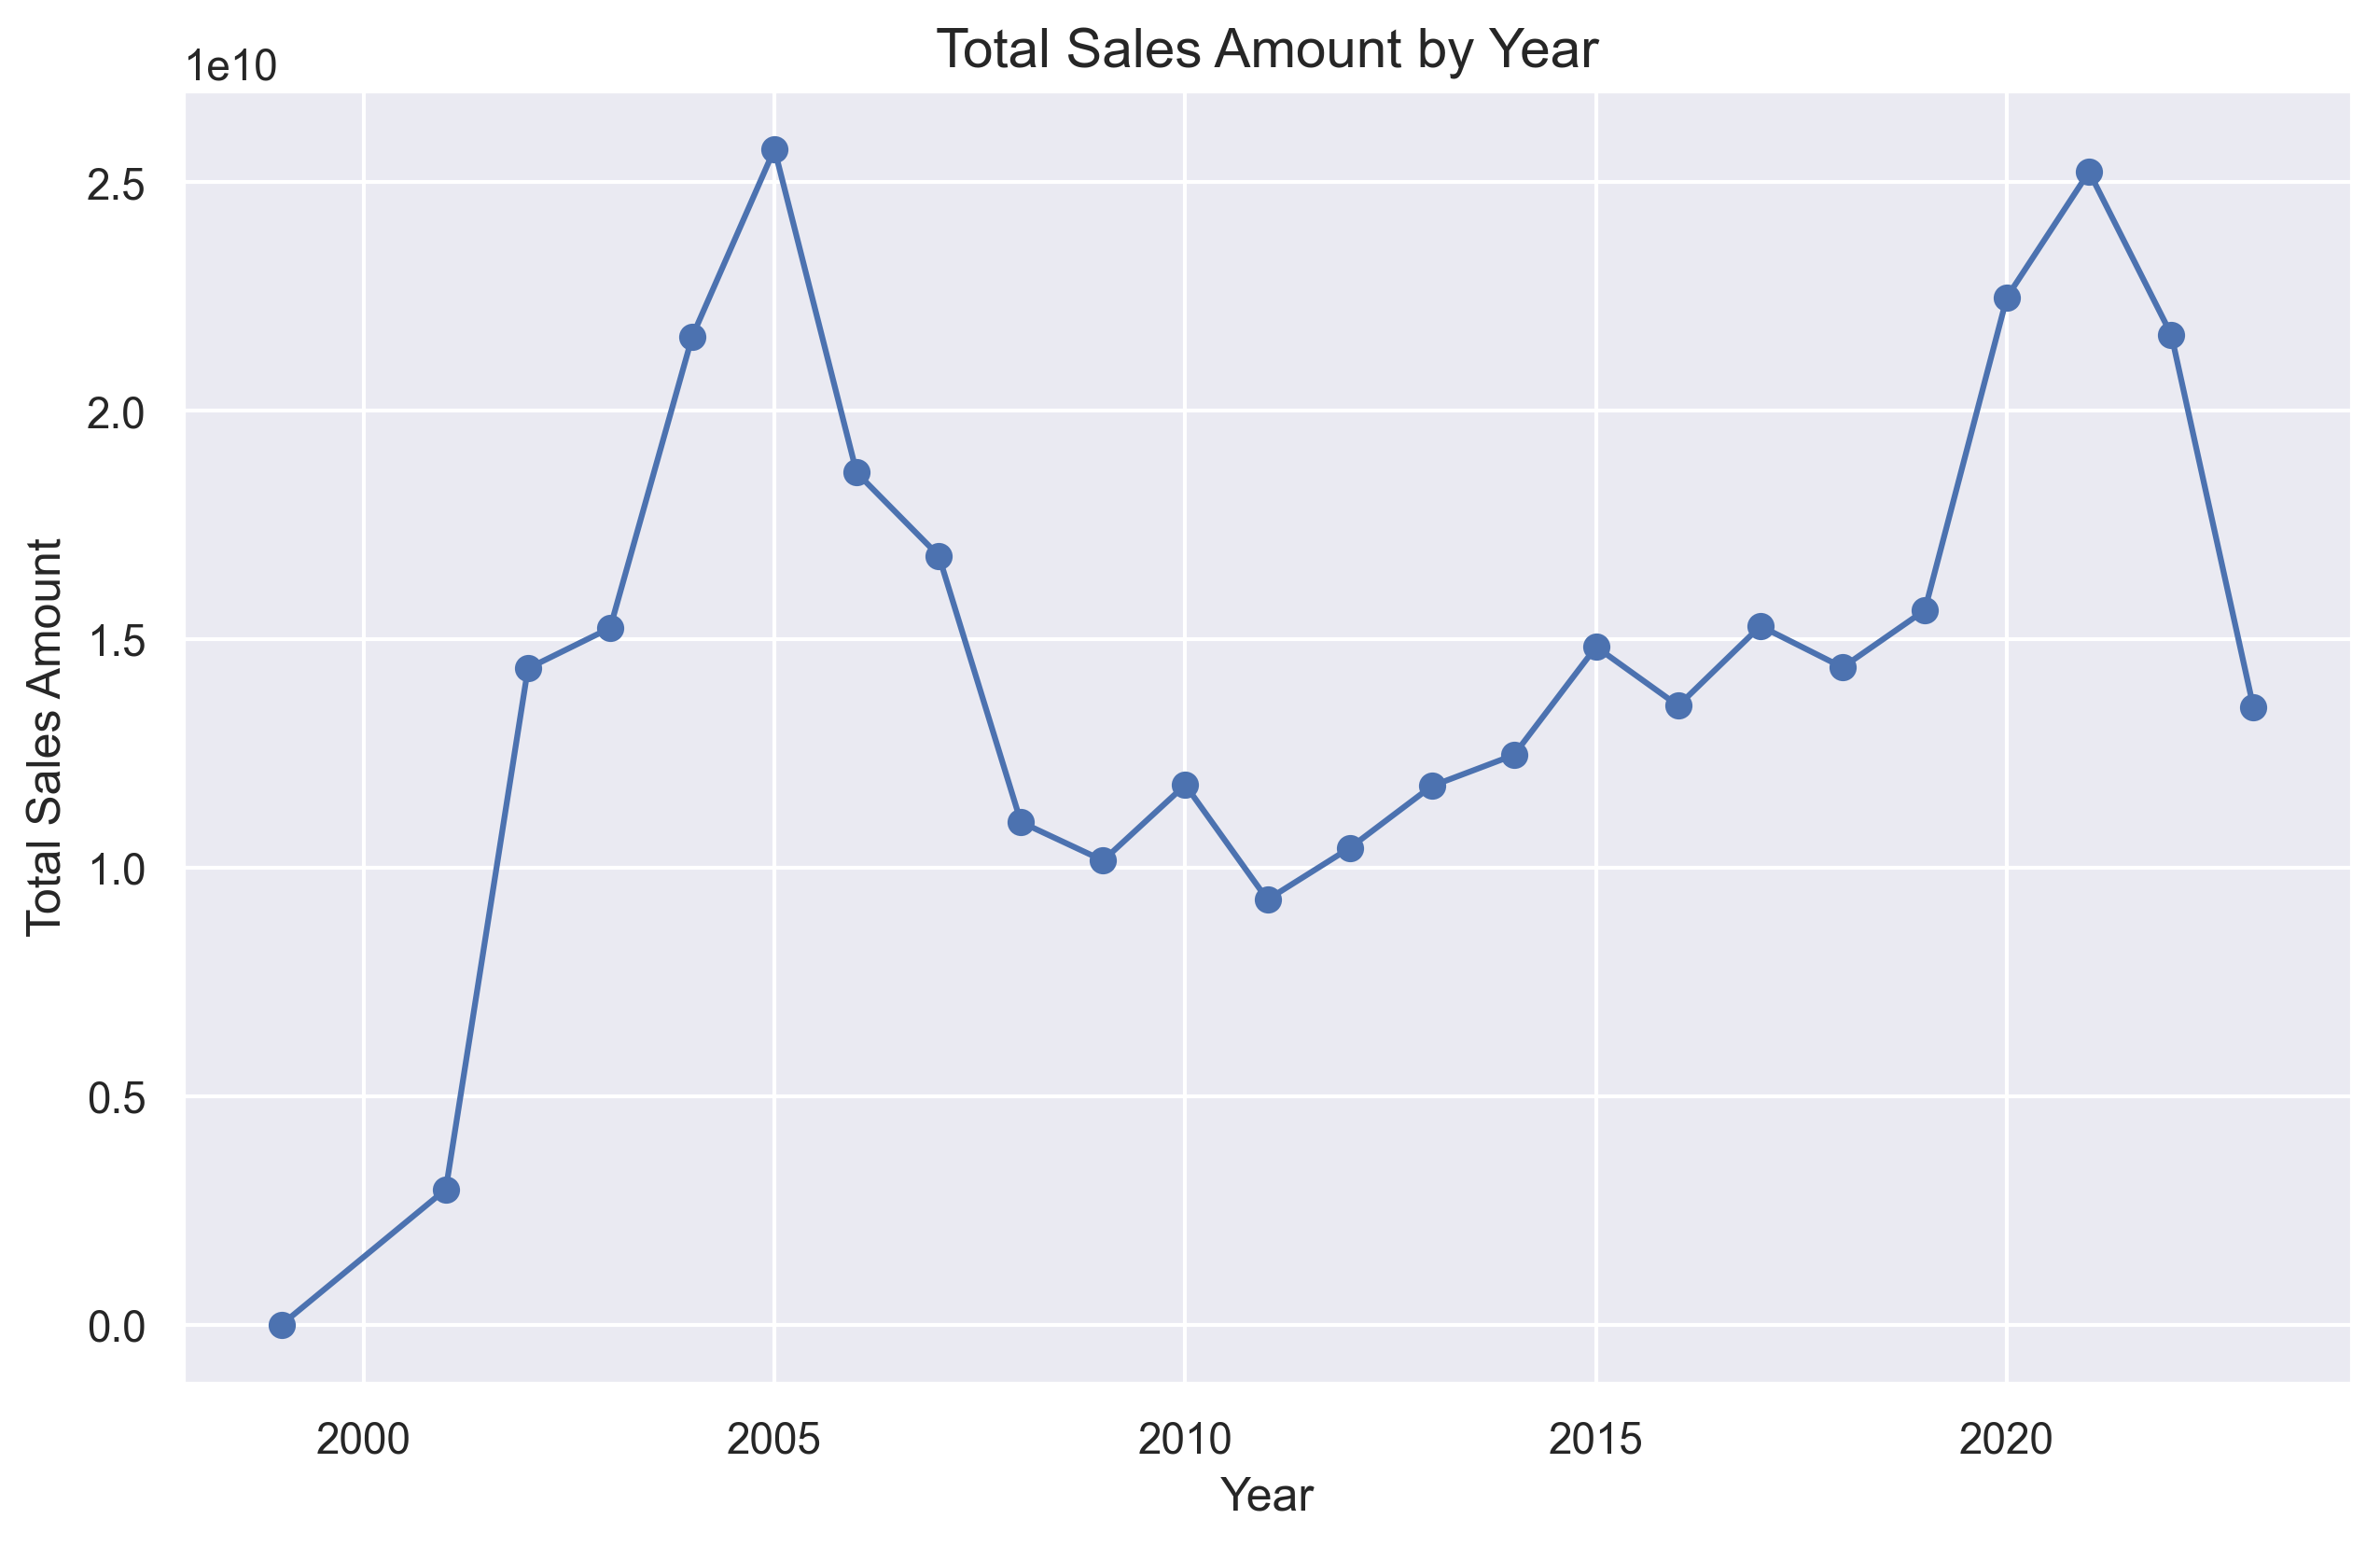

In [87]:
data_grouped = data.groupby('Year')['Sale_Amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(data_grouped['Year'], data_grouped['Sale_Amount'], marker='o', linestyle='-', color='b')

plt.title('Total Sales Amount by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)

plt.grid(True)
plt.show()

**This graph shows the change in total sales over the years.**

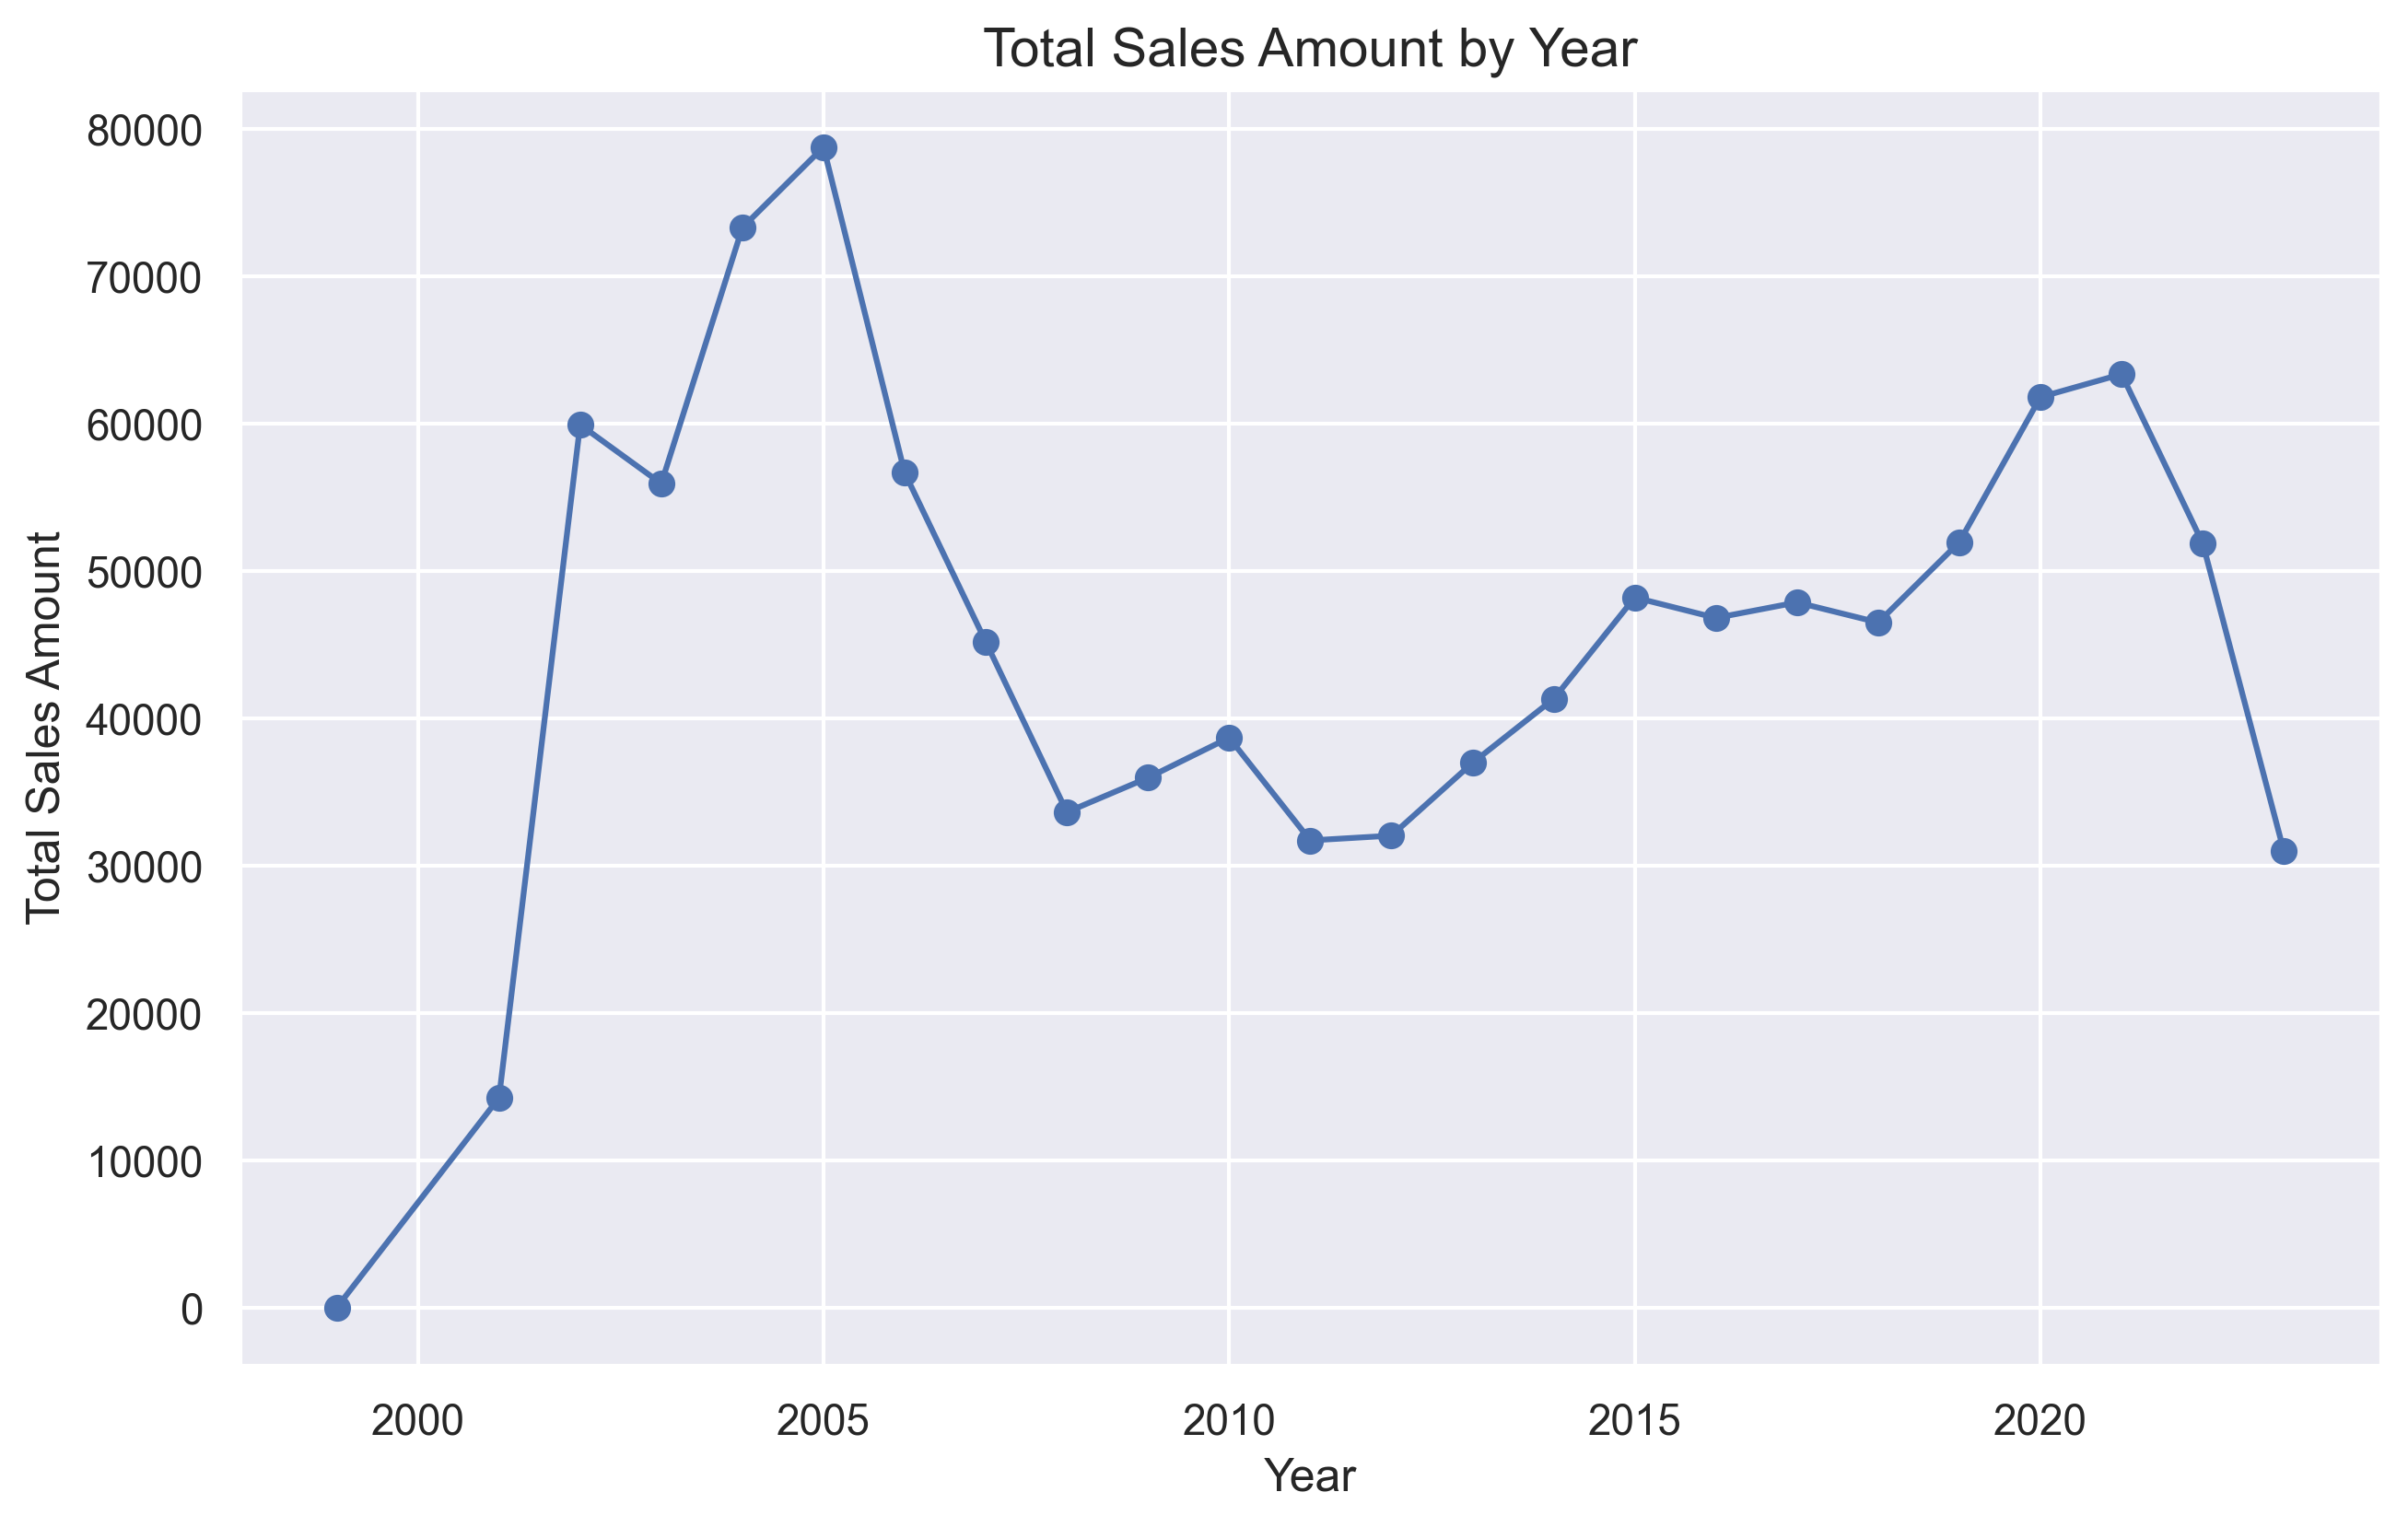

In [88]:
data_grouped = data.groupby('Year')['Sale_Amount'].count().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(data_grouped['Year'], data_grouped['Sale_Amount'], marker='o', linestyle='-', color='b')

plt.title('Total Sales Amount by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)

plt.grid(True)
plt.show()

**Looking at the graph above, the impact of societal factors (such as economic crises, pandemics, etc.) on property values is clearly evident. These external factors have caused fluctuations in the market, leading to significant changes in property values over time. The graph illustrates how these events have shaped the real estate market, influencing both supply and demand dynamics.**

### How do Assessed Value and Sale Amount correlate, and can this be visualized as a scatter plot?

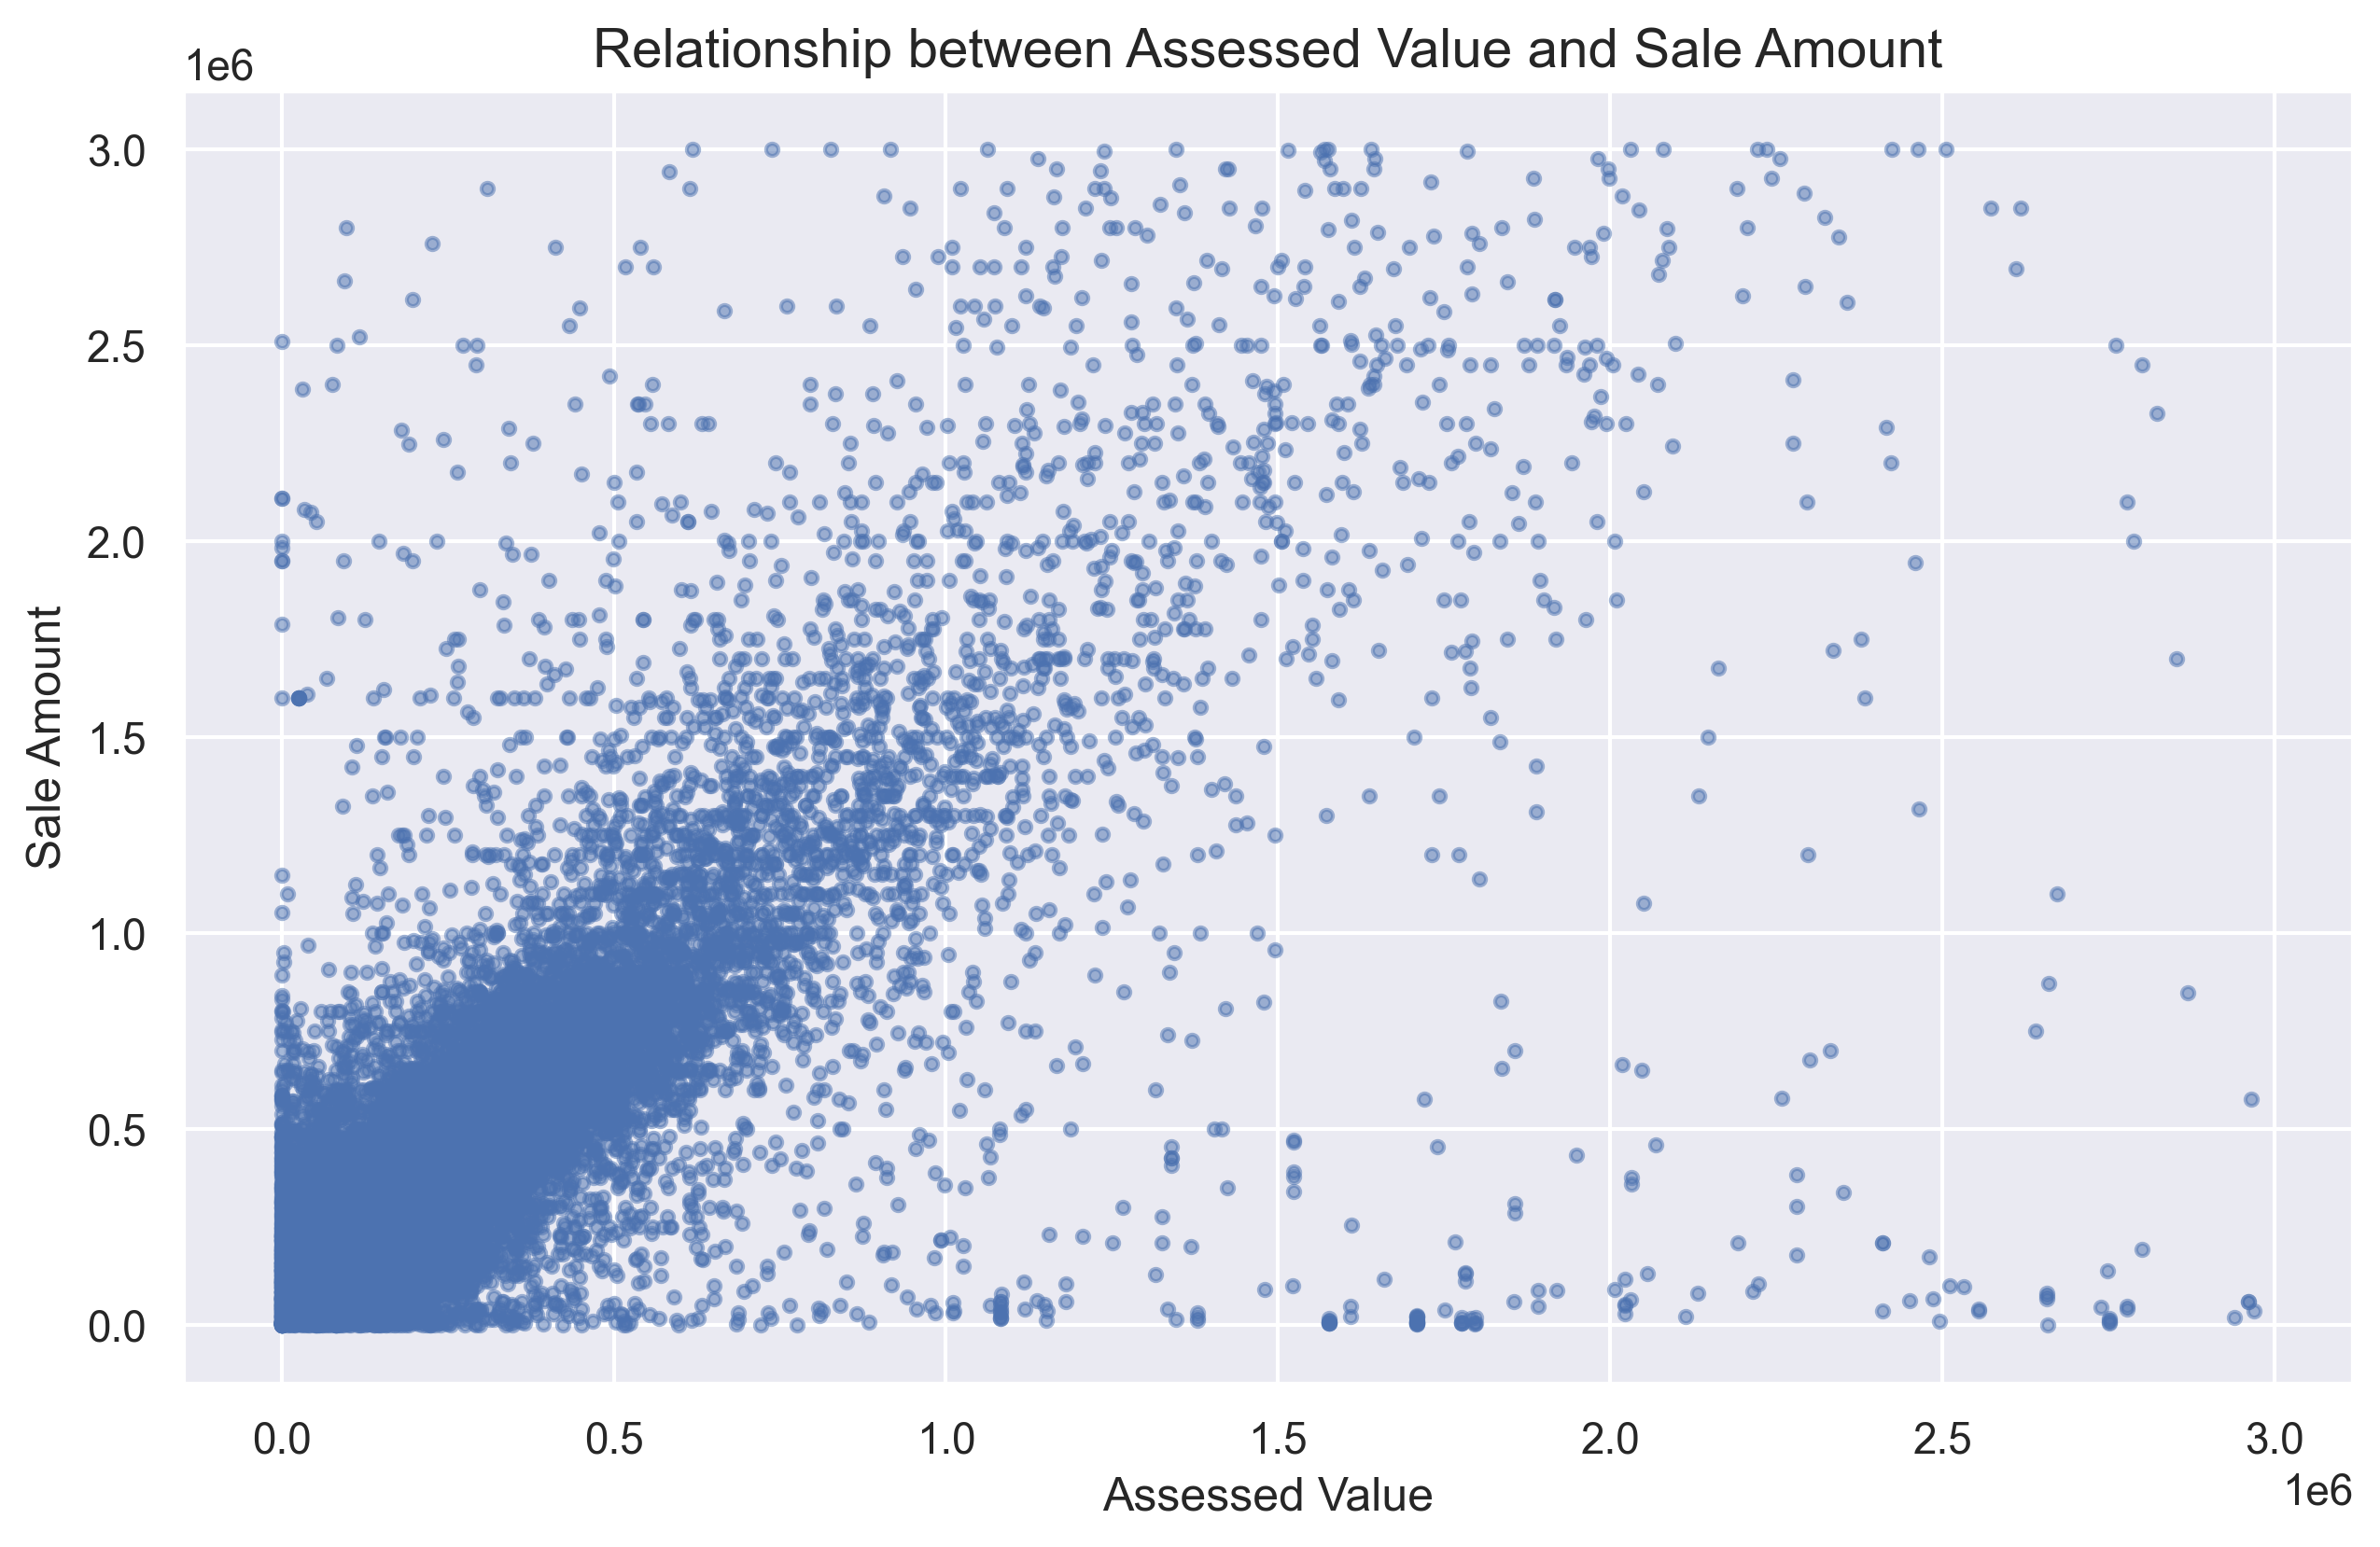

In [89]:
np.random.seed(42)

plt.figure(figsize=(10, 6))
plt.scatter(x='Assessed_Value', y='Sale_Amount', data=data.sample(50000, random_state=42), alpha=0.5, color='b', s=10)

plt.title('Relationship between Assessed Value and Sale Amount', fontsize=14)
plt.xlabel('Assessed Value', fontsize=12)
plt.ylabel('Sale Amount', fontsize=12)

plt.grid(True)
plt.show()

**The scatter plot above visualizes the relationship between Sale Amount and Assessed Values for a random sample of 50,000 observations from the dataset. As seen in the graph, a noticeable correlation between the two columns is evident. Due to the large size of the dataset, we used a random sample of 50,000 records for this analysis.**

### Are there significant differences in the average Sale Amount across different towns?

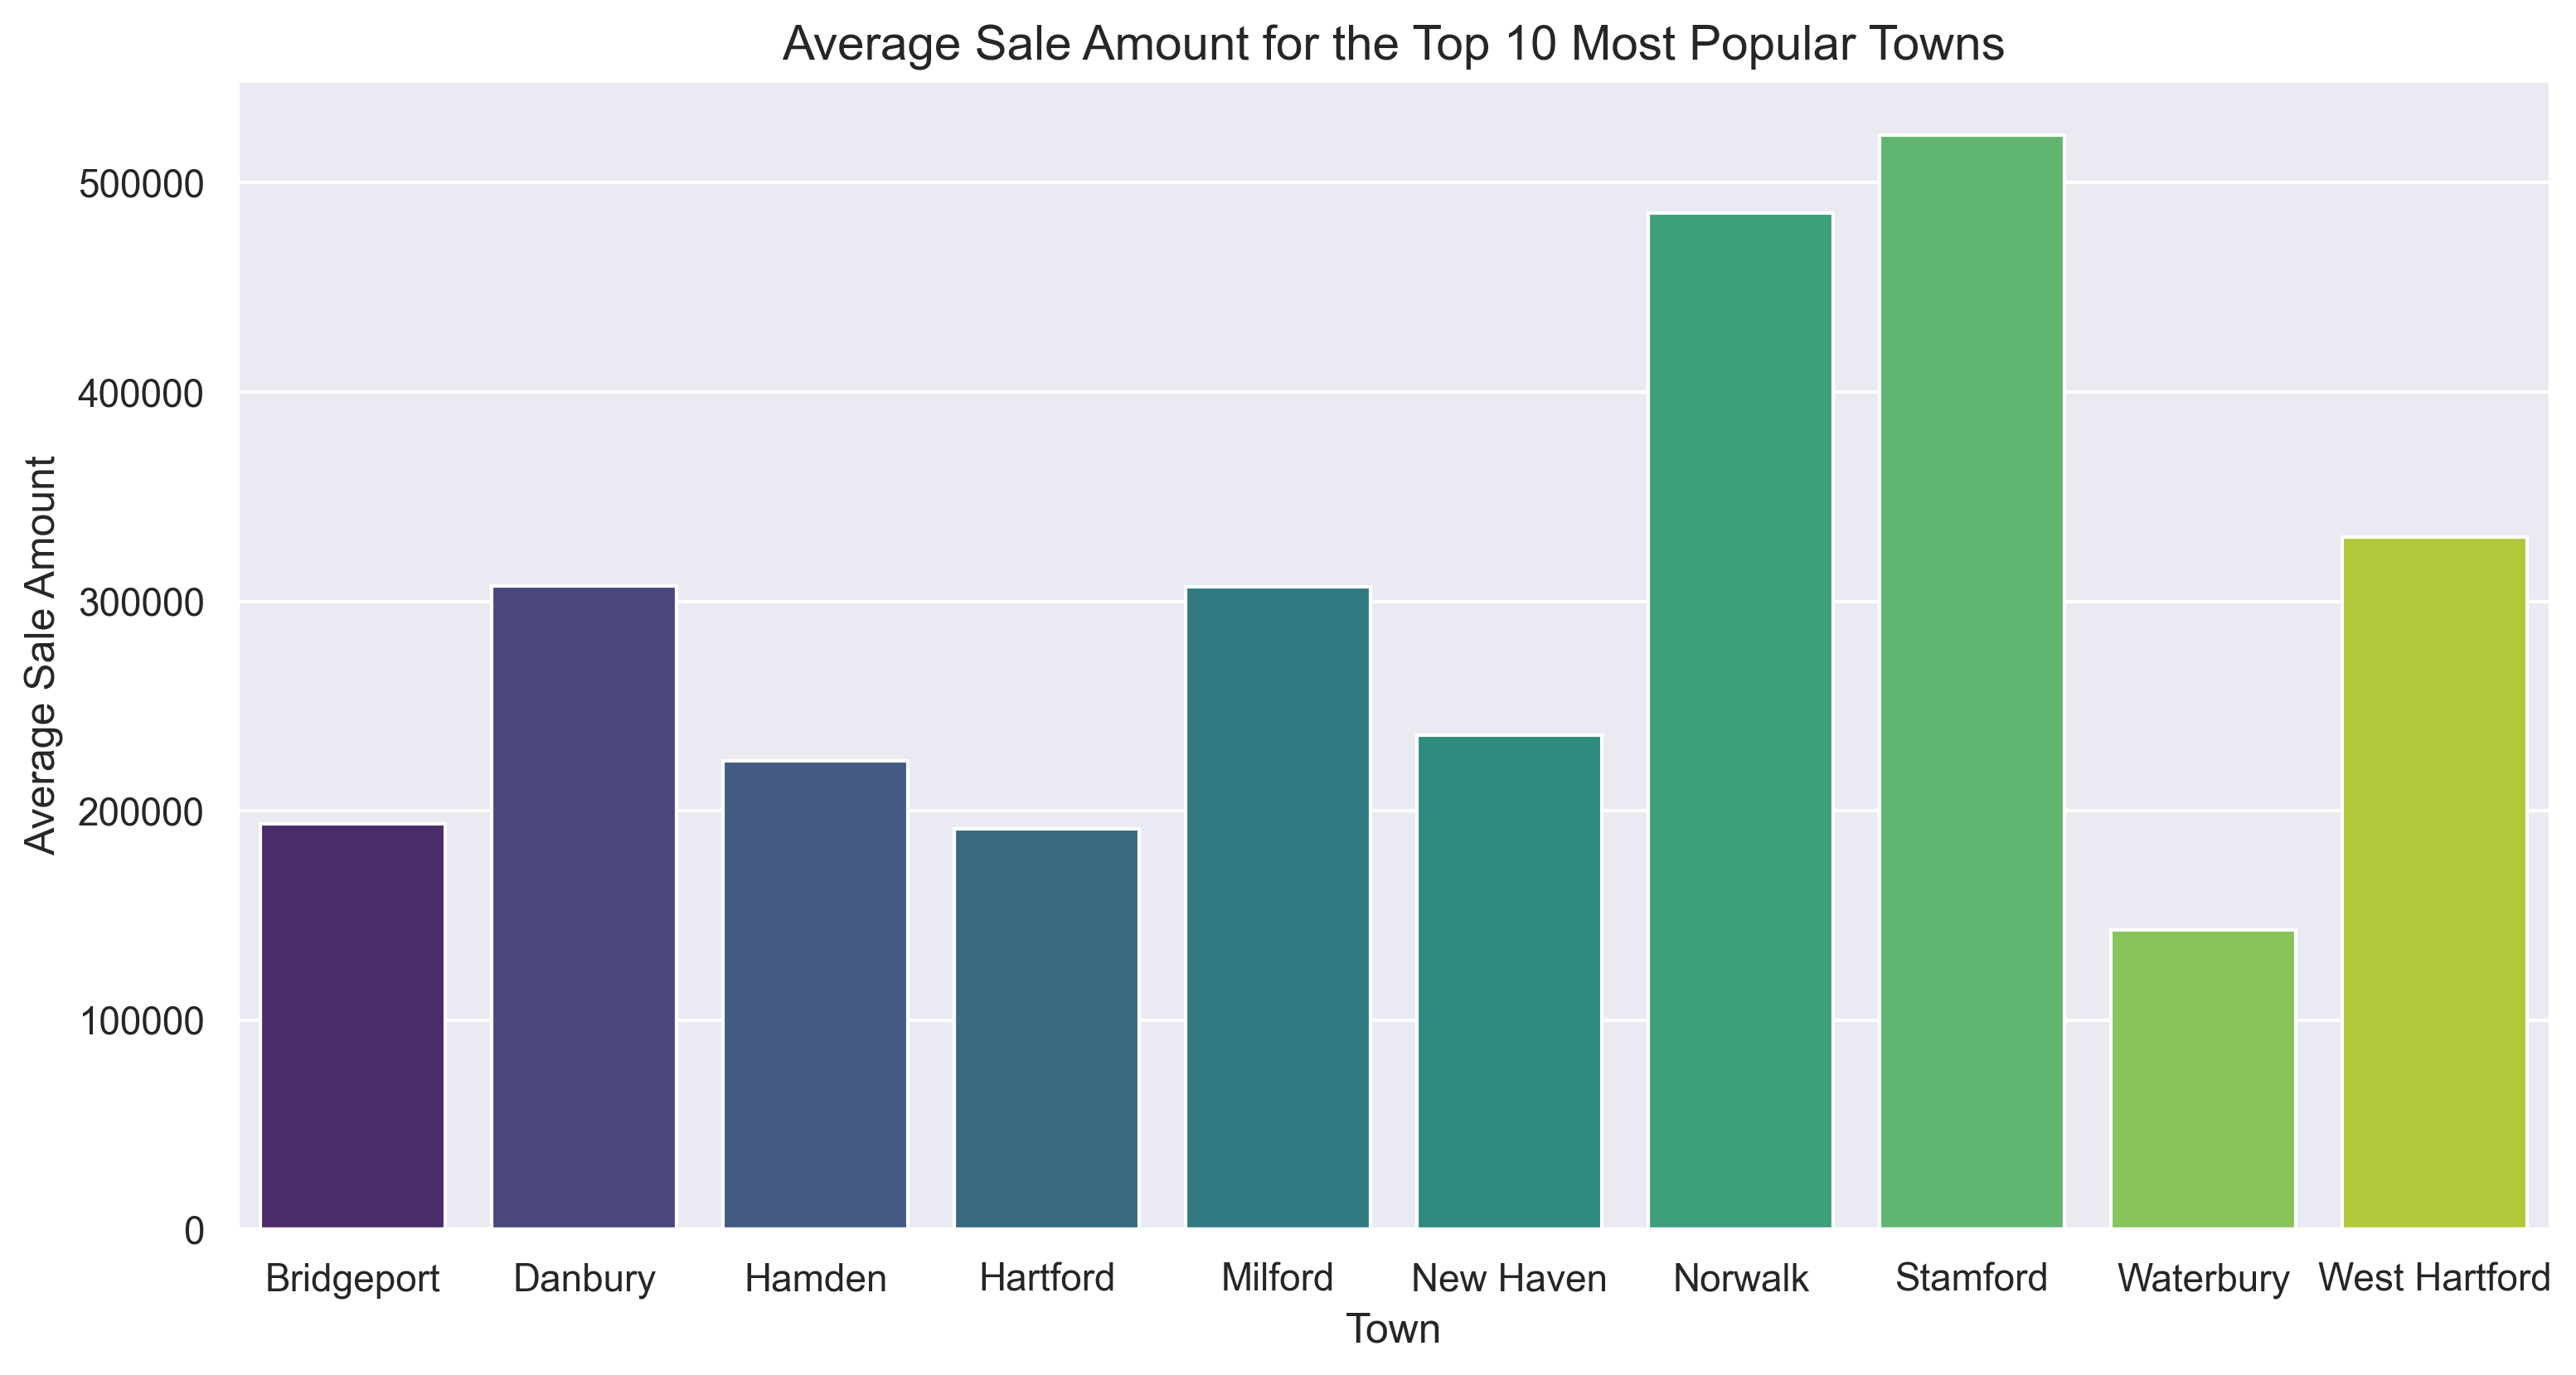

In [90]:
town_avg_sale = data.groupby('Town')['Sale_Amount'].mean().reset_index()

town_counts = data['Town'].value_counts().head(10).index
top_towns = town_avg_sale[town_avg_sale['Town'].isin(town_counts)]

plt.figure(figsize=(12, 6))
sns.barplot(y='Sale_Amount', x='Town', data=top_towns, palette='viridis')

plt.title('Average Sale Amount for the Top 10 Most Popular Towns', fontsize=14)
plt.xlabel('Town', fontsize=12)
plt.ylabel('Average Sale Amount', fontsize=12)

plt.show()

**This graph shows the average sale prices in the top 10 most preferred towns.**

### Can we create a heatmap to show correlations between numeric variables like Sales Ratio, Assessed Value, and Sale Amount?

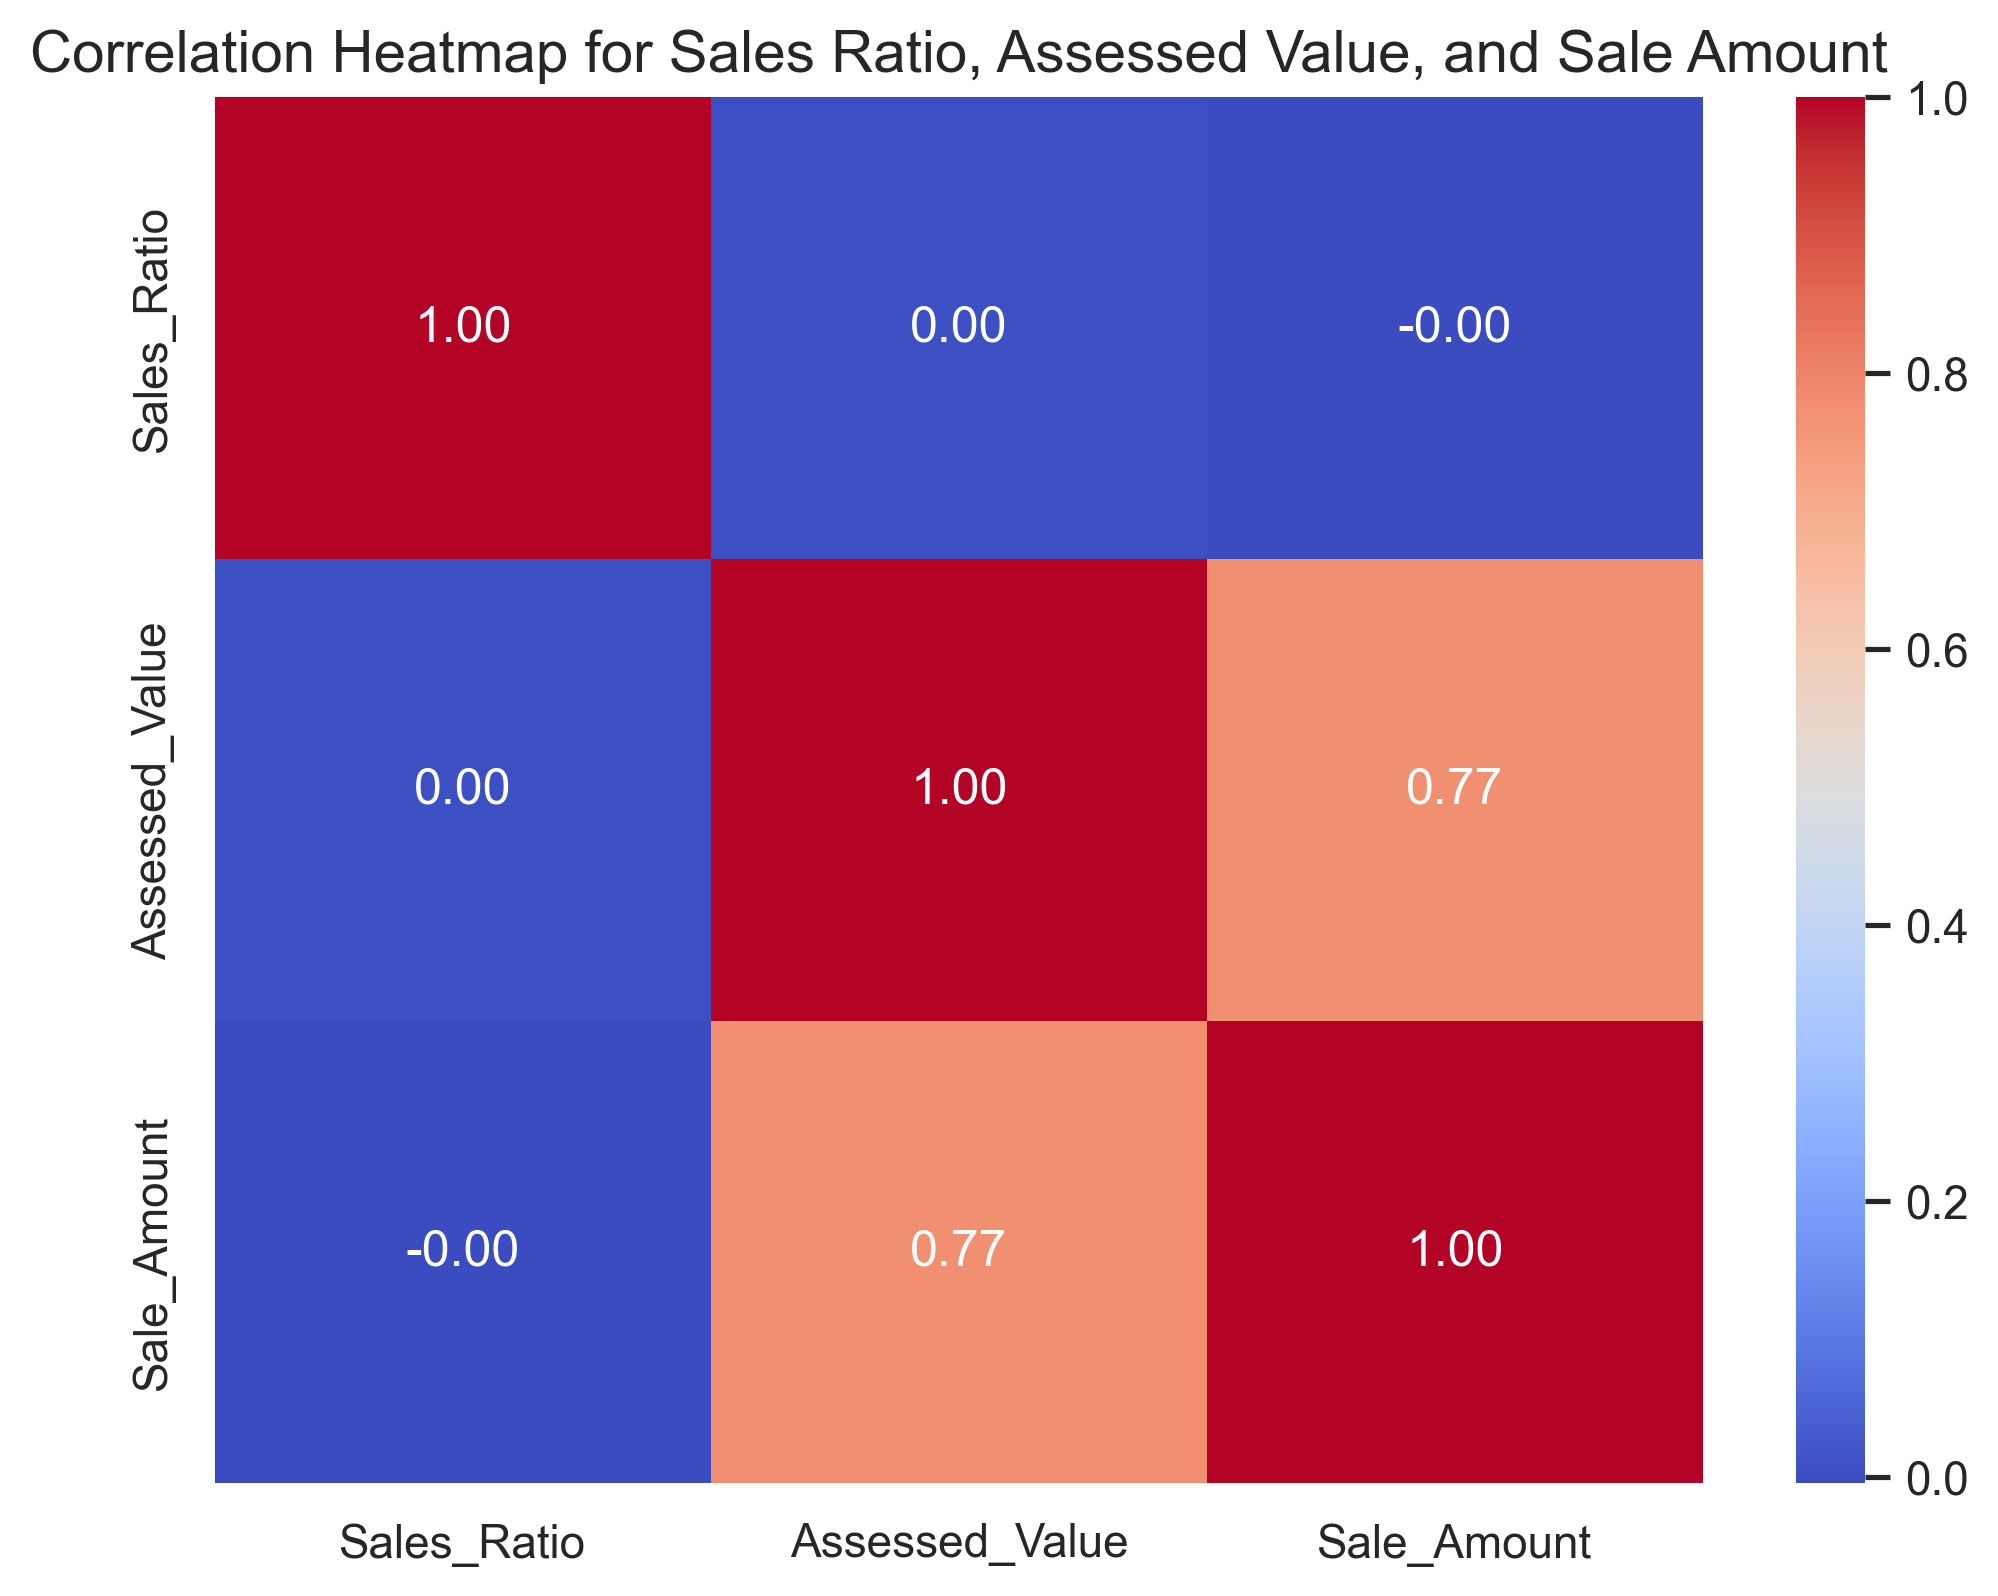

In [91]:
correlation_matrix = data[['Sales_Ratio', 'Assessed_Value', 'Sale_Amount']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)

plt.title('Correlation Heatmap for Sales Ratio, Assessed Value, and Sale Amount', fontsize=14)
plt.show()

**The above graph is a correlation matrix showing the Pearson correlation coefficients for all numeric columns. The group of variables with the highest correlation is between Sale Amount and Assessed Value, while there is no significant correlation found among other variable combinations.**

### Can we map the sales distribution using the Location column, if geospatial data is extracted?

In [92]:
import folium
from folium.plugins import MarkerCluster
from IPython.display import display

town_info = data.groupby('Town').agg(
    avg_sale_amount=('Sale_Amount', 'mean'),
    most_common_property_type=('Property_Type', lambda x: x.mode()[0]),
    most_common_residential_type=('Residential_Type', lambda x: x.mode()[0])
).reset_index()

map_center = [data['Latitude'].mean(), data['Longitude'].mean()]  # Set the map center
m = folium.Map(location=map_center, zoom_start=10)

marker_cluster = MarkerCluster().add_to(m)

for _, row in town_info.iterrows():
    town = row['Town']
    avg_sale_amount = row['avg_sale_amount']
    property_type = row['most_common_property_type']
    residential_type = row['most_common_residential_type']
    
    town_data = data[data['Town'] == town].iloc[0]
    latitude = town_data['Latitude']
    longitude = town_data['Longitude']
    
    popup_text = f"<strong>{town}</strong><br>"
    popup_text += f"Average Sale Amount: ${avg_sale_amount:,.2f}<br>"
    popup_text += f"Most Common Property Type: {property_type}<br>"
    popup_text += f"Most Common Residential Type: {residential_type}<br>"
    
    folium.Marker(
        location=[latitude, longitude],
        popup=popup_text,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(marker_cluster)

display(m)

**The above map was created using the Folium library. It displays the average sale amounts in towns, as well as the most popular property and residential types.**

### Are there seasonal patterns in sales, based on the Date Recorded column?

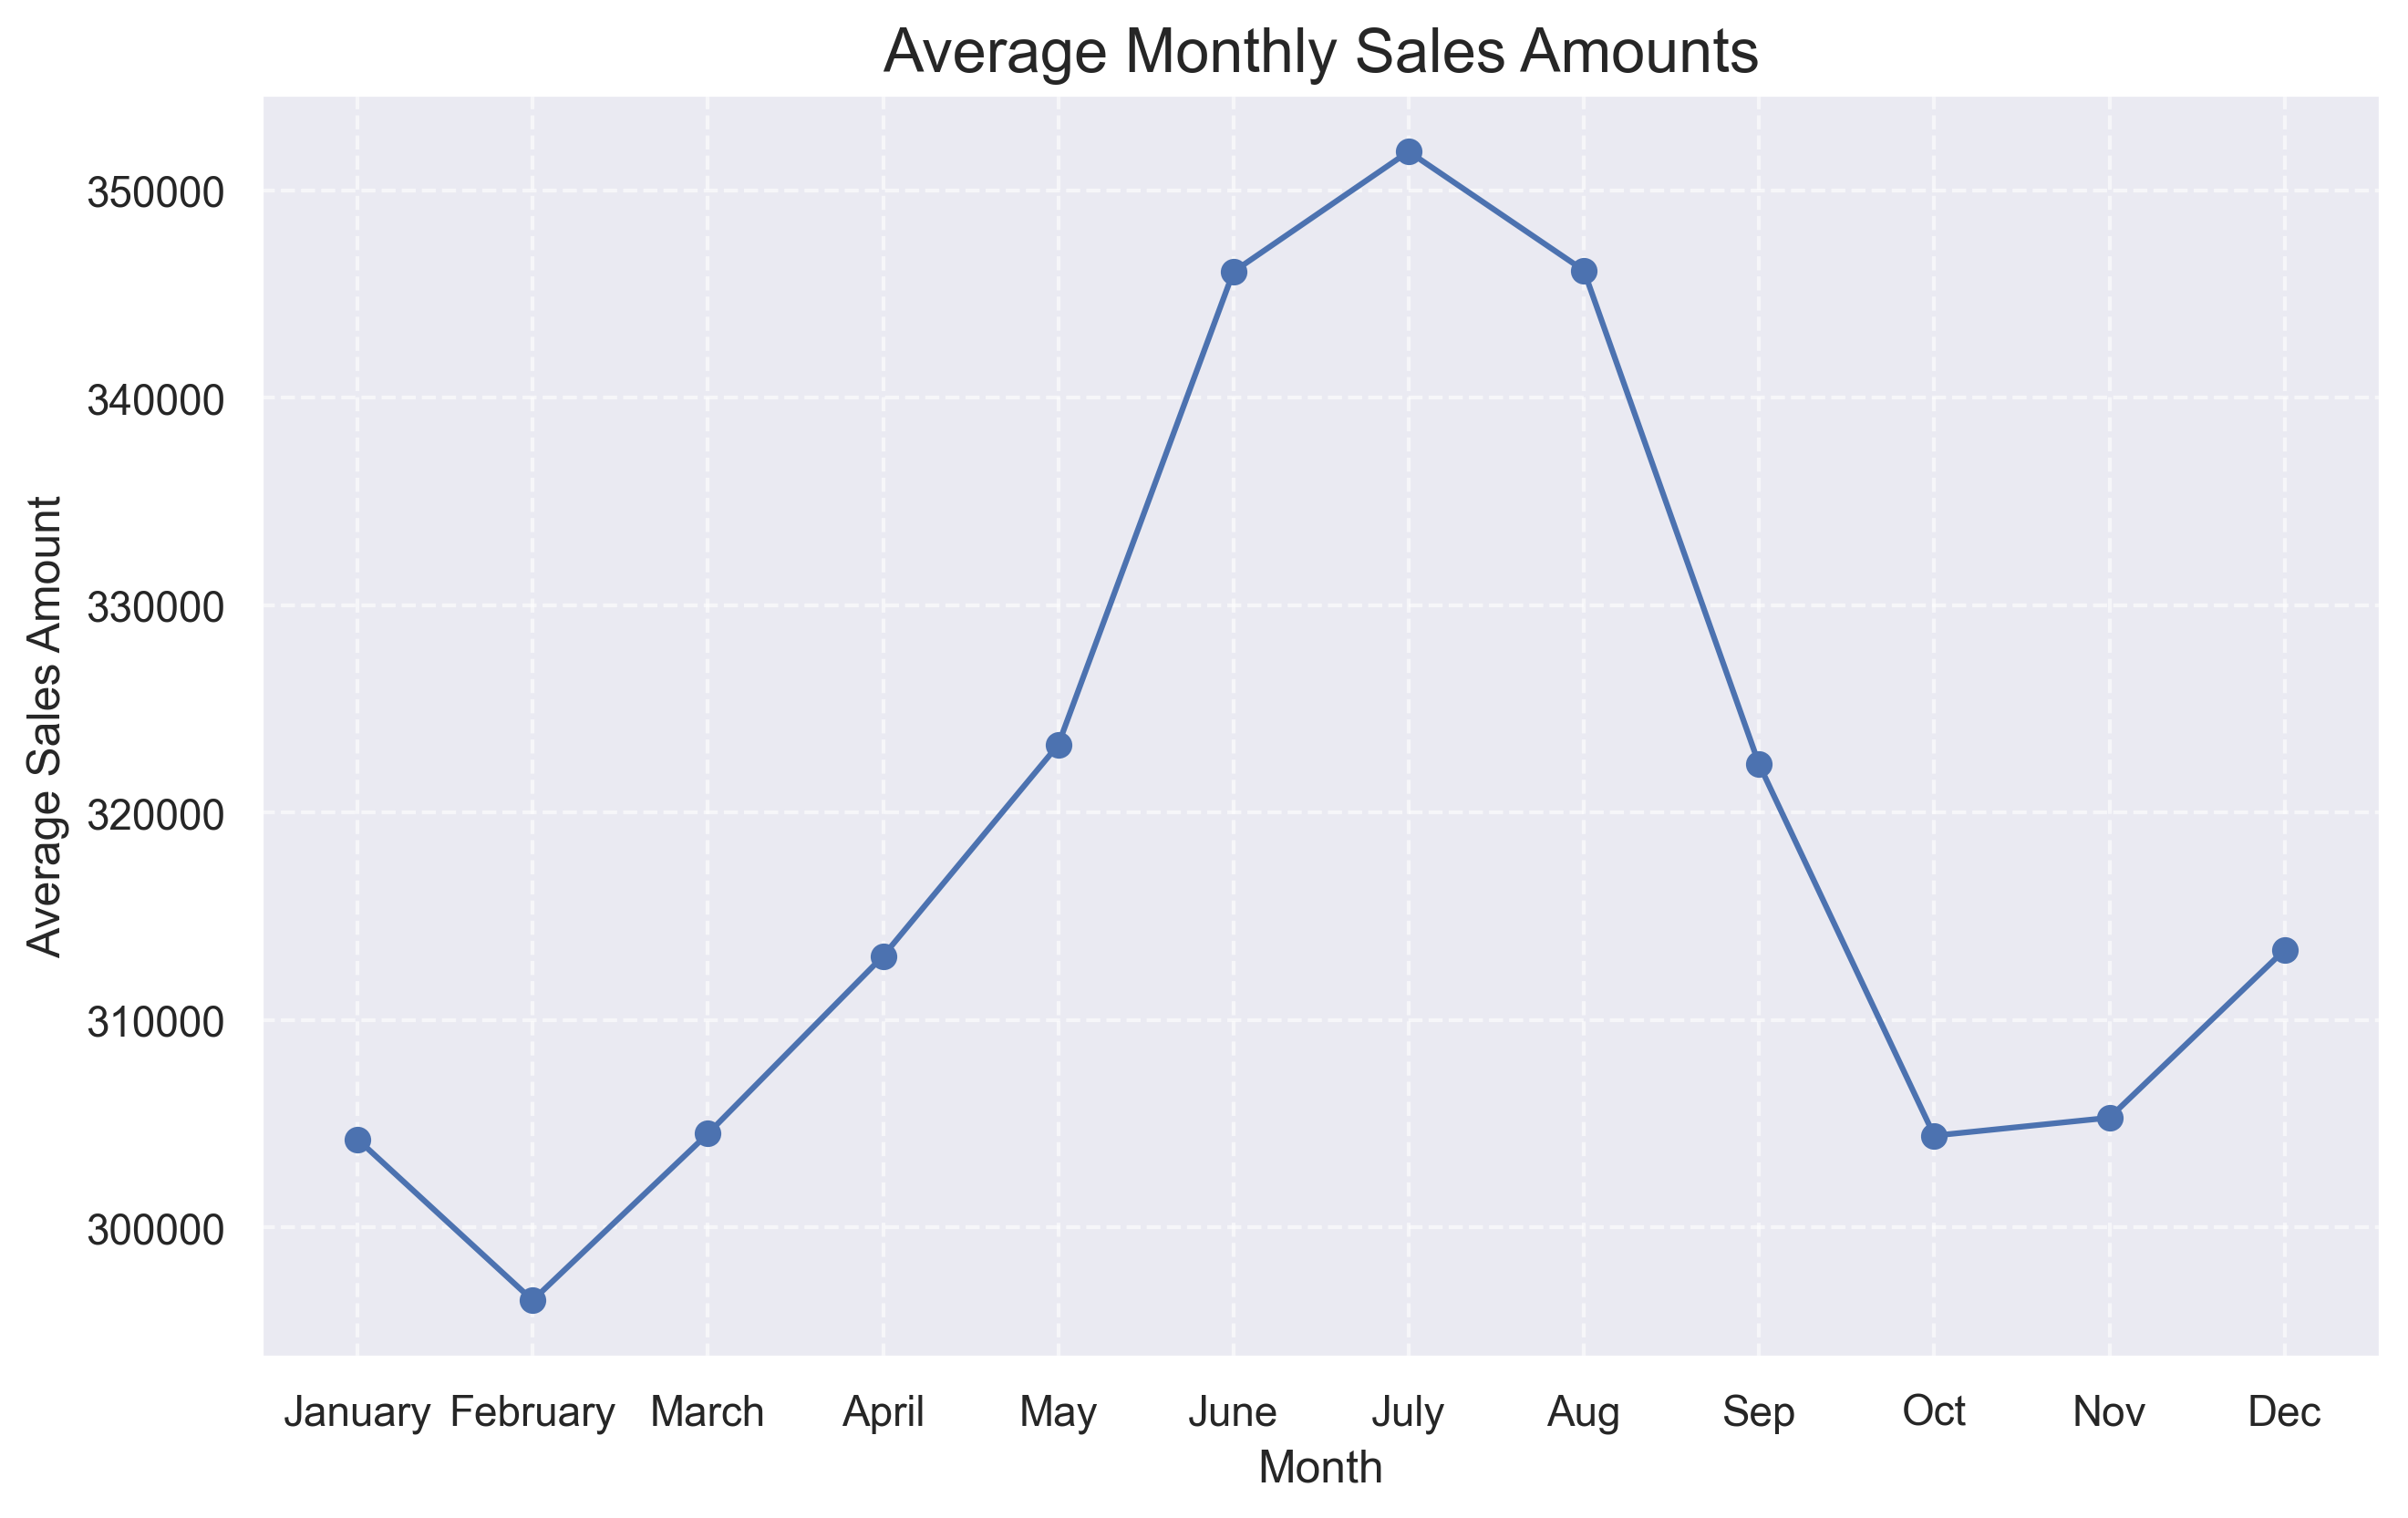

In [93]:
data['Month'] = data['Date_Recorded'].dt.month

monthly_sales = data.groupby('Month')['Sale_Amount'].mean() 

plt.figure(figsize=(10, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linestyle='-')
plt.title('Average Monthly Sales Amounts', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Sales Amount', fontsize=12)
plt.xticks(range(1, 13), ['January', 'February', 'March', 'April', 'May', 'June', 
                          'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**This graph shows the average sales by month.**

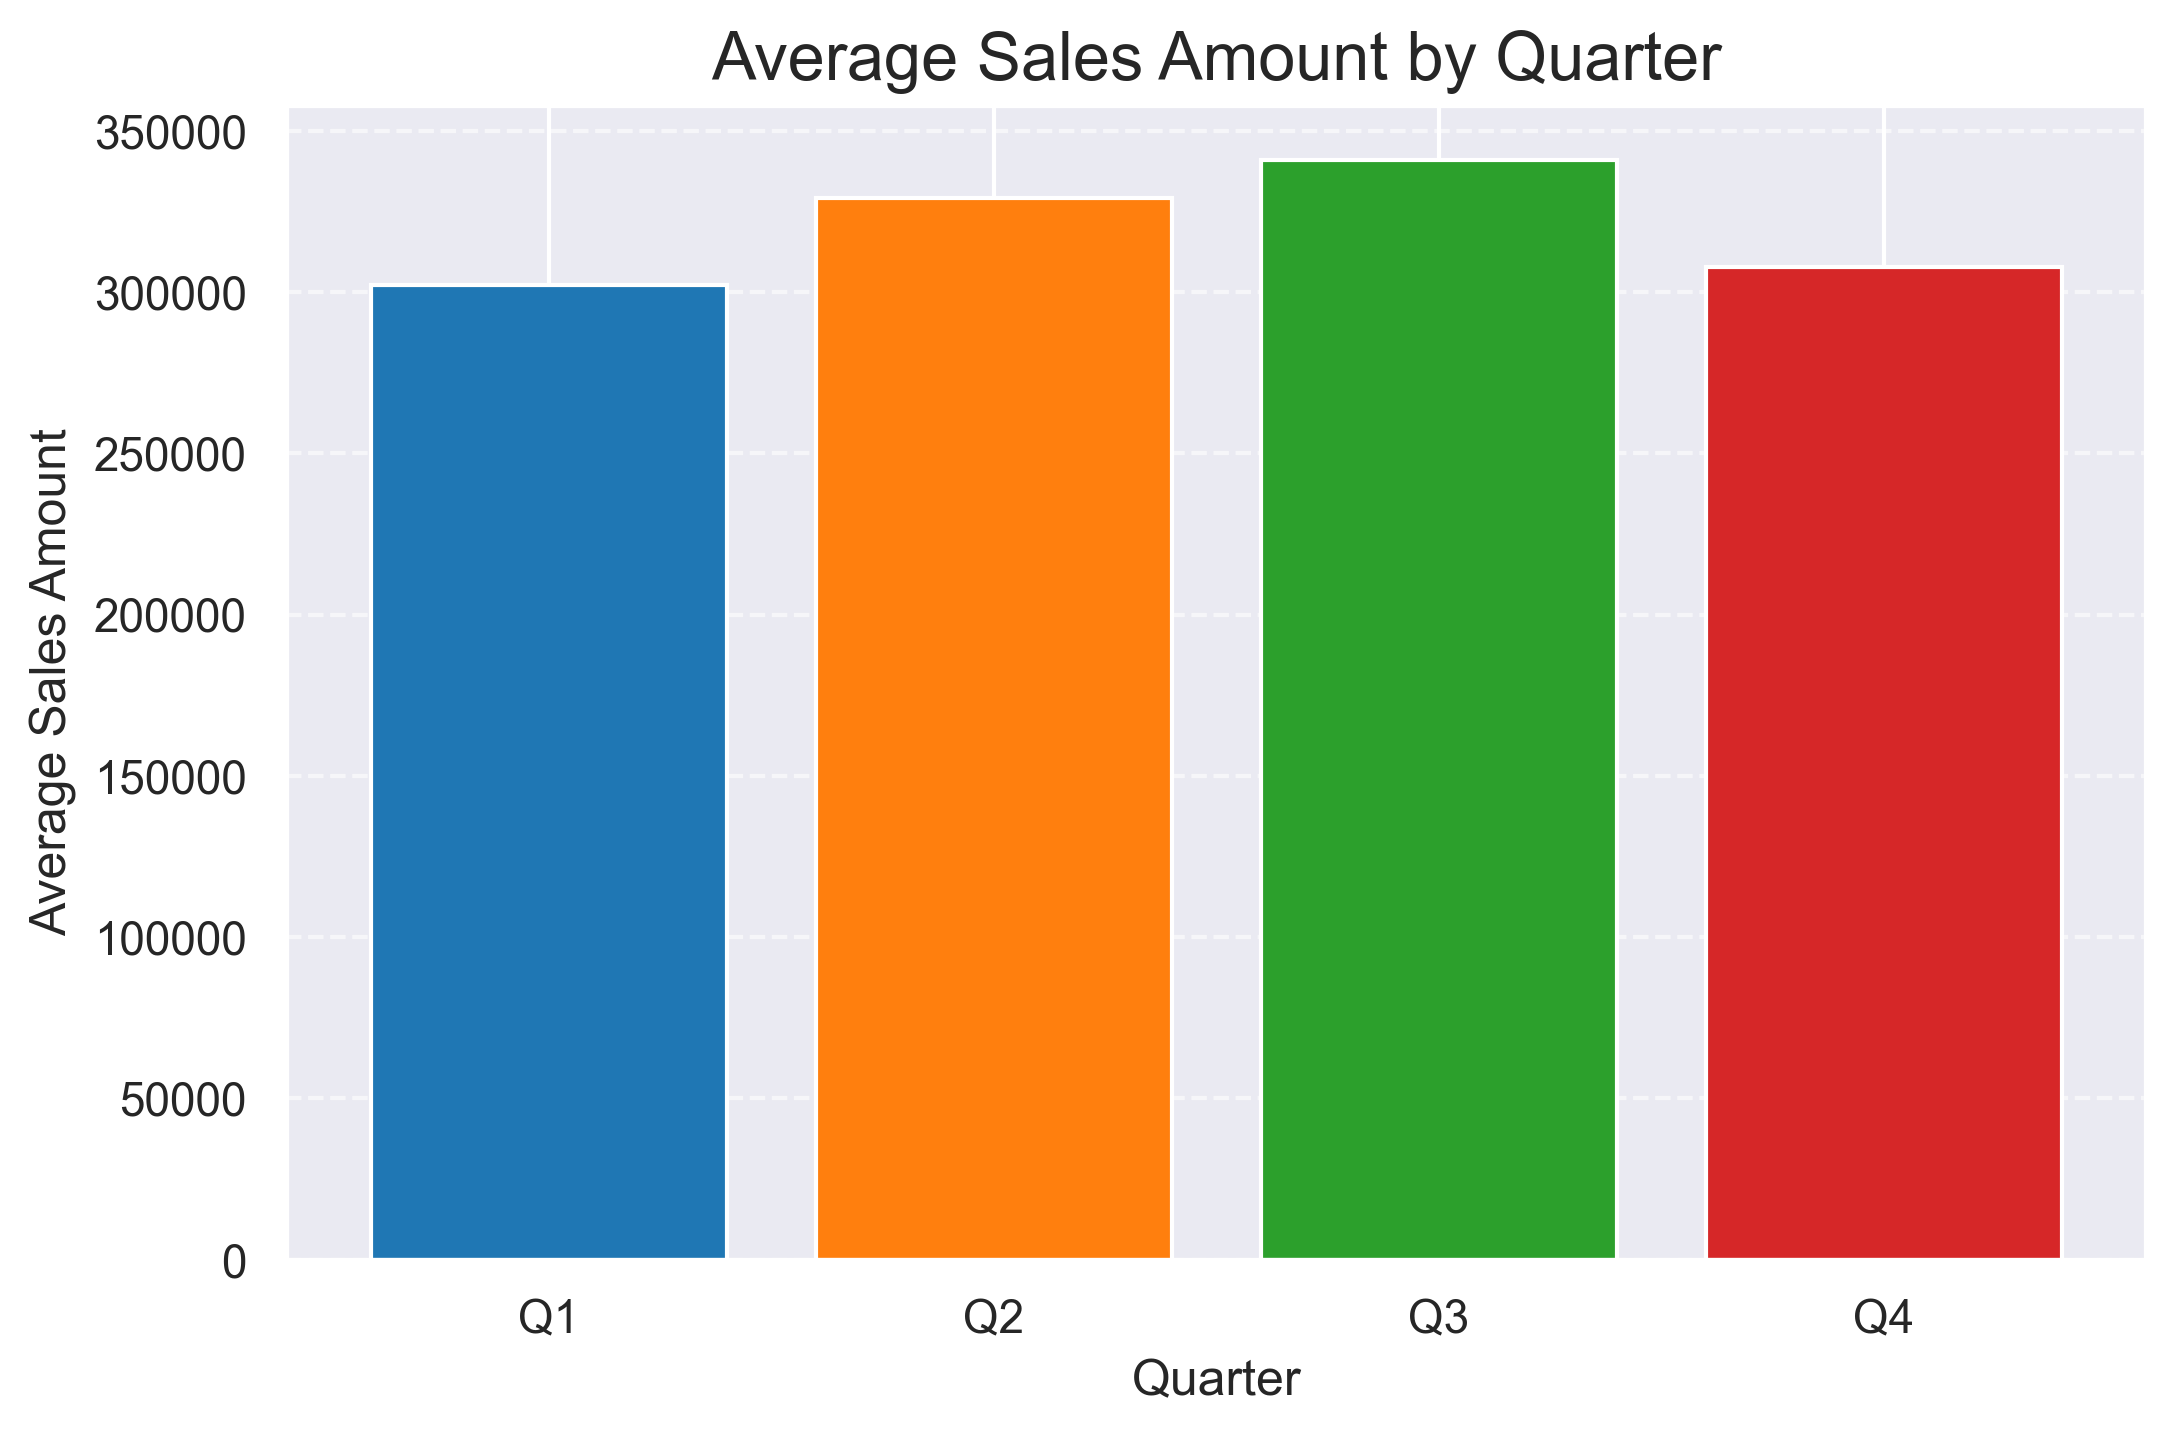

In [94]:
data['Quarter'] = data['Date_Recorded'].dt.quarter

quarterly_sales = data.groupby('Quarter')['Sale_Amount'].mean()  

plt.figure(figsize=(8, 5))
plt.bar(quarterly_sales.index, quarterly_sales.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Average Sales Amount by Quarter', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Average Sales Amount', fontsize=12)
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**This graph displays the average sales by dividing the years into quarterly periods. By looking at this graph, sales trends in each quarter can be analyzed.**

<a id='understanding-dataset'></a>
# <p style="background-color:black;font-family:newtimeroman;font-size:150%;color:white;text-align:center;border-radius:20px 20px;"><b>About Analysis by Dataset</b></p>

As a result of the data cleaning process, missing data and outliers were addressed. A significant portion of the missing values ​​were filled appropriately (with the suggested method) and the data set was made more consistent.
- 🎯 Data cleaning has been successfully performed, resulting in a more consistent and reliable dataset, ensuring that the information is accurate and ready for further analysis.
- 🎯 Data distributions and relationships between variables have been examined, and detailed visualizations and analyses were conducted, focusing on variables that show positive correlations.
- 🎯 By generating new data from the existing dataset, we have made the dataset more suitable for modeling.
- 🎯 This project has been a collaborative effort, with the team working in harmony, and through effective teamwork, valuable skills have been acquired that contributed to the overall success of the project.

## This dataset was used for educational purposes.

### - 📊 https://www.kaggle.com/zeripek
### - 💡 https://www.kaggle.com/ozanmhrc
### - 🧠 https://www.kaggle.com/abdullahkse
### - 🔍 https://www.kaggle.com/masidekabakci
### - 📝 https://www.kaggle.com/fatmayerlikayazkurt
### - 🌱 https://www.kaggle.com/hanifesin
### - 🎓 https://www.kaggle.com/teacherbabur
### - 💻 https://www.kaggle.com/semakurt
### - 🚀 https://www.kaggle.com/tubyco89